In [ ]:
# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import pytensor
pytensor.config.mode = 'FAST_COMPILE'

import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [ ]:
# ============================================================================
# CELL 2: CONSTANTS & HELPER FUNCTIONS
# ============================================================================

VALID_LEAGUES = ['Premier League', 'Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']

LEAGUE_MAP = {
    'Ligue 1':        0,
    'Bundesliga':     1,
    'Serie A':        2,
    'La Liga':        3,
    'Premier League': 4,
}

LEAGUE_MAP_REVERSE = {v: k for k, v in LEAGUE_MAP.items()}

COMMON_STATS_ATT_MID = ['KP', 'PrgP', 'PrgC', 'SCA']
COMMON_STATS_DEF     = ['TklW', 'Int', 'Clr', 'Blocks']

POSITION_FILTERS_ATT_MID = {
    'ATT': ['FWD'],
    'MID': ['MID'],
}

POSITION_FILTERS_DEF = {
    'DEF': ['DEF'],
}

# 2022/23→2023/24 & 2023/24→2024/25 is the held-out OOS test — never enters training
EXCLUDED_TRANSFER_SEASONS = {
    '2022_2023_to_2023_2024',
    '2023_2024_to_2024_2025',
}


def normalize_name(x: str) -> str:
    x = unicodedata.normalize('NFKD', str(x))
    x = x.encode('ascii', 'ignore').decode('ascii')
    return x.replace(' ', '').lower()


def bucket_position(pos: str) -> str:
    primary = str(pos).upper().split(',')[0].strip()
    if 'D' in primary:
        return 'DEF'
    elif 'M' in primary:
        return 'MID'
    elif 'F' in primary:
        return 'FWD'
    return 'OTHER'

In [ ]:
# ============================================================================
# CELL 3: DATA LOADING FUNCTIONS
# ============================================================================

def _standardize_league_and_position(df: pd.DataFrame) -> pd.DataFrame:
    df['Comp'] = (
        df['Comp']
        .astype(str)
        .str.replace(r'^[a-z]{2,3}\s+', '', regex=True)
        .str.strip()
    )
    df['Comp'] = df['Comp'].replace({'eng Premier League': 'Premier League'})
    df['Pos_Bucket'] = df['Pos'].apply(bucket_position)
    return df

def _load_base_historical(path: str) -> pd.DataFrame:
    """Load a historical season CSV (2017/18–2023/24).
    NOTE: 'Avg Mins per Match' is actually total season minutes (column name is
    misleading). 90s = total_minutes / 90. Do NOT multiply by Matches Played.
    """
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        'player': 'Player',
        'squad': 'Squad',
        'comp': 'Comp',
        'pos': 'Pos',
        'age': 'Age',
    })
    # FIX: 'Avg Mins per Match' is total season minutes, not average per game.
    # Previous code erroneously multiplied by 'Matches Played', inflating 90s ~20x.
    df['90s'] = pd.to_numeric(df['Avg Mins per Match'], errors='coerce').fillna(0) / 90.0
    return df

def _load_base_modern(path: str) -> pd.DataFrame:
    """Load a modern season CSV (2024/25+): title-case cols, '90s' already present."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    if '90s' not in df.columns and 'Min' in df.columns:
        df['90s'] = pd.to_numeric(df['Min'], errors='coerce').fillna(0) / 90.0
    return df

def load_season_att_mid(path: str, is_historical: bool = True, stats_list=None) -> pd.DataFrame:
    if is_historical:
        df = _load_base_historical(path)
        df['KP'] = pd.to_numeric(df['Key passes'], errors='coerce').fillna(0)
        df['PrgP'] = pd.to_numeric(df['Progressive Passes'], errors='coerce').fillna(0)
        df['PrgC'] = pd.to_numeric(df['Progressive Carries'], errors='coerce').fillna(0)
        df['SCA'] = (
            pd.to_numeric(df['Shot creating actions p 90'], errors='coerce').fillna(0)
            * df['90s']
        )
    else:
        df = _load_base_modern(path)
        if 'SCA' not in df.columns and 'SCA90' in df.columns:
            df['SCA'] = pd.to_numeric(df['SCA90'], errors='coerce').fillna(0) * df['90s']
        elif 'SCA' in df.columns:
            df['SCA'] = pd.to_numeric(df['SCA'], errors='coerce').fillna(0)
        else:
            df['SCA'] = 0.0
        for col in ['KP', 'PrgP', 'PrgC']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    if stats_list is None:
        stats_list = COMMON_STATS_ATT_MID
    for stat in stats_list:
        if stat not in df.columns:
            df[stat] = 0.0
        else:
            df[stat] = pd.to_numeric(df[stat], errors='coerce').fillna(0)
    df = _standardize_league_and_position(df)
    df = df[df['Comp'].isin(VALID_LEAGUES)]
    df = df[df['90s'] >= 3.0]
    df['Player_Key'] = df['Player'].apply(normalize_name)
    return df.reset_index(drop=True)

def load_season_def(path: str, is_historical: bool = True, stats_list=None) -> pd.DataFrame:
    if is_historical:
        df = _load_base_historical(path)
        df = df.rename(columns={
            'Tackles Won': 'TklW',
            'Interceptions': 'Int',
            'Clearances': 'Clr',
        })
        shots_blk  = pd.to_numeric(df['Shots blocked'], errors='coerce').fillna(0)
        passes_blk = pd.to_numeric(df['Passes blocked'], errors='coerce').fillna(0)
        df['Blocks'] = shots_blk + passes_blk
    else:
        df = _load_base_modern(path)
        for col in ['TklW', 'Int', 'Clr']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # FIX: 'Blocks' in the main table is shots blocked only.
        # 'Blocks_stats_defense' = Sh_stats_defense + Pass, which exactly
        # matches the historical definition of Shots blocked + Passes blocked.
        if 'Blocks_stats_defense' in df.columns:
            df['Blocks'] = pd.to_numeric(df['Blocks_stats_defense'], errors='coerce').fillna(0)
        elif 'Blocks' in df.columns:
            df['Blocks'] = pd.to_numeric(df['Blocks'], errors='coerce').fillna(0)
        else:
            df['Blocks'] = 0.0
    if stats_list is None:
        stats_list = COMMON_STATS_DEF
    for stat in stats_list:
        if stat not in df.columns:
            df[stat] = 0.0
        else:
            df[stat] = pd.to_numeric(df[stat], errors='coerce').fillna(0)
    df = _standardize_league_and_position(df)
    df = df[df['Pos_Bucket'] == 'DEF'].copy()
    df = df[df['Comp'].isin(VALID_LEAGUES)]
    df = df[df['90s'] >= 3.0]
    df['Player_Key'] = df['Player'].apply(normalize_name)
    return df.reset_index(drop=True)

In [ ]:
# ============================================================================
# CELL 4: BRIDGE CONSTRUCTION FUNCTION
# ============================================================================

def build_bridge(
    data_dict: dict,
    valid_positions: list,
    stats_list: list,
    train_seasons: list,
    label: str,
):
    """
    Build the training bridge DataFrame from consecutive season pairs.

    New features vs previous version:
      - League_origin  : original league name string (not just numeric ID)
      - Transfer_Season: season-pair label e.g. '2017_2018_to_2018_2019'
      - Excluded pairs : any pair touching EXCLUDED_TRANSFER_SEASONS is skipped
      - Assertion      : all League_ID values must match LEAGUE_MAP before returning
    """
    rows = []

    for i in range(len(train_seasons) - 1):
        s0, s1 = train_seasons[i], train_seasons[i + 1]
        transfer_season = f'{s0}_to_{s1}'

        # Hard temporal truncation — never let held-out season pairs leak in
        if transfer_season in EXCLUDED_TRANSFER_SEASONS:
            print(f"  Skipping excluded pair: {transfer_season}")
            continue

        if s0 not in data_dict or s1 not in data_dict:
            print(f"  WARNING: missing season data for pair {s0}/{s1}, skipping.")
            continue

        df_s0 = (
            data_dict[s0]
            .sort_values('90s', ascending=False)
            .drop_duplicates('Player_Key')
        )
        df_s1 = (
            data_dict[s1]
            .sort_values('90s', ascending=False)
            .drop_duplicates('Player_Key')
        )

        m = pd.merge(df_s0, df_s1, on='Player_Key', suffixes=('_src', '_trg'))

        valid = m[
            (m['Squad_src'] != m['Squad_trg']) &
            (m['Comp_trg'] == 'Premier League') &
            (m['90s_src'] >= 5.0) &
            (m['90s_trg'] >= 5.0) &
            (m['Pos_Bucket_src'].isin(valid_positions))
        ].copy()

        EPS = 0.05

        for _, r in valid.iterrows():
            src_league = r['Comp_src']
            league_id  = LEAGUE_MAP.get(src_league, -1)

            row = {
                'Player':          r['Player_src'],
                'League_ID':       league_id,
                'League_origin':   src_league,        # retain text label
                'Transfer_Season': transfer_season,   # season-pair tag
                'is_foreign':      int(src_league != 'Premier League'),
                'Age':             r['Age_src'],
                'Position':        r['Pos_Bucket_src'],
                'Team':            r['Squad_trg'],
                '90s_src':         r['90s_src'],
            }

            for s in stats_list:
                src_val = r.get(f'{s}_src', np.nan)
                trg_val = r.get(f'{s}_trg', np.nan)

                src_rate = src_val / r['90s_src']
                trg_rate = trg_val / r['90s_trg']

                row[f'{s}_src']       = src_rate
                row[f'{s}_trg']       = trg_rate
                row[f'{s}_log_ratio'] = np.log((trg_rate + EPS) / (src_rate + EPS))

            rows.append(row)

    df_bridge = pd.DataFrame(rows).dropna(subset=['Age'])

    if df_bridge.empty:
        print(f"ERROR: No valid transfers found for {label}")
        return None, None, None, None, None

    for s in stats_list:
        col = f'{s}_log_ratio'
        if col in df_bridge.columns:
            df_bridge[col] = df_bridge[col].replace([np.inf, -np.inf], np.nan)

    log_ratio_cols = [f'{s}_log_ratio' for s in stats_list]
    df_bridge = df_bridge.dropna(subset=log_ratio_cols)

    if df_bridge.empty:
        print(f"ERROR: No valid transfers with clean log-ratios for {label}")
        return None, None, None, None, None

    # ---- Assertion: every League_ID must be a valid LEAGUE_MAP value ----
    valid_ids    = set(LEAGUE_MAP.values())
    invalid_mask = ~df_bridge['League_ID'].isin(valid_ids)
    assert not invalid_mask.any(), (
        f"League_ID mapping mismatch in {label} bridge!\n"
        f"{df_bridge.loc[invalid_mask, ['Player', 'League_origin', 'League_ID']].head()}"
    )

    print(f"  Bridge ({label}): {len(df_bridge)} transfers after cleaning")
    print(f"  Transfer seasons: {sorted(df_bridge['Transfer_Season'].unique())}")

    age_mean = df_bridge['Age'].mean()
    df_bridge['Age_c'] = df_bridge['Age'] - age_mean

    df_bridge['team_id'],   team_labels   = pd.factorize(df_bridge['Team'])
    df_bridge['pos_id'],    pos_labels    = pd.factorize(df_bridge['Position'])
    df_bridge['player_id'], player_labels = pd.factorize(df_bridge['Player'])

    return df_bridge, age_mean, team_labels, pos_labels, log_ratio_cols

In [ ]:
# ============================================================================
# CELL 5: MODEL FITTING FUNCTION
# ============================================================================

def fit_joint_model(
    df_bridge: pd.DataFrame,
    stats_list: list,
    n_pos: int,
    n_teams: int,
):
    """
    Fit the joint multivariate hierarchical model.

    Prior change: league group variance now uses HalfStudentT(nu=4, sigma=0.5)
    instead of HalfNormal(0.5) to allow heavier tails and prevent over-shrinkage
    of defensive league effects toward zero.
    """
    n_stats = len(stats_list)

    standardization = {}
    Y_raw = np.zeros((len(df_bridge), n_stats))

    for j, s in enumerate(stats_list):
        col  = f'{s}_log_ratio'
        vals = df_bridge[col].values
        mean = vals.mean()
        std  = vals.std()
        if std < 1e-6:
            raise ValueError(
                f"Stat '{s}' has near-zero variance ({std:.2e}). "
                "Check data or remove this stat."
            )
        standardization[s] = {'mean': float(mean), 'std': float(std)}
        Y_raw[:, j] = (vals - mean) / std

    Y = Y_raw

    league_id   = df_bridge['League_ID'].values.astype(int)
    is_foreign  = df_bridge['is_foreign'].values.astype(int)
    pos_id      = df_bridge['pos_id'].values.astype(int)
    team_id     = df_bridge['team_id'].values.astype(int)
    age_c       = (df_bridge['Age_c'].values / 5.0).astype(float)
    minutes_src = df_bridge['90s_src'].values

    w        = np.sqrt(minutes_src / (minutes_src + 5.0))
    Y_scaled = Y * w[:, None]

    with pm.Model() as joint_model:
        alpha = pm.Normal('alpha', 0, 0.2, shape=n_stats)

        mu_lt    = pm.Normal('mu_lt', 0, 0.2, shape=n_stats)
        # HalfStudentT: heavier tails than HalfNormal, prevents over-shrinkage
        sigma_lt = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats)
        z_league = pm.Normal('z_league', 0, 1, shape=(4, n_stats))
        league_tax = pm.Deterministic(
            'league_tax',
            mu_lt[None, :] + z_league * sigma_lt[None, :]
        )

        if n_pos > 1:
            sigma_pos = pm.HalfNormal('sigma_pos', 0.2)
            z_pos     = pm.Normal('z_pos', 0, 1, shape=(n_pos, n_stats))
            pos_eff   = pm.Deterministic('pos_eff', z_pos * sigma_pos)
        else:
            pos_eff = 0

        sigma_team = pm.HalfNormal('sigma_team', 0.2)
        z_team     = pm.Normal('z_team', 0, 1, shape=(n_teams, n_stats))
        team_eff   = pm.Deterministic('team_eff', z_team * sigma_team)

        beta_age  = pm.Normal('beta_age',  0, 0.05, shape=n_stats)
        beta_age2 = pm.Normal('beta_age2', 0, 0.02, shape=n_stats)

        safe_league_idx  = pm.intX(np.clip(league_id, 0, 3))
        pos_contribution = pos_eff[pos_id] if n_pos > 1 else 0

        mu = (
            alpha
            + is_foreign[:, None] * league_tax[safe_league_idx]
            + pos_contribution
            + team_eff[team_id]
            + beta_age  * age_c[:, None]
            + beta_age2 * (age_c[:, None] ** 2)
        )

        sd_dist = pm.HalfNormal.dist(0.3)
        chol, corr, sigma = pm.LKJCholeskyCov(
            'chol',
            n=n_stats,
            eta=3.0,
            sd_dist=sd_dist,
            compute_corr=True,
        )

        mu_scaled = mu * w[:, None]

        pm.MvStudentT(
            'obs',
            nu=6,
            mu=mu_scaled,
            chol=chol,
            observed=Y_scaled,
        )

        joint_trace = pm.sample(
            draws=1500,
            tune=1500,
            target_accept=0.95,
            random_seed=42,
            init='adapt_diag',
            nuts_sampler='numpyro',
        )

    return joint_model, joint_trace, standardization, Y, w

In [ ]:
# ============================================================================
# CELL 6: CONVERGENCE DIAGNOSTICS FUNCTIONS
# ============================================================================

def print_convergence_diagnostics(trace, label: str):
    print(f"\n{label} - Convergence Diagnostics")
    print("-" * 60)

    divergences = int(trace.sample_stats['diverging'].sum())
    print(f"  Divergences: {divergences} (OK if < 10)")
    if divergences > 10:
        print("  ⚠ WARNING: High divergence count")
    else:
        print("  ✓ Divergences acceptable")

    try:
        rhat = az.rhat(trace, var_names=['alpha', 'league_tax', 'beta_age'])
        rhat_values = []
        for var_name in ['alpha', 'league_tax', 'beta_age']:
            if var_name in rhat:
                vals = rhat[var_name].values.flatten()
                rhat_values.extend(v for v in vals if np.isfinite(v))
        if rhat_values:
            rhat_max = float(np.max(rhat_values))
            print(f"  Max Rhat: {rhat_max:.4f}")
            if rhat_max > 1.05:
                print("  ⚠ WARNING: Some parameters have Rhat > 1.05")
            else:
                print("  ✓ All Rhat values acceptable")
    except Exception as e:
        print(f"  Rhat computation failed: {e}")

    print("-" * 60)


def plot_convergence_diagnostics(trace, label: str):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{label} - Convergence Diagnostics', fontsize=14, fontweight='bold')

    divergences = int(trace.sample_stats['diverging'].sum())
    ax = axes[0, 0]
    ax.bar(['Divergences'], [divergences],
           color='coral' if divergences > 10 else 'green', alpha=0.7)
    ax.axhline(y=10, color='red', linestyle='--', label='Warning threshold')
    ax.set_ylabel('Count')
    ax.set_title('Sampling Divergences')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

    ax = axes[0, 1]
    ess = az.ess(trace, var_names=['alpha']).to_array().values.flatten()
    ax.hist(ess, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('ESS')
    ax.set_ylabel('Frequency')
    ax.set_title('Effective Sample Size Distribution')
    ax.grid(alpha=0.3, axis='y')

    ax = axes[1, 0]
    try:
        rhat = az.rhat(trace, var_names=['alpha', 'league_tax', 'beta_age'])
        rhat_vals = []
        for var_name in ['alpha', 'league_tax', 'beta_age']:
            if var_name in rhat:
                vals = rhat[var_name].values.flatten()
                rhat_vals.extend(v for v in vals if np.isfinite(v))
        ax.hist(rhat_vals, bins=20, color='green', alpha=0.7, edgecolor='black')
        ax.axvline(x=1.05, color='red', linestyle='--', linewidth=2, label='Threshold (1.05)')
        ax.set_xlabel('Rhat')
        ax.set_ylabel('Frequency')
        ax.set_title('Rhat Distribution')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')
    except Exception:
        ax.text(0.5, 0.5, 'Rhat computation unavailable', ha='center', va='center')

    ax = axes[1, 1]
    alpha_traces = trace.posterior['alpha'].values
    for i in range(min(4, alpha_traces.shape[-1])):
        ax.plot(alpha_traces[:, :, i].flatten(), alpha=0.7, linewidth=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Alpha values')
    ax.set_title('Trace Plots (alpha parameters)')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig

In [ ]:
# ============================================================================
# CELL 7: LOAD ATT+MID SEASON DATA
# ============================================================================
# Train seasons: 2017/18–2021/22 → 5 bridge pairs
#   (2022/23→2023/24 and 2023/24→2024/25 are both held out as test cohorts)

train_seasons = [
    '2017_2018', '2018_2019', '2019_2020',
    '2020_2021', '2021_2022', '2022_2023', '2023_2024',
]

print("Loading season data for ATT+MID...")
data_att_mid = {}
for s in train_seasons:
    data_att_mid[s] = load_season_att_mid(
        f'players_data-{s}.csv',
        is_historical=True,
        stats_list=COMMON_STATS_ATT_MID,
    )

# Load held-out target season — modern format, never used in training bridge
df_2425_att_mid = load_season_att_mid(
    'players_data-2024_2025.csv',
    is_historical=False,
    stats_list=COMMON_STATS_ATT_MID,
)

Loading season data for ATT+MID...


In [ ]:
# ============================================================================
# CELL 8: BUILD & FIT ATT+MID MODEL
# ============================================================================

print("\n" + "=" * 80)
print("BUILDING COMBINED ATT+MID BRIDGE")
print("=" * 80 + "\n")

valid_positions_att_mid = list(
    set(POSITION_FILTERS_ATT_MID['ATT'] + POSITION_FILTERS_ATT_MID['MID'])
)
print(f"Valid positions (ATT+MID): {valid_positions_att_mid}")

(
    df_bridge_att_mid,
    age_mean_att_mid,
    team_labels_att_mid,
    pos_labels_att_mid,
    log_ratio_cols_att_mid,
) = build_bridge(
    data_att_mid,
    valid_positions_att_mid,
    COMMON_STATS_ATT_MID,
    train_seasons,
    label='ATT+MID',
)

if df_bridge_att_mid is not None:
    n_teams_att_mid = len(team_labels_att_mid)
    n_pos_att_mid   = len(pos_labels_att_mid)
    n_stats_att_mid = len(COMMON_STATS_ATT_MID)

    print(
        f"  {len(df_bridge_att_mid)} transfers, "
        f"{n_teams_att_mid} teams, {n_pos_att_mid} position(s)"
    )
    print(f"  Stats: {COMMON_STATS_ATT_MID}\n")

    print("=" * 80)
    print("FITTING JOINT MULTIVARIATE MODEL (ATT+MID)")
    print("=" * 80 + "\n")

    (
        joint_model_att_mid,
        joint_trace_att_mid,
        standardization_att_mid,
        Y_std_att_mid,
        w_att_mid,
    ) = fit_joint_model(
        df_bridge_att_mid,
        COMMON_STATS_ATT_MID,
        n_pos_att_mid,
        n_teams_att_mid,
    )
    print("✓ Model fitted (ATT+MID)\n")
    print_convergence_diagnostics(joint_trace_att_mid, "ATT+MID")

else:
    print("ERROR: Could not build bridge for ATT+MID")

# Save ATT+MID model artifacts
import pickle
import os

save_dir = '/content/model_artifacts'
os.makedirs(save_dir, exist_ok=True)

joint_trace_att_mid.to_netcdf(f'{save_dir}/trace_att_mid.nc')

with open(f'{save_dir}/artifacts_att_mid.pkl', 'wb') as f:
    pickle.dump({
        'standardization': standardization_att_mid,
        'age_mean':        age_mean_att_mid,
        'team_labels':     team_labels_att_mid,
        'pos_labels':      pos_labels_att_mid,
        'n_teams':         n_teams_att_mid,
        'n_pos':           n_pos_att_mid,
    }, f)

print("✓ ATT+MID artifacts saved to", save_dir)


BUILDING COMBINED ATT+MID BRIDGE

Valid positions (ATT+MID): ['MID', 'FWD']
  Skipping excluded pair: 2022_2023_to_2023_2024
  Bridge (ATT+MID): 174 transfers after cleaning
  Transfer seasons: ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']
  174 transfers, 26 teams, 2 position(s)
  Stats: ['KP', 'PrgP', 'PrgC', 'SCA']

FITTING JOINT MULTIVARIATE MODEL (ATT+MID)



sample: 100%|██████████| 3000/3000 [02:52<00:00, 17.35it/s, 31 steps of size 1.00e-01. acc. prob=0.93]


✓ Model fitted (ATT+MID)


ATT+MID - Convergence Diagnostics
------------------------------------------------------------
  Divergences: 0 (OK if < 10)
  ✓ Divergences acceptable
  Max Rhat: 1.0023
  ✓ All Rhat values acceptable
------------------------------------------------------------
✓ ATT+MID artifacts saved to /content/model_artifacts


In [ ]:
# ============================================================================
# CELL 8b: SENSITIVITY ANALYSIS — DEGREES OF FREEDOM (nu) — ATT+MID
# ============================================================================

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS: Degrees of Freedom (nu) — ATT+MID")
print("=" * 80 + "\n")

if df_bridge_att_mid is not None:
    nu_values        = [4, 6, 8, 10]
    nu_results_att   = {}

    league_id_vals   = df_bridge_att_mid['League_ID'].values.astype(int)
    is_foreign_vals  = df_bridge_att_mid['is_foreign'].values.astype(int)
    pos_id_vals      = df_bridge_att_mid['pos_id'].values.astype(int)
    team_id_vals     = df_bridge_att_mid['team_id'].values.astype(int)
    age_c_vals       = (df_bridge_att_mid['Age_c'].values / 5.0).astype(float)
    minutes_src_vals = df_bridge_att_mid['90s_src'].values
    w_vals_main      = np.sqrt(minutes_src_vals / (minutes_src_vals + 5.0))
    Y_scaled_att     = Y_std_att_mid * w_vals_main[:, None]

    for nu_val in nu_values:
        print(f"Fitting ATT+MID model with nu={nu_val}...")
        with pm.Model() as nu_model:
            alpha_s    = pm.Normal('alpha', 0, 0.2, shape=n_stats_att_mid)
            mu_lt_s    = pm.Normal('mu_lt', 0, 0.2, shape=n_stats_att_mid)
            sigma_lt_s = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats_att_mid)
            z_league_s = pm.Normal('z_league', 0, 1, shape=(4, n_stats_att_mid))
            league_tax_s = pm.Deterministic(
                'league_tax', mu_lt_s[None, :] + z_league_s * sigma_lt_s[None, :]
            )
            sigma_pos_s  = pm.HalfNormal('sigma_pos', 0.2)
            z_pos_s      = pm.Normal('z_pos', 0, 1, shape=(n_pos_att_mid, n_stats_att_mid))
            pos_eff_s    = pm.Deterministic('pos_eff', z_pos_s * sigma_pos_s)
            sigma_team_s = pm.HalfNormal('sigma_team', 0.2)
            z_team_s     = pm.Normal('z_team', 0, 1, shape=(n_teams_att_mid, n_stats_att_mid))
            team_eff_s   = pm.Deterministic('team_eff', z_team_s * sigma_team_s)
            beta_age_s   = pm.Normal('beta_age',  0, 0.05, shape=n_stats_att_mid)
            beta_age2_s  = pm.Normal('beta_age2', 0, 0.02, shape=n_stats_att_mid)
            safe_lid_s   = pm.intX(np.clip(league_id_vals, 0, 3))
            mu_s = (
                alpha_s
                + is_foreign_vals[:, None] * league_tax_s[safe_lid_s]
                + pos_eff_s[pos_id_vals]
                + team_eff_s[team_id_vals]
                + beta_age_s  * age_c_vals[:, None]
                + beta_age2_s * (age_c_vals[:, None] ** 2)
            )
            sd_dist_s = pm.HalfNormal.dist(0.3)
            chol_s, _, _ = pm.LKJCholeskyCov(
                'chol', n=n_stats_att_mid, eta=3.0,
                sd_dist=sd_dist_s, compute_corr=True,
            )
            pm.MvStudentT(
                'obs', nu=nu_val,
                mu=mu_s * w_vals_main[:, None],
                chol=chol_s,
                observed=Y_scaled_att,
            )
            nu_trace = pm.sample(
                draws=1000, tune=1000, target_accept=0.95,
                random_seed=42, init='adapt_diag',
                nuts_sampler='numpyro', progressbar=True,
            )

        lt_mean     = nu_trace.posterior['league_tax'].mean(dim=('chain', 'draw')).values
        divergences = int(nu_trace.sample_stats['diverging'].sum())
        nu_results_att[nu_val] = {'league_tax_mean': lt_mean, 'divergences': divergences}
        print(f"  nu={nu_val}: divergences={divergences}")

    # index 0 = KP (first stat after removing npxG)
    print("\nLeague tax sensitivity (ATT+MID, KP — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):")
    print(f"{'nu':>5} | {'Ligue1':>8} {'Bundesliga':>10} {'Serie A':>8} {'La Liga':>8}")
    print("-" * 50)
    for nu_val in nu_values:
        lt = nu_results_att[nu_val]['league_tax_mean'][:, 0]
        print(f"{nu_val:>5} | {lt[0]:>8.4f} {lt[1]:>10.4f} {lt[2]:>8.4f} {lt[3]:>8.4f}")
else:
    print("SKIPPED: ATT+MID bridge not available.")


SENSITIVITY ANALYSIS: Degrees of Freedom (nu) — ATT+MID

Fitting ATT+MID model with nu=4...


sample: 100%|██████████| 2000/2000 [02:19<00:00, 14.33it/s, 63 steps of size 6.99e-02. acc. prob=0.96]


  nu=4: divergences=0
Fitting ATT+MID model with nu=6...


sample: 100%|██████████| 2000/2000 [02:19<00:00, 14.33it/s, 63 steps of size 8.40e-02. acc. prob=0.95]


  nu=6: divergences=0
Fitting ATT+MID model with nu=8...


sample: 100%|██████████| 2000/2000 [02:17<00:00, 14.51it/s, 63 steps of size 7.34e-02. acc. prob=0.97]


  nu=8: divergences=0
Fitting ATT+MID model with nu=10...


sample: 100%|██████████| 2000/2000 [02:18<00:00, 14.49it/s, 63 steps of size 8.52e-02. acc. prob=0.96]


  nu=10: divergences=0

League tax sensitivity (ATT+MID, KP — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):
   nu |   Ligue1 Bundesliga  Serie A  La Liga
--------------------------------------------------
    4 |  -0.0141    -0.1848  -0.2011   0.1587
    6 |  -0.0240    -0.1833  -0.2026   0.1409
    8 |  -0.0304    -0.1792  -0.1993   0.1255
   10 |  -0.0325    -0.1723  -0.1966   0.1098


In [ ]:
# ============================================================================
# CELL 8c: SENSITIVITY ANALYSIS — WEIGHTING SCHEME — ATT+MID
# ============================================================================

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS: Weighting Scheme — ATT+MID")
print("=" * 80 + "\n")

if df_bridge_att_mid is not None:
    weight_constants   = [3, 5, 10]
    weight_results_att = {}

    for wc in weight_constants:
        print(f"Fitting ATT+MID model with weighting constant={wc}...")
        w_wc        = np.sqrt(minutes_src_vals / (minutes_src_vals + wc))
        Y_scaled_wc = Y_std_att_mid * w_wc[:, None]

        with pm.Model() as w_model_att:
            alpha_w    = pm.Normal('alpha', 0, 0.2, shape=n_stats_att_mid)
            mu_lt_w    = pm.Normal('mu_lt', 0, 0.2, shape=n_stats_att_mid)
            sigma_lt_w = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats_att_mid)
            z_league_w = pm.Normal('z_league', 0, 1, shape=(4, n_stats_att_mid))
            league_tax_w = pm.Deterministic(
                'league_tax', mu_lt_w[None, :] + z_league_w * sigma_lt_w[None, :]
            )
            sigma_pos_w  = pm.HalfNormal('sigma_pos', 0.2)
            z_pos_w      = pm.Normal('z_pos', 0, 1, shape=(n_pos_att_mid, n_stats_att_mid))
            pos_eff_w    = pm.Deterministic('pos_eff', z_pos_w * sigma_pos_w)
            sigma_team_w = pm.HalfNormal('sigma_team', 0.2)
            z_team_w     = pm.Normal('z_team', 0, 1, shape=(n_teams_att_mid, n_stats_att_mid))
            team_eff_w   = pm.Deterministic('team_eff', z_team_w * sigma_team_w)
            beta_age_w   = pm.Normal('beta_age',  0, 0.05, shape=n_stats_att_mid)
            beta_age2_w  = pm.Normal('beta_age2', 0, 0.02, shape=n_stats_att_mid)
            safe_lid_w   = pm.intX(np.clip(league_id_vals, 0, 3))
            mu_w = (
                alpha_w
                + is_foreign_vals[:, None] * league_tax_w[safe_lid_w]
                + pos_eff_w[pos_id_vals]
                + team_eff_w[team_id_vals]
                + beta_age_w  * age_c_vals[:, None]
                + beta_age2_w * (age_c_vals[:, None] ** 2)
            )
            sd_dist_w = pm.HalfNormal.dist(0.3)
            chol_w, _, _ = pm.LKJCholeskyCov(
                'chol', n=n_stats_att_mid, eta=3.0,
                sd_dist=sd_dist_w, compute_corr=True,
            )
            pm.MvStudentT(
                'obs', nu=6,
                mu=mu_w * w_wc[:, None],
                chol=chol_w,
                observed=Y_scaled_wc,
            )
            w_trace_att = pm.sample(
                draws=1000, tune=1000, target_accept=0.95,
                random_seed=42, init='adapt_diag',
                nuts_sampler='numpyro', progressbar=True,
            )

        lt_mean     = w_trace_att.posterior['league_tax'].mean(dim=('chain', 'draw')).values
        divergences = int(w_trace_att.sample_stats['diverging'].sum())
        weight_results_att[wc] = {'league_tax_mean': lt_mean, 'divergences': divergences}
        print(f"  wc={wc}: divergences={divergences}")

    print("\nWeighting sensitivity (ATT+MID, KP — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):")
    print(f"{'wc':>5} | {'Ligue1':>8} {'Bundesliga':>10} {'Serie A':>8} {'La Liga':>8}")
    print("-" * 50)
    for wc in weight_constants:
        lt = weight_results_att[wc]['league_tax_mean'][:, 0]
        print(f"{wc:>5} | {lt[0]:>8.4f} {lt[1]:>10.4f} {lt[2]:>8.4f} {lt[3]:>8.4f}")
else:
    print("SKIPPED: ATT+MID bridge not available.")


SENSITIVITY ANALYSIS: Weighting Scheme — ATT+MID

Fitting ATT+MID model with weighting constant=3...


sample: 100%|██████████| 2000/2000 [02:14<00:00, 14.86it/s, 63 steps of size 9.27e-02. acc. prob=0.95]


  wc=3: divergences=0
Fitting ATT+MID model with weighting constant=5...


sample: 100%|██████████| 2000/2000 [02:23<00:00, 13.91it/s, 63 steps of size 7.46e-02. acc. prob=0.97]


  wc=5: divergences=0
Fitting ATT+MID model with weighting constant=10...


sample: 100%|██████████| 2000/2000 [02:21<00:00, 14.09it/s, 63 steps of size 7.61e-02. acc. prob=0.96]


  wc=10: divergences=0

Weighting sensitivity (ATT+MID, KP — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):
   wc |   Ligue1 Bundesliga  Serie A  La Liga
--------------------------------------------------
    3 |  -0.0201    -0.1849  -0.2021   0.1470
    5 |  -0.0239    -0.1793  -0.1970   0.1362
   10 |  -0.0258    -0.1850  -0.2066   0.1339


In [ ]:
# ============================================================================
# CELL 8d: LEAVE-ONE-SEASON-OUT (LOSO) CROSS-VALIDATION — ATT+MID
# ============================================================================

print("\n" + "=" * 80)
print("LEAVE-ONE-SEASON-OUT (LOSO) CROSS-VALIDATION — ATT+MID")
print("=" * 80 + "\n")

loso_results_att    = []   # fold-level MAE summary rows
serie_a_tax_folds   = []   # Serie A SCA posterior stability monitor

if df_bridge_att_mid is not None:
    all_pairs_att = sorted(df_bridge_att_mid['Transfer_Season'].unique())
    print(f"Training bridge season pairs: {all_pairs_att}\n")
    sca_idx = COMMON_STATS_ATT_MID.index('SCA')

    for held_out_pair in all_pairs_att:
        print(f"--- Fold: holding out {held_out_pair} ---")

        df_tr = df_bridge_att_mid[
            df_bridge_att_mid['Transfer_Season'] != held_out_pair
        ].copy().reset_index(drop=True)

        df_va = df_bridge_att_mid[
            df_bridge_att_mid['Transfer_Season'] == held_out_pair
        ].copy().reset_index(drop=True)

        if df_tr.empty or df_va.empty:
            print("  Skipping (empty fold)\n")
            continue

        # Re-factorize on this fold's training subset
        df_tr['team_id'], tl_f = pd.factorize(df_tr['Team'])
        df_tr['pos_id'],  pl_f = pd.factorize(df_tr['Position'])
        n_teams_f = len(tl_f)
        n_pos_f   = len(pl_f)
        n_stats_f = len(COMMON_STATS_ATT_MID)

        # Standardize on fold training data (never leak from validation)
        std_f  = {}
        Y_f    = np.zeros((len(df_tr), n_stats_f))
        for j, s in enumerate(COMMON_STATS_ATT_MID):
            vals  = df_tr[f'{s}_log_ratio'].values
            m_, d_ = vals.mean(), vals.std()
            std_f[s] = {'mean': float(m_), 'std': float(d_)}
            Y_f[:, j] = (vals - m_) / (d_ + 1e-8)

        age_mean_f      = df_tr['Age'].mean()
        df_tr['Age_c']  = df_tr['Age'] - age_mean_f

        mins_f   = df_tr['90s_src'].values
        w_f      = np.sqrt(mins_f / (mins_f + 5.0))
        Y_f_sc   = Y_f * w_f[:, None]

        lid_f   = df_tr['League_ID'].values.astype(int)
        isf_f   = df_tr['is_foreign'].values.astype(int)
        pid_f   = df_tr['pos_id'].values.astype(int)
        tid_f   = df_tr['team_id'].values.astype(int)
        agec_f  = (df_tr['Age_c'].values / 5.0).astype(float)

        with pm.Model() as loso_att_model:
            al = pm.Normal('alpha', 0, 0.2, shape=n_stats_f)
            ml = pm.Normal('mu_lt', 0, 0.2, shape=n_stats_f)
            sl = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats_f)
            zl = pm.Normal('z_league', 0, 1, shape=(4, n_stats_f))
            lt = pm.Deterministic('league_tax', ml[None, :] + zl * sl[None, :])

            if n_pos_f > 1:
                sp = pm.HalfNormal('sigma_pos', 0.2)
                zp = pm.Normal('z_pos', 0, 1, shape=(n_pos_f, n_stats_f))
                pe = pm.Deterministic('pos_eff', zp * sp)
            else:
                pe = 0

            st = pm.HalfNormal('sigma_team', 0.2)
            zt = pm.Normal('z_team', 0, 1, shape=(n_teams_f, n_stats_f))
            te = pm.Deterministic('team_eff', zt * st)

            ba  = pm.Normal('beta_age',  0, 0.05, shape=n_stats_f)
            ba2 = pm.Normal('beta_age2', 0, 0.02, shape=n_stats_f)

            sli = pm.intX(np.clip(lid_f, 0, 3))
            pc  = pe[pid_f] if n_pos_f > 1 else 0

            mu_l = (
                al
                + isf_f[:, None] * lt[sli]
                + pc
                + te[tid_f]
                + ba  * agec_f[:, None]
                + ba2 * (agec_f[:, None] ** 2)
            )

            sd_l = pm.HalfNormal.dist(0.3)
            ch_l, _, _ = pm.LKJCholeskyCov(
                'chol', n=n_stats_f, eta=3.0,
                sd_dist=sd_l, compute_corr=True,
            )
            pm.MvStudentT('obs', nu=6, mu=mu_l * w_f[:, None], chol=ch_l, observed=Y_f_sc)

            loso_tr = pm.sample(
                draws=500, tune=500,
                target_accept=0.95, random_seed=42,
                init='adapt_diag', nuts_sampler='numpyro',
                progressbar=False,
            )

        # Point predictions on held-out fold
        am = loso_tr.posterior['alpha'].mean(dim=('chain', 'draw')).values
        lm = loso_tr.posterior['league_tax'].mean(dim=('chain', 'draw')).values
        bm = loso_tr.posterior['beta_age'].mean(dim=('chain', 'draw')).values
        b2m= loso_tr.posterior['beta_age2'].mean(dim=('chain', 'draw')).values

        fold_maes = {s: [] for s in COMMON_STATS_ATT_MID}
        for i_v in range(len(df_va)):
            age_v = (df_va.iloc[i_v]['Age'] - age_mean_f) / 5.0
            isf_v = int(df_va.iloc[i_v]['is_foreign'])
            l_v   = int(np.clip(df_va.iloc[i_v]['League_ID'], 0, 3))
            tax_v = lm[l_v, :] if isf_v else np.zeros(n_stats_f)
            pred_v = am + tax_v + bm * age_v + b2m * (age_v ** 2)
            for j, s in enumerate(COMMON_STATS_ATT_MID):
                ms, ds = std_f[s]['mean'], std_f[s]['std']
                # de-standardize both true and predicted
                y_true = df_va.iloc[i_v][f'{s}_log_ratio']
                y_pred = pred_v[j] * ds + ms
                fold_maes[s].append(abs(y_true - y_pred))

        fold_row = {'Fold': held_out_pair, 'N_val': len(df_va)}
        for s in COMMON_STATS_ATT_MID:
            fold_row[f'MAE_{s}'] = round(float(np.mean(fold_maes[s])), 4)
        loso_results_att.append(fold_row)

        # Serie A SCA league tax monitoring
        lt_samp  = loso_tr.posterior['league_tax'].values.reshape(-1, 4, n_stats_f)
        sa_sca   = lt_samp[:, 2, sca_idx]   # league index 2 = Serie A
        serie_a_tax_folds.append({
            'Fold':            held_out_pair,
            'SerieA_SCA_mean': round(float(np.mean(sa_sca)), 4),
            'SerieA_SCA_sd':   round(float(np.std(sa_sca, ddof=1)), 4),
            'SerieA_SCA_p5':   round(float(np.percentile(sa_sca, 5)), 4),
            'SerieA_SCA_p95':  round(float(np.percentile(sa_sca, 95)), 4),
        })

        divs = int(loso_tr.sample_stats['diverging'].sum())
        print(f"  N_train={len(df_tr)}, N_val={len(df_va)}, divergences={divs}")
        print(f"  Fold MAEs: { {s: fold_row[f'MAE_{s}'] for s in COMMON_STATS_ATT_MID} }\n")

    if loso_results_att:
        df_loso_att = pd.DataFrame(loso_results_att)
        print("\nLOSO Cross-Validation Summary — ATT+MID:")
        print(df_loso_att.to_string(index=False))
        mae_cols = [f'MAE_{s}' for s in COMMON_STATS_ATT_MID]
        print("\nMean MAE across folds:")
        print(df_loso_att[mae_cols].mean().round(4).to_string())

    if serie_a_tax_folds:
        df_sa = pd.DataFrame(serie_a_tax_folds)
        print("\n\nSerie A SCA League Tax — Posterior Stability across LOSO Folds:")
        print(df_sa.to_string(index=False))
        print(
            f"\n  Range of fold means: "
            f"{df_sa['SerieA_SCA_mean'].min():.4f} → "
            f"{df_sa['SerieA_SCA_mean'].max():.4f}"
        )
else:
    print("SKIPPED: ATT+MID bridge not available.")


LEAVE-ONE-SEASON-OUT (LOSO) CROSS-VALIDATION — ATT+MID

Training bridge season pairs: ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']

--- Fold: holding out 2017_2018_to_2018_2019 ---
  N_train=132, N_val=42, divergences=0
  Fold MAEs: {'KP': 0.3804, 'PrgP': 0.2515, 'PrgC': 0.3616, 'SCA': 0.2571}

--- Fold: holding out 2018_2019_to_2019_2020 ---
  N_train=148, N_val=26, divergences=0
  Fold MAEs: {'KP': 0.3161, 'PrgP': 0.2759, 'PrgC': 0.3896, 'SCA': 0.2853}

--- Fold: holding out 2019_2020_to_2020_2021 ---
  N_train=141, N_val=33, divergences=0
  Fold MAEs: {'KP': 0.4055, 'PrgP': 0.2481, 'PrgC': 0.3191, 'SCA': 0.3101}

--- Fold: holding out 2020_2021_to_2021_2022 ---
  N_train=143, N_val=31, divergences=0
  Fold MAEs: {'KP': 0.36, 'PrgP': 0.3394, 'PrgC': 0.2649, 'SCA': 0.2487}

--- Fold: holding out 2021_2022_to_2022_2023 ---
  N_train=132, N_val=42, divergences=0
  Fold MAEs: {'KP': 0.4555, 'PrgP': 0.3

In [ ]:
# ============================================================================
# CELL 9: LOAD DEF SEASON DATA
# ============================================================================

print("\nLoading season data for DEF...")
data_def = {}
for s in train_seasons:
    data_def[s] = load_season_def(
        f'players_data-{s}.csv',
        is_historical=True,
        stats_list=COMMON_STATS_DEF,
    )

# Load held-out target season — modern format
df_2425_def = load_season_def(
    'players_data-2024_2025.csv',
    is_historical=False,
    stats_list=COMMON_STATS_DEF,
)


Loading season data for DEF...


In [ ]:
# ============================================================================
# CELL 10: BUILD & FIT DEF MODEL
# ============================================================================

print("\n" + "=" * 80)
print("BUILDING DEF BRIDGE")
print("=" * 80 + "\n")

valid_positions_def = list(POSITION_FILTERS_DEF['DEF'])
print(f"Valid positions (DEF): {valid_positions_def}")

(
    df_bridge_def,
    age_mean_def,
    team_labels_def,
    pos_labels_def,
    log_ratio_cols_def,
) = build_bridge(
    data_def,
    valid_positions_def,
    COMMON_STATS_DEF,
    train_seasons,
    label='DEF',
)

if df_bridge_def is not None:
    n_teams_def = len(team_labels_def)
    n_pos_def   = len(pos_labels_def)
    n_stats_def = len(COMMON_STATS_DEF)

    print(
        f"  {len(df_bridge_def)} transfers, "
        f"{n_teams_def} teams, {n_pos_def} position(s)"
    )
    print(f"  Stats: {COMMON_STATS_DEF}\n")

    print("=" * 80)
    print("FITTING JOINT MULTIVARIATE MODEL (DEF)")
    print("=" * 80 + "\n")

    (
        joint_model_def,
        joint_trace_def,
        standardization_def,
        Y_std_def,
        w_def,
    ) = fit_joint_model(
        df_bridge_def,
        COMMON_STATS_DEF,
        n_pos_def,
        n_teams_def,
    )
    print("✓ Model fitted (DEF)\n")
    print_convergence_diagnostics(joint_trace_def, "DEF")

else:
    print("ERROR: Could not build bridge for DEF")

# Save DEF model artifacts
if df_bridge_def is not None:
    joint_trace_def.to_netcdf(f'{save_dir}/trace_def.nc')

    with open(f'{save_dir}/artifacts_def.pkl', 'wb') as f:
        pickle.dump({
            'standardization': standardization_def,
            'age_mean':        age_mean_def,
            'team_labels':     team_labels_def,
            'pos_labels':      pos_labels_def,
            'n_teams':         n_teams_def,
            'n_pos':           n_pos_def,
        }, f)

    print("✓ DEF artifacts saved to", save_dir)


BUILDING DEF BRIDGE

Valid positions (DEF): ['DEF']
  Skipping excluded pair: 2022_2023_to_2023_2024
  Bridge (DEF): 106 transfers after cleaning
  Transfer seasons: ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']
  106 transfers, 23 teams, 1 position(s)
  Stats: ['TklW', 'Int', 'Clr', 'Blocks']

FITTING JOINT MULTIVARIATE MODEL (DEF)



sample: 100%|██████████| 3000/3000 [01:44<00:00, 28.61it/s, 31 steps of size 1.65e-01. acc. prob=0.91]


✓ Model fitted (DEF)


DEF - Convergence Diagnostics
------------------------------------------------------------
  Divergences: 0 (OK if < 10)
  ✓ Divergences acceptable
  Max Rhat: 1.0026
  ✓ All Rhat values acceptable
------------------------------------------------------------
✓ DEF artifacts saved to /content/model_artifacts


In [ ]:
# Download artifacts
from google.colab import files
import zipfile

zip_path = '/content/model_artifacts.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in os.listdir(save_dir):
        zf.write(os.path.join(save_dir, fname), fname)

files.download(zip_path)
print("✓ model_artifacts.zip downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ model_artifacts.zip downloaded


In [ ]:
# ============================================================================
# CELL 10b: SENSITIVITY ANALYSIS — DEGREES OF FREEDOM (nu) — DEF
# ============================================================================

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS: Degrees of Freedom (nu) — DEF")
print("=" * 80 + "\n")

if df_bridge_def is not None:
    nu_values      = [4, 6, 8, 10]
    nu_results_def = {}

    league_id_vals_def   = df_bridge_def['League_ID'].values.astype(int)
    is_foreign_vals_def  = df_bridge_def['is_foreign'].values.astype(int)
    team_id_vals_def     = df_bridge_def['team_id'].values.astype(int)
    age_c_vals_def       = (df_bridge_def['Age_c'].values / 5.0).astype(float)
    minutes_src_vals_def = df_bridge_def['90s_src'].values
    w_vals_def_main      = np.sqrt(minutes_src_vals_def / (minutes_src_vals_def + 5.0))
    Y_scaled_def         = Y_std_def * w_vals_def_main[:, None]

    for nu_val in nu_values:
        print(f"Fitting DEF model with nu={nu_val}...")
        with pm.Model() as nu_model_def:
            alpha_nd    = pm.Normal('alpha', 0, 0.2, shape=n_stats_def)
            mu_lt_nd    = pm.Normal('mu_lt', 0, 0.2, shape=n_stats_def)
            sigma_lt_nd = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats_def)
            z_league_nd = pm.Normal('z_league', 0, 1, shape=(4, n_stats_def))
            league_tax_nd = pm.Deterministic(
                'league_tax', mu_lt_nd[None, :] + z_league_nd * sigma_lt_nd[None, :]
            )
            sigma_team_nd = pm.HalfNormal('sigma_team', 0.2)
            z_team_nd     = pm.Normal('z_team', 0, 1, shape=(n_teams_def, n_stats_def))
            team_eff_nd   = pm.Deterministic('team_eff', z_team_nd * sigma_team_nd)
            beta_age_nd   = pm.Normal('beta_age',  0, 0.05, shape=n_stats_def)
            beta_age2_nd  = pm.Normal('beta_age2', 0, 0.02, shape=n_stats_def)
            safe_lid_nd   = pm.intX(np.clip(league_id_vals_def, 0, 3))
            mu_nd = (
                alpha_nd
                + is_foreign_vals_def[:, None] * league_tax_nd[safe_lid_nd]
                + team_eff_nd[team_id_vals_def]
                + beta_age_nd  * age_c_vals_def[:, None]
                + beta_age2_nd * (age_c_vals_def[:, None] ** 2)
            )
            sd_dist_nd = pm.HalfNormal.dist(0.3)
            chol_nd, _, _ = pm.LKJCholeskyCov(
                'chol', n=n_stats_def, eta=3.0,
                sd_dist=sd_dist_nd, compute_corr=True,
            )
            pm.MvStudentT(
                'obs', nu=nu_val,
                mu=mu_nd * w_vals_def_main[:, None],
                chol=chol_nd,
                observed=Y_scaled_def,
            )
            nu_trace_def = pm.sample(
                draws=1000, tune=1000, target_accept=0.95,
                random_seed=42, init='adapt_diag',
                nuts_sampler='numpyro', progressbar=True,
            )

        lt_mean     = nu_trace_def.posterior['league_tax'].mean(dim=('chain', 'draw')).values
        divergences = int(nu_trace_def.sample_stats['diverging'].sum())
        nu_results_def[nu_val] = {'league_tax_mean': lt_mean, 'divergences': divergences}
        print(f"  nu={nu_val}: divergences={divergences}")

    print("\nLeague tax sensitivity (DEF, TklW — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):")
    print(f"{'nu':>5} | {'Ligue1':>8} {'Bundesliga':>10} {'Serie A':>8} {'La Liga':>8}")
    print("-" * 50)
    for nu_val in nu_values:
        lt = nu_results_def[nu_val]['league_tax_mean'][:, 0]
        print(f"{nu_val:>5} | {lt[0]:>8.4f} {lt[1]:>10.4f} {lt[2]:>8.4f} {lt[3]:>8.4f}")
else:
    print("SKIPPED: DEF bridge not available.")


SENSITIVITY ANALYSIS: Degrees of Freedom (nu) — DEF

Fitting DEF model with nu=4...


sample: 100%|██████████| 2000/2000 [01:23<00:00, 24.01it/s, 31 steps of size 1.37e-01. acc. prob=0.95]


  nu=4: divergences=0
Fitting DEF model with nu=6...


sample: 100%|██████████| 2000/2000 [01:19<00:00, 25.23it/s, 31 steps of size 1.33e-01. acc. prob=0.95]


  nu=6: divergences=0
Fitting DEF model with nu=8...


sample: 100%|██████████| 2000/2000 [01:21<00:00, 24.59it/s, 31 steps of size 1.32e-01. acc. prob=0.94]


  nu=8: divergences=0
Fitting DEF model with nu=10...


sample: 100%|██████████| 2000/2000 [01:23<00:00, 24.05it/s, 31 steps of size 1.47e-01. acc. prob=0.93]


  nu=10: divergences=0

League tax sensitivity (DEF, TklW — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):
   nu |   Ligue1 Bundesliga  Serie A  La Liga
--------------------------------------------------
    4 |   0.3432     0.1768   0.4011   0.2401
    6 |   0.3415     0.1853   0.3907   0.2555
    8 |   0.3381     0.1951   0.3880   0.2673
   10 |   0.3368     0.1939   0.3838   0.2719


In [ ]:
# ============================================================================
# CELL 10c: SENSITIVITY ANALYSIS — WEIGHTING SCHEME — DEF
# ============================================================================

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS: Weighting Scheme — DEF")
print("=" * 80 + "\n")

if df_bridge_def is not None:
    weight_constants   = [3, 5, 10]
    weight_results_def = {}

    for wc in weight_constants:
        print(f"Fitting DEF model with weighting constant={wc}...")
        w_wc_def        = np.sqrt(minutes_src_vals_def / (minutes_src_vals_def + wc))
        Y_scaled_def_wc = Y_std_def * w_wc_def[:, None]

        with pm.Model() as w_model_def:
            alpha_wd    = pm.Normal('alpha', 0, 0.2, shape=n_stats_def)
            mu_lt_wd    = pm.Normal('mu_lt', 0, 0.2, shape=n_stats_def)
            sigma_lt_wd = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats_def)
            z_league_wd = pm.Normal('z_league', 0, 1, shape=(4, n_stats_def))
            league_tax_wd = pm.Deterministic(
                'league_tax', mu_lt_wd[None, :] + z_league_wd * sigma_lt_wd[None, :]
            )
            sigma_team_wd = pm.HalfNormal('sigma_team', 0.2)
            z_team_wd     = pm.Normal('z_team', 0, 1, shape=(n_teams_def, n_stats_def))
            team_eff_wd   = pm.Deterministic('team_eff', z_team_wd * sigma_team_wd)
            beta_age_wd   = pm.Normal('beta_age',  0, 0.05, shape=n_stats_def)
            beta_age2_wd  = pm.Normal('beta_age2', 0, 0.02, shape=n_stats_def)
            safe_lid_wd   = pm.intX(np.clip(league_id_vals_def, 0, 3))
            mu_wd = (
                alpha_wd
                + is_foreign_vals_def[:, None] * league_tax_wd[safe_lid_wd]
                + team_eff_wd[team_id_vals_def]
                + beta_age_wd  * age_c_vals_def[:, None]
                + beta_age2_wd * (age_c_vals_def[:, None] ** 2)
            )
            sd_dist_wd = pm.HalfNormal.dist(0.3)
            chol_wd, _, _ = pm.LKJCholeskyCov(
                'chol', n=n_stats_def, eta=3.0,
                sd_dist=sd_dist_wd, compute_corr=True,
            )
            pm.MvStudentT(
                'obs', nu=6,
                mu=mu_wd * w_wc_def[:, None],
                chol=chol_wd,
                observed=Y_scaled_def_wc,
            )
            w_trace_def = pm.sample(
                draws=1000, tune=1000, target_accept=0.95,
                random_seed=42, init='adapt_diag',
                nuts_sampler='numpyro', progressbar=True,
            )

        lt_mean     = w_trace_def.posterior['league_tax'].mean(dim=('chain', 'draw')).values
        divergences = int(w_trace_def.sample_stats['diverging'].sum())
        weight_results_def[wc] = {'league_tax_mean': lt_mean, 'divergences': divergences}
        print(f"  wc={wc}: divergences={divergences}")

    print("\nWeighting sensitivity (DEF, TklW — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):")
    print(f"{'wc':>5} | {'Ligue1':>8} {'Bundesliga':>10} {'Serie A':>8} {'La Liga':>8}")
    print("-" * 50)
    for wc in weight_constants:
        lt = weight_results_def[wc]['league_tax_mean'][:, 0]
        print(f"{wc:>5} | {lt[0]:>8.4f} {lt[1]:>10.4f} {lt[2]:>8.4f} {lt[3]:>8.4f}")
else:
    print("SKIPPED: DEF bridge not available.")


SENSITIVITY ANALYSIS: Weighting Scheme — DEF

Fitting DEF model with weighting constant=3...


sample: 100%|██████████| 2000/2000 [01:21<00:00, 24.57it/s, 31 steps of size 1.40e-01. acc. prob=0.94]


  wc=3: divergences=0
Fitting DEF model with weighting constant=5...


sample: 100%|██████████| 2000/2000 [01:21<00:00, 24.63it/s, 31 steps of size 1.42e-01. acc. prob=0.94]


  wc=5: divergences=0
Fitting DEF model with weighting constant=10...


sample: 100%|██████████| 2000/2000 [01:42<00:00, 19.60it/s, 63 steps of size 7.73e-02. acc. prob=0.98]


  wc=10: divergences=0

Weighting sensitivity (DEF, TklW — 0=Ligue1,1=Bundesliga,2=SerieA,3=LaLiga):
   wc |   Ligue1 Bundesliga  Serie A  La Liga
--------------------------------------------------
    3 |   0.3414     0.1878   0.3926   0.2586
    5 |   0.3423     0.1865   0.3918   0.2547
   10 |   0.3416     0.1850   0.3895   0.2533


In [ ]:
# ============================================================================
# CELL 10d: LEAVE-ONE-SEASON-OUT (LOSO) CROSS-VALIDATION — DEF
# ============================================================================

print("\n" + "=" * 80)
print("LEAVE-ONE-SEASON-OUT (LOSO) CROSS-VALIDATION — DEF")
print("=" * 80 + "\n")

loso_results_def = []

if df_bridge_def is not None:
    all_pairs_def = sorted(df_bridge_def['Transfer_Season'].unique())
    print(f"Training bridge season pairs (DEF): {all_pairs_def}\n")

    for held_out_pair in all_pairs_def:
        print(f"--- Fold: holding out {held_out_pair} ---")

        df_tr_d = df_bridge_def[
            df_bridge_def['Transfer_Season'] != held_out_pair
        ].copy().reset_index(drop=True)

        df_va_d = df_bridge_def[
            df_bridge_def['Transfer_Season'] == held_out_pair
        ].copy().reset_index(drop=True)

        if df_tr_d.empty or df_va_d.empty:
            print("  Skipping (empty fold)\n")
            continue

        df_tr_d['team_id'], tl_fd = pd.factorize(df_tr_d['Team'])
        n_teams_fd = len(tl_fd)
        n_stats_fd = len(COMMON_STATS_DEF)

        std_fd  = {}
        Y_fd    = np.zeros((len(df_tr_d), n_stats_fd))
        for j, s in enumerate(COMMON_STATS_DEF):
            vals   = df_tr_d[f'{s}_log_ratio'].values
            m_, d_ = vals.mean(), vals.std()
            std_fd[s] = {'mean': float(m_), 'std': float(d_)}
            Y_fd[:, j] = (vals - m_) / (d_ + 1e-8)

        age_mean_fd     = df_tr_d['Age'].mean()
        df_tr_d['Age_c']= df_tr_d['Age'] - age_mean_fd

        mins_fd  = df_tr_d['90s_src'].values
        w_fd     = np.sqrt(mins_fd / (mins_fd + 5.0))
        Y_fd_sc  = Y_fd * w_fd[:, None]

        lid_fd   = df_tr_d['League_ID'].values.astype(int)
        isf_fd   = df_tr_d['is_foreign'].values.astype(int)
        tid_fd   = df_tr_d['team_id'].values.astype(int)
        agec_fd  = (df_tr_d['Age_c'].values / 5.0).astype(float)

        with pm.Model() as loso_def_model:
            al_d = pm.Normal('alpha', 0, 0.2, shape=n_stats_fd)
            ml_d = pm.Normal('mu_lt', 0, 0.2, shape=n_stats_fd)
            sl_d = pm.HalfStudentT('sigma_lt', nu=4, sigma=0.5, shape=n_stats_fd)
            zl_d = pm.Normal('z_league', 0, 1, shape=(4, n_stats_fd))
            lt_d = pm.Deterministic('league_tax', ml_d[None, :] + zl_d * sl_d[None, :])

            st_d = pm.HalfNormal('sigma_team', 0.2)
            zt_d = pm.Normal('z_team', 0, 1, shape=(n_teams_fd, n_stats_fd))
            te_d = pm.Deterministic('team_eff', zt_d * st_d)

            ba_d  = pm.Normal('beta_age',  0, 0.05, shape=n_stats_fd)
            ba2_d = pm.Normal('beta_age2', 0, 0.02, shape=n_stats_fd)

            sli_d = pm.intX(np.clip(lid_fd, 0, 3))
            mu_ld = (
                al_d
                + isf_fd[:, None] * lt_d[sli_d]
                + te_d[tid_fd]
                + ba_d  * agec_fd[:, None]
                + ba2_d * (agec_fd[:, None] ** 2)
            )

            sd_ld = pm.HalfNormal.dist(0.3)
            ch_ld, _, _ = pm.LKJCholeskyCov(
                'chol', n=n_stats_fd, eta=3.0,
                sd_dist=sd_ld, compute_corr=True,
            )
            pm.MvStudentT('obs', nu=6, mu=mu_ld * w_fd[:, None], chol=ch_ld, observed=Y_fd_sc)

            loso_tr_d = pm.sample(
                draws=1000, tune=1000,
                target_accept=0.95, random_seed=42,
                init='adapt_diag', nuts_sampler='numpyro',
                progressbar=False,
            )

        am_d = loso_tr_d.posterior['alpha'].mean(dim=('chain', 'draw')).values
        lm_d = loso_tr_d.posterior['league_tax'].mean(dim=('chain', 'draw')).values
        bm_d = loso_tr_d.posterior['beta_age'].mean(dim=('chain', 'draw')).values
        b2m_d= loso_tr_d.posterior['beta_age2'].mean(dim=('chain', 'draw')).values

        fold_maes_d = {s: [] for s in COMMON_STATS_DEF}
        for i_v in range(len(df_va_d)):
            age_v = (df_va_d.iloc[i_v]['Age'] - age_mean_fd) / 5.0
            isf_v = int(df_va_d.iloc[i_v]['is_foreign'])
            l_v   = int(np.clip(df_va_d.iloc[i_v]['League_ID'], 0, 3))
            tax_v = lm_d[l_v, :] if isf_v else np.zeros(n_stats_fd)
            pred_v= am_d + tax_v + bm_d * age_v + b2m_d * (age_v ** 2)
            for j, s in enumerate(COMMON_STATS_DEF):
                ms, ds = std_fd[s]['mean'], std_fd[s]['std']
                y_true = df_va_d.iloc[i_v][f'{s}_log_ratio']
                y_pred = pred_v[j] * ds + ms
                fold_maes_d[s].append(abs(y_true - y_pred))

        fold_row_d = {'Fold': held_out_pair, 'N_val': len(df_va_d)}
        for s in COMMON_STATS_DEF:
            fold_row_d[f'MAE_{s}'] = round(float(np.mean(fold_maes_d[s])), 4)
        loso_results_def.append(fold_row_d)

        divs_d = int(loso_tr_d.sample_stats['diverging'].sum())
        print(f"  N_train={len(df_tr_d)}, N_val={len(df_va_d)}, divergences={divs_d}")
        print(f"  Fold MAEs: { {s: fold_row_d[f'MAE_{s}'] for s in COMMON_STATS_DEF} }\n")

    if loso_results_def:
        df_loso_def = pd.DataFrame(loso_results_def)
        print("\nLOSO Cross-Validation Summary — DEF:")
        print(df_loso_def.to_string(index=False))
        mae_cols_d = [f'MAE_{s}' for s in COMMON_STATS_DEF]
        print("\nMean MAE across folds:")
        print(df_loso_def[mae_cols_d].mean().round(4).to_string())
else:
    print("SKIPPED: DEF bridge not available.")


LEAVE-ONE-SEASON-OUT (LOSO) CROSS-VALIDATION — DEF

Training bridge season pairs (DEF): ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']

--- Fold: holding out 2017_2018_to_2018_2019 ---
  N_train=87, N_val=19, divergences=0
  Fold MAEs: {'TklW': 0.4228, 'Int': 0.2012, 'Clr': 0.2349, 'Blocks': 0.3116}

--- Fold: holding out 2018_2019_to_2019_2020 ---
  N_train=94, N_val=12, divergences=0
  Fold MAEs: {'TklW': 0.2334, 'Int': 0.3188, 'Clr': 0.3146, 'Blocks': 0.2841}

--- Fold: holding out 2019_2020_to_2020_2021 ---
  N_train=86, N_val=20, divergences=0
  Fold MAEs: {'TklW': 0.4498, 'Int': 0.2786, 'Clr': 0.2723, 'Blocks': 0.399}

--- Fold: holding out 2020_2021_to_2021_2022 ---
  N_train=84, N_val=22, divergences=0
  Fold MAEs: {'TklW': 0.3852, 'Int': 0.4438, 'Clr': 0.2595, 'Blocks': 0.23}

--- Fold: holding out 2021_2022_to_2022_2023 ---
  N_train=73, N_val=33, divergences=0
  Fold MAEs: {'TklW': 0.3065, '

In [ ]:
# ============================================================================
# CELL 11: BUILD HELD-OUT TEST BRIDGES (2022/23→2023/24 AND 2023/24→2024/25)
# ============================================================================
# Two held-out cohorts are combined into a single test set:
#   - Cohort 1: 2022/23 → 2023/24 (historical format, both seasons)
#   - Cohort 2: 2023/24 → 2024/25 (mixed format; 90s fix ensures unit consistency)
# Training bridge uses 2017/18→2021/22 (5 pairs), never including either test pair.

print("\n" + "=" * 80)
print("BUILDING HELD-OUT TEST BRIDGES")
print("  Cohort 1: 2022/23 → 2023/24")
print("  Cohort 2: 2023/24 → 2024/25")
print("=" * 80 + "\n")

EPS_TEST = 0.05

def build_test_bridge(
    df_src: pd.DataFrame,
    df_trg: pd.DataFrame,
    valid_positions: list,
    stats_list: list,
    label: str,
    cohort_label: str,
    known_team_labels=None,
) -> pd.DataFrame:
    df_s0 = (
        df_src
        .sort_values('90s', ascending=False)
        .drop_duplicates('Player_Key')
    )
    df_s1 = (
        df_trg
        .sort_values('90s', ascending=False)
        .drop_duplicates('Player_Key')
    )

    m = pd.merge(df_s0, df_s1, on='Player_Key', suffixes=('_src', '_trg'))

    print(f"  [{cohort_label}] Merged rows: {len(m)}")
    if len(m) > 0:
        print(f"    Squad change:   {(m['Squad_src'] != m['Squad_trg']).sum()}")
        print(f"    To PL:          {(m['Comp_trg'] == 'Premier League').sum()}")
        print(f"    From non-PL:    {(m['Comp_src'] != 'Premier League').sum()}")
        print(f"    Src mins >= 5:  {(m['90s_src'] >= 5.0).sum()}")
        print(f"    Trg mins >= 5:  {(m['90s_trg'] >= 5.0).sum()}")
        print(f"    Valid position: {m['Pos_Bucket_src'].isin(valid_positions).sum()}")

    valid = m[
        (m['Squad_src'] != m['Squad_trg']) &
        (m['Comp_src'] != 'Premier League') &
        (m['Comp_trg'] == 'Premier League') &
        (m['90s_src'] >= 5.0) &
        (m['90s_trg'] >= 5.0) &
        (m['Pos_Bucket_src'].isin(valid_positions))
    ].copy()

    print(f"    Valid transfers after all filters: {len(valid)}")

    if valid.empty:
        print(f"    WARNING: No valid test transfers found for {label} [{cohort_label}]")
        return pd.DataFrame()

    rows = []
    for _, r in valid.iterrows():
        src_league = r['Comp_src']
        row = {
            'Player':        r['Player_src'],
            'League_ID':     LEAGUE_MAP.get(src_league, -1),
            'League_origin': src_league,
            'is_foreign':    int(src_league != 'Premier League'),
            'Age':           r['Age_src'],
            'Position':      r['Pos_Bucket_src'],
            'Team':          r['Squad_trg'],
            '90s_src':       r['90s_src'],
            'Cohort':        cohort_label,
        }
        for s in stats_list:
            src_val  = r.get(f'{s}_src', np.nan)
            trg_val  = r.get(f'{s}_trg', np.nan)
            src_rate = src_val / r['90s_src']
            trg_rate = trg_val / r['90s_trg']
            row[f'{s}_src']       = src_rate
            row[f'{s}_trg']       = trg_rate
            row[f'{s}_log_ratio'] = np.log((trg_rate + EPS_TEST) / (src_rate + EPS_TEST))
        rows.append(row)

    df_test = pd.DataFrame(rows).dropna(subset=['Age'])

    log_ratio_cols = [f'{s}_log_ratio' for s in stats_list]
    for col in log_ratio_cols:
        if col in df_test.columns:
            df_test[col] = df_test[col].replace([np.inf, -np.inf], np.nan)
    df_test = df_test.dropna(subset=log_ratio_cols)

    if df_test.empty:
        print(f"    WARNING: No valid test transfers after cleaning for {label} [{cohort_label}]")
        return pd.DataFrame()

    if known_team_labels is not None:
        known_teams  = set(known_team_labels)
        unseen_clubs = sorted(df_test[~df_test['Team'].isin(known_teams)]['Team'].unique())
        if unseen_clubs:
            print(f"    NOTE: {len(unseen_clubs)} unseen club(s) — team_eff zeroed: {unseen_clubs}")
        else:
            print(f"    All destination clubs seen in training.")

    print(f"    Test bridge ({label}, {cohort_label}): {len(df_test)} transfers\n")
    return df_test.reset_index(drop=True)


# --- Cohort 1: 2022/23 → 2023/24 (both historical) ---
print("--- Cohort 1: 2022/23 → 2023/24 ---")
df_test_att_c1 = build_test_bridge(
    df_src=data_att_mid['2022_2023'],
    df_trg=data_att_mid['2023_2024'],
    valid_positions=valid_positions_att_mid,
    stats_list=COMMON_STATS_ATT_MID,
    label='ATT+MID',
    cohort_label='2022/23→2023/24',
    known_team_labels=team_labels_att_mid,
)

df_test_def_c1 = build_test_bridge(
    df_src=data_def['2022_2023'],
    df_trg=data_def['2023_2024'],
    valid_positions=valid_positions_def,
    stats_list=COMMON_STATS_DEF,
    label='DEF',
    cohort_label='2022/23→2023/24',
    known_team_labels=team_labels_def,
)

# --- Cohort 2: 2023/24 → 2024/25 (mixed format, 90s fix applied) ---
print("--- Cohort 2: 2023/24 → 2024/25 ---")
df_test_att_c2 = build_test_bridge(
    df_src=data_att_mid['2023_2024'],
    df_trg=df_2425_att_mid,
    valid_positions=valid_positions_att_mid,
    stats_list=COMMON_STATS_ATT_MID,
    label='ATT+MID',
    cohort_label='2023/24→2024/25',
    known_team_labels=team_labels_att_mid,
)

df_test_def_c2 = build_test_bridge(
    df_src=data_def['2023_2024'],
    df_trg=df_2425_def,
    valid_positions=valid_positions_def,
    stats_list=COMMON_STATS_DEF,
    label='DEF',
    cohort_label='2023/24→2024/25',
    known_team_labels=team_labels_def,
)

# --- Combine cohorts ---
df_test_att = pd.concat(
    [df for df in [df_test_att_c1, df_test_att_c2] if not df.empty],
    ignore_index=True,
)
df_test_def = pd.concat(
    [df for df in [df_test_def_c1, df_test_def_c2] if not df.empty],
    ignore_index=True,
)

print("=" * 60)
print(f"Combined ATT+MID test set: n={len(df_test_att)}")
print(f"  Cohort 1 (2022/23→2023/24): {len(df_test_att_c1)}")
print(f"  Cohort 2 (2023/24→2024/25): {len(df_test_att_c2)}")
print(f"\nCombined DEF test set:     n={len(df_test_def)}")
print(f"  Cohort 1 (2022/23→2023/24): {len(df_test_def_c1)}")
print(f"  Cohort 2 (2023/24→2024/25): {len(df_test_def_c2)}")
print("=" * 60)


BUILDING HELD-OUT TEST BRIDGES
  Cohort 1: 2022/23 → 2023/24
  Cohort 2: 2023/24 → 2024/25

--- Cohort 1: 2022/23 → 2023/24 ---
  [2022/23→2023/24] Merged rows: 1502
    Squad change:   416
    To PL:          330
    From non-PL:    1183
    Src mins >= 5:  1439
    Trg mins >= 5:  1400
    Valid position: 802
    Valid transfers after all filters: 27
    NOTE: 2 unseen club(s) — team_eff zeroed: ['Burnley', 'Luton Town']
    Test bridge (ATT+MID, 2022/23→2023/24): 27 transfers

  [2022/23→2023/24] Merged rows: 587
    Squad change:   135
    To PL:          126
    From non-PL:    461
    Src mins >= 5:  568
    Trg mins >= 5:  558
    Valid position: 587
    Valid transfers after all filters: 17
    NOTE: 2 unseen club(s) — team_eff zeroed: ['Luton Town', 'Sheffield Utd']
    Test bridge (DEF, 2022/23→2023/24): 17 transfers

--- Cohort 2: 2023/24 → 2024/25 ---
  [2023/24→2024/25] Merged rows: 1486
    Squad change:   399
    To PL:          328
    From non-PL:    1166
    Src mins

In [ ]:
# ============================================================================
# CELL 12: BAYESIAN OUT-OF-SAMPLE VALIDATION
# ============================================================================

print("\n" + "=" * 80)
print("BAYESIAN OUT-OF-SAMPLE VALIDATION")
print("=" * 80 + "\n")


def standardize_test_bridge(df_test, stats_list, standardization):
    """Apply training-set standardization parameters to the test bridge."""
    n_stats = len(stats_list)
    Y_test  = np.zeros((len(df_test), n_stats))
    for j, s in enumerate(stats_list):
        mean = standardization[s]['mean']
        std  = standardization[s]['std']
        Y_test[:, j] = (df_test[f'{s}_log_ratio'].values - mean) / (std + 1e-8)
    return Y_test


def predict_bayesian_test(df_test, stats_list, standardization, joint_trace, age_mean):
    """
    Full posterior predictive intervals: for each observation, sample mu from
    posterior parameters then add MvStudentT observation noise via the posterior
    Cholesky.  Propagates both parameter uncertainty and observation noise.
    """
    n_obs   = len(df_test)
    n_stats = len(stats_list)

    alpha_samples   = joint_trace.posterior['alpha'].values.reshape(-1, n_stats)
    league_tax_samp = joint_trace.posterior['league_tax'].values.reshape(-1, 4, n_stats)
    beta_age_samp   = joint_trace.posterior['beta_age'].values.reshape(-1, n_stats)
    beta_age2_samp  = joint_trace.posterior['beta_age2'].values.reshape(-1, n_stats)

    chol_raw  = joint_trace.posterior['chol'].values
    n_chol    = n_stats * (n_stats + 1) // 2
    chol_flat = chol_raw.reshape(-1, n_chol)
    n_samples = chol_flat.shape[0]

    chol_samp = np.zeros((n_samples, n_stats, n_stats))
    tril_idx  = np.tril_indices(n_stats)
    chol_samp[:, tril_idx[0], tril_idx[1]] = chol_flat

    pred_mean = np.zeros((n_obs, n_stats))
    pred_p5   = np.zeros((n_obs, n_stats))
    pred_p95  = np.zeros((n_obs, n_stats))

    rng = np.random.default_rng(42)
    nu  = 6

    for i in range(n_obs):
        age_c  = (df_test.iloc[i]['Age'] - age_mean) / 5.0
        is_for = int(df_test.iloc[i]['is_foreign'])
        l_idx  = int(np.clip(df_test.iloc[i]['League_ID'], 0, 3))

        age_eff = beta_age_samp * age_c + beta_age2_samp * (age_c ** 2)
        tax     = league_tax_samp[:, l_idx, :] if is_for else np.zeros((n_samples, n_stats))
        mu_samp = alpha_samples + tax + age_eff

        chi2_i  = rng.chisquare(nu, size=n_samples) / nu
        z_i     = rng.standard_normal(size=(n_samples, n_stats))
        t_i     = z_i / np.sqrt(chi2_i[:, None])
        noise_i = np.einsum('sij,sj->si', chol_samp, t_i)

        y_pred_samples = mu_samp + noise_i
        pred_mean[i]   = y_pred_samples.mean(axis=0)
        hdi_i          = np.array([az.hdi(y_pred_samples[:, j], hdi_prob=0.90)
                                   for j in range(n_stats)])
        pred_p5[i]     = hdi_i[:, 0]
        pred_p95[i]    = hdi_i[:, 1]

    return pred_mean, pred_p5, pred_p95


def compute_validation_metrics(df_test, Y_test_std,
                                pred_mean_std, pred_p5_std, pred_p95_std,
                                stats_list, standardization, model_label):
    results = []
    for j, stat in enumerate(stats_list):
        mean_s = standardization[stat]['mean']
        std_s  = standardization[stat]['std']

        y_true = Y_test_std[:, j] * std_s + mean_s
        y_pred = pred_mean_std[:, j] * std_s + mean_s
        y_lo   = pred_p5_std[:, j]  * std_s + mean_s
        y_hi   = pred_p95_std[:, j] * std_s + mean_s

        results.append({
            'Stat':        stat,
            'Model':       model_label,
            'MAE':         round(float(np.mean(np.abs(y_true - y_pred))), 4),
            'RMSE':        round(float(np.sqrt(np.mean((y_true - y_pred) ** 2))), 4),
            'Coverage_90': round(float(np.mean((y_true >= y_lo) & (y_true <= y_hi))), 3),
            'N_test':      len(df_test),
        })
    return pd.DataFrame(results)


def compute_univariate_baseline(df_test, Y_test_std, stats_list,
                                 standardization, joint_trace, age_mean, df_train):
    """
    Univariate baseline: posterior-mean point prediction with prediction intervals
    based on out-of-sample residual std computed on the training set.
    """
    n_obs   = len(df_test)
    n_stats = len(stats_list)
    n_train = len(df_train)

    alpha_mean = joint_trace.posterior['alpha'].mean(dim=('chain', 'draw')).values
    lt_mean    = joint_trace.posterior['league_tax'].mean(dim=('chain', 'draw')).values
    ba_mean    = joint_trace.posterior['beta_age'].mean(dim=('chain', 'draw')).values
    ba2_mean   = joint_trace.posterior['beta_age2'].mean(dim=('chain', 'draw')).values

    train_pred = np.zeros((n_train, n_stats))
    for i in range(n_train):
        age_c   = (df_train.iloc[i]['Age'] - age_mean) / 5.0
        is_for  = int(df_train.iloc[i]['is_foreign'])
        l_idx   = int(np.clip(df_train.iloc[i]['League_ID'], 0, 3))
        tax     = lt_mean[l_idx, :] if is_for else np.zeros(n_stats)
        age_eff = ba_mean * age_c + ba2_mean * (age_c ** 2)
        train_pred[i] = alpha_mean + tax + age_eff

    Y_train_std = np.zeros((n_train, n_stats))
    for j, s in enumerate(stats_list):
        mean_s = standardization[s]['mean']
        std_s  = standardization[s]['std']
        Y_train_std[:, j] = (df_train[f'{s}_log_ratio'].values - mean_s) / (std_s + 1e-8)

    train_resid_std = (Y_train_std - train_pred).std(axis=0, ddof=1)

    pred_mean_test = np.zeros((n_obs, n_stats))
    for i in range(n_obs):
        age_c   = (df_test.iloc[i]['Age'] - age_mean) / 5.0
        is_for  = int(df_test.iloc[i]['is_foreign'])
        l_idx   = int(np.clip(df_test.iloc[i]['League_ID'], 0, 3))
        tax     = lt_mean[l_idx, :] if is_for else np.zeros(n_stats)
        age_eff = ba_mean * age_c + ba2_mean * (age_c ** 2)
        pred_mean_test[i] = alpha_mean + tax + age_eff

    pred_p5  = pred_mean_test - 1.64 * train_resid_std
    pred_p95 = pred_mean_test + 1.64 * train_resid_std

    return compute_validation_metrics(
        df_test, Y_test_std,
        pred_mean_test, pred_p5, pred_p95,
        stats_list, standardization, 'Baseline: Univariate',
    )


# --- ATT+MID ---
if not df_test_att.empty:
    Y_test_att = standardize_test_bridge(
        df_test_att, COMMON_STATS_ATT_MID, standardization_att_mid
    )
    pred_mean_att, pred_p5_att, pred_p95_att = predict_bayesian_test(
        df_test_att, COMMON_STATS_ATT_MID, standardization_att_mid,
        joint_trace_att_mid, age_mean_att_mid,
    )
    val_hb_att = compute_validation_metrics(
        df_test_att, Y_test_att,
        pred_mean_att, pred_p5_att, pred_p95_att,
        COMMON_STATS_ATT_MID, standardization_att_mid, 'HBFLT (Hierarchical)',
    )
    val_uni_att = compute_univariate_baseline(
        df_test_att, Y_test_att,
        COMMON_STATS_ATT_MID, standardization_att_mid,
        joint_trace_att_mid, age_mean_att_mid,
        df_bridge_att_mid,
    )
    print("Bayesian Validation — ATT+MID (held-out 2023/2024 & 2024/25):")
    print(pd.concat([val_hb_att, val_uni_att]).sort_values('Stat').to_string(index=False))
    print()

# --- DEF ---
if not df_test_def.empty:
    Y_test_def = standardize_test_bridge(
        df_test_def, COMMON_STATS_DEF, standardization_def
    )
    pred_mean_def, pred_p5_def, pred_p95_def = predict_bayesian_test(
        df_test_def, COMMON_STATS_DEF, standardization_def,
        joint_trace_def, age_mean_def,
    )
    val_hb_def = compute_validation_metrics(
        df_test_def, Y_test_def,
        pred_mean_def, pred_p5_def, pred_p95_def,
        COMMON_STATS_DEF, standardization_def, 'HBFLT (Hierarchical)',
    )
    val_uni_def = compute_univariate_baseline(
        df_test_def, Y_test_def,
        COMMON_STATS_DEF, standardization_def,
        joint_trace_def, age_mean_def,
        df_bridge_def,
    )
    print("Bayesian Validation — DEF (held-out 2023/2024 & 2024/25):")
    print(pd.concat([val_hb_def, val_uni_def]).sort_values('Stat').to_string(index=False))
    print()


BAYESIAN OUT-OF-SAMPLE VALIDATION

Bayesian Validation — ATT+MID (held-out 2023/2024 & 2024/25):
Stat                Model    MAE   RMSE  Coverage_90  N_test
  KP HBFLT (Hierarchical) 0.3447 0.4621        0.933      45
  KP Baseline: Univariate 0.3444 0.4629        0.956      45
PrgC HBFLT (Hierarchical) 0.3387 0.4218        0.889      45
PrgC Baseline: Univariate 0.3370 0.4199        0.956      45
PrgP HBFLT (Hierarchical) 0.2992 0.4283        0.889      45
PrgP Baseline: Univariate 0.2983 0.4280        0.889      45
 SCA HBFLT (Hierarchical) 0.2516 0.3293        0.911      45
 SCA Baseline: Univariate 0.2505 0.3278        0.956      45

Bayesian Validation — DEF (held-out 2023/2024 & 2024/25):
  Stat                Model    MAE   RMSE  Coverage_90  N_test
Blocks HBFLT (Hierarchical) 0.2843 0.3664        0.857      35
Blocks Baseline: Univariate 0.2833 0.3658        0.914      35
   Clr HBFLT (Hierarchical) 0.3338 0.4415        0.800      35
   Clr Baseline: Univariate 0.3318 0.4404 


EDA: INTERCEPTIONS (Int) UNDER-COVERAGE DIAGNOSTIC (DEF)

--- Log-ratio distribution: training bridge vs test bridge ---
  Stat       Train mean    Train std    Test mean     Test std
  ------------------------------------------------------------
  TklW          -0.0029       0.4303       0.1109       0.3017
  Int           -0.0289       0.3739      -0.1082       0.4794
  Clr            0.0490       0.3628       0.2106       0.4133
  Blocks         0.0540       0.4038      -0.0824       0.3374

--- Int detailed distribution ---
  Training Bridge (n=106):
    Mean=-0.0289  Std=0.3739  Median=-0.0363  IQR=[-0.241, 0.226]  Min/Max=[-0.997, 0.855]
    Skew=-0.0638  Kurt=0.2092
  Test Bridge (n=35):
    Mean=-0.1082  Std=0.4794  Median=-0.0993  IQR=[-0.451, 0.182]  Min/Max=[-0.928, 1.110]
    Skew=0.3799  Kurt=-0.0335

--- Per-league Int log-ratio means (training bridge) ---
  Bundesliga      n= 12  mean=-0.0923  std=0.4942
  La Liga         n= 18  mean=0.0101  std=0.3451
  Ligue 1        

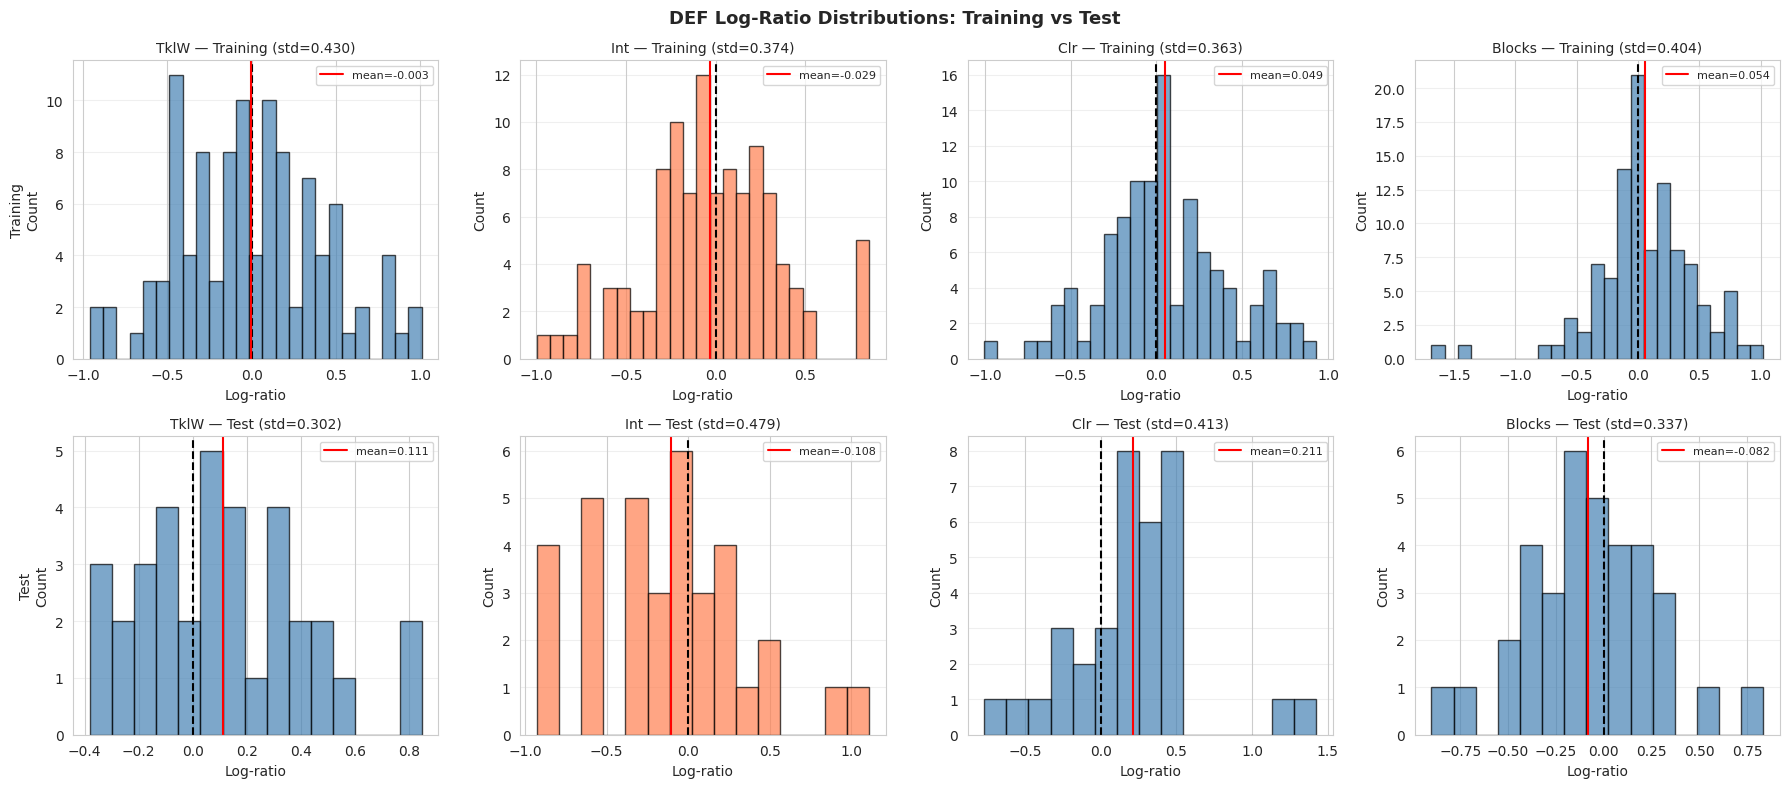

In [ ]:
# ============================================================================
# CELL 13: EDA — INTERCEPTIONS (Int) UNDER-COVERAGE DIAGNOSTIC (DEF)
# ============================================================================
# Investigates under-coverage for Int (0.686).
# Hypothesis: Int log-ratios have higher variance in the test set than training
# (test std=0.486 vs training std=0.380), causing intervals to be too narrow
# for the left tail of the test distribution.

print("\n" + "=" * 80)
print("EDA: INTERCEPTIONS (Int) UNDER-COVERAGE DIAGNOSTIC (DEF)")
print("=" * 80 + "\n")

import scipy.stats as stats

TARGET_STATS_DEF = ['Int']

# ---- 1. Log-ratio distribution: training vs test ----
print("--- Log-ratio distribution: training bridge vs test bridge ---")
print(f"  {'Stat':<8} {'Train mean':>12} {'Train std':>12} {'Test mean':>12} {'Test std':>12}")
print("  " + "-"*60)
for s in COMMON_STATS_DEF:
    tr = df_bridge_def[f'{s}_log_ratio'].values
    te = df_test_def[f'{s}_log_ratio'].values
    print(f"  {s:<8} {tr.mean():>12.4f} {tr.std():>12.4f} {te.mean():>12.4f} {te.std():>12.4f}")

print()

# ---- 2. Full distributional stats for Int ----
for s in TARGET_STATS_DEF:
    print(f"--- {s} detailed distribution ---")
    for bridge_df, bridge_label in [
        (df_bridge_def, 'Training Bridge'),
        (df_test_def,   'Test Bridge'),
    ]:
        vals = bridge_df[f'{s}_log_ratio'].values
        print(f"  {bridge_label} (n={len(vals)}):")
        print(f"    Mean={vals.mean():.4f}  Std={vals.std():.4f}  "
              f"Median={np.median(vals):.4f}  "
              f"IQR=[{np.percentile(vals,25):.3f}, {np.percentile(vals,75):.3f}]  "
              f"Min/Max=[{vals.min():.3f}, {vals.max():.3f}]")
        print(f"    Skew={stats.skew(vals):.4f}  Kurt={stats.kurtosis(vals):.4f}")
    print()

# ---- 3. Per-league log-ratio means (training bridge) ----
for s in TARGET_STATS_DEF:
    print(f"--- Per-league {s} log-ratio means (training bridge) ---")
    for league, grp in df_bridge_def.groupby('League_origin'):
        v = grp[f'{s}_log_ratio'].values
        print(f"  {league:<15} n={len(v):3d}  mean={v.mean():.4f}  std={v.std():.4f}")
    print()

# ---- 4. Prediction interval analysis ----
print("--- Prediction interval widths vs true spread ---")
print(f"  {'Stat':<8} {'Mean width':>12} {'True std':>12} {'Width/2 / std':>15} {'Coverage':>10}")
print("  " + "-"*60)
for s in TARGET_STATS_DEF:
    s_idx  = COMMON_STATS_DEF.index(s)
    mean_s = standardization_def[s]['mean']
    std_s  = standardization_def[s]['std']
    lo     = pred_p5_def[:, s_idx]  * std_s + mean_s
    hi     = pred_p95_def[:, s_idx] * std_s + mean_s
    true   = Y_test_def[:, s_idx]   * std_s + mean_s
    widths = hi - lo
    cov    = float(np.mean((true >= lo) & (true <= hi)))
    print(f"  {s:<8} {widths.mean():>12.4f} {true.std():>12.4f} "
          f"{(widths.mean()/2)/true.std():>15.2f}x {cov:>10.3f}")

print()

# ---- 5. Per-observation detail for Int ----
for s in TARGET_STATS_DEF:
    s_idx  = COMMON_STATS_DEF.index(s)
    mean_s = standardization_def[s]['mean']
    std_s  = standardization_def[s]['std']
    lo     = pred_p5_def[:, s_idx]  * std_s + mean_s
    hi     = pred_p95_def[:, s_idx] * std_s + mean_s
    true   = Y_test_def[:, s_idx]   * std_s + mean_s
    pred   = pred_mean_def[:, s_idx]* std_s + mean_s

    print(f"--- {s} per-observation detail ---")
    print(f"  {'Player':<25} {'Cohort':<20} {'True':>7} {'Pred':>7} "
          f"{'Lo':>7} {'Hi':>7} {'In?':>5}")
    for i in range(len(df_test_def)):
        player  = df_test_def.iloc[i]['Player']
        cohort  = df_test_def.iloc[i]['Cohort']
        covered = '✓' if lo[i] <= true[i] <= hi[i] else '✗'
        print(f"  {player:<25} {cohort:<20} {true[i]:>7.4f} {pred[i]:>7.4f} "
              f"{lo[i]:>7.4f} {hi[i]:>7.4f} {covered:>5}")
    print()

# ---- 6. Coverage breakdown by cohort ----
print("--- Coverage breakdown by cohort (Int) ---")
for s in TARGET_STATS_DEF:
    s_idx  = COMMON_STATS_DEF.index(s)
    mean_s = standardization_def[s]['mean']
    std_s  = standardization_def[s]['std']
    lo     = pred_p5_def[:, s_idx]  * std_s + mean_s
    hi     = pred_p95_def[:, s_idx] * std_s + mean_s
    true   = Y_test_def[:, s_idx]   * std_s + mean_s
    covered = (true >= lo) & (true <= hi)

    print(f"  {s}:")
    for cohort in df_test_def['Cohort'].unique():
        mask = df_test_def['Cohort'].values == cohort
        cov  = covered[mask].mean()
        n    = mask.sum()
        print(f"    {cohort}: {cov:.3f} ({covered[mask].sum()}/{n})")
    print()

# ---- 7. Plot: log-ratio distributions training vs test ----
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('DEF Log-Ratio Distributions: Training vs Test', fontsize=13, fontweight='bold')

for col_idx, s in enumerate(COMMON_STATS_DEF):
    tr_vals = df_bridge_def[f'{s}_log_ratio'].values
    te_vals = df_test_def[f'{s}_log_ratio'].values

    # Training
    ax = axes[0, col_idx]
    highlight = s in TARGET_STATS_DEF
    ax.hist(tr_vals, bins=25, color='coral' if highlight else 'steelblue',
            alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(tr_vals.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'mean={tr_vals.mean():.3f}')
    ax.set_title(f'{s} — Training (std={tr_vals.std():.3f})', fontsize=10)
    ax.set_xlabel('Log-ratio')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # Test
    ax = axes[1, col_idx]
    ax.hist(te_vals, bins=15, color='coral' if highlight else 'steelblue',
            alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(te_vals.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'mean={te_vals.mean():.3f}')
    ax.set_title(f'{s} — Test (std={te_vals.std():.3f})', fontsize=10)
    ax.set_xlabel('Log-ratio')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

axes[0, 0].set_ylabel('Training\nCount', fontsize=10)
axes[1, 0].set_ylabel('Test\nCount', fontsize=10)

plt.tight_layout()
plt.savefig('appendix_def_log_ratio_distributions.pdf', bbox_inches='tight', dpi=300)
plt.savefig('appendix_def_log_ratio_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

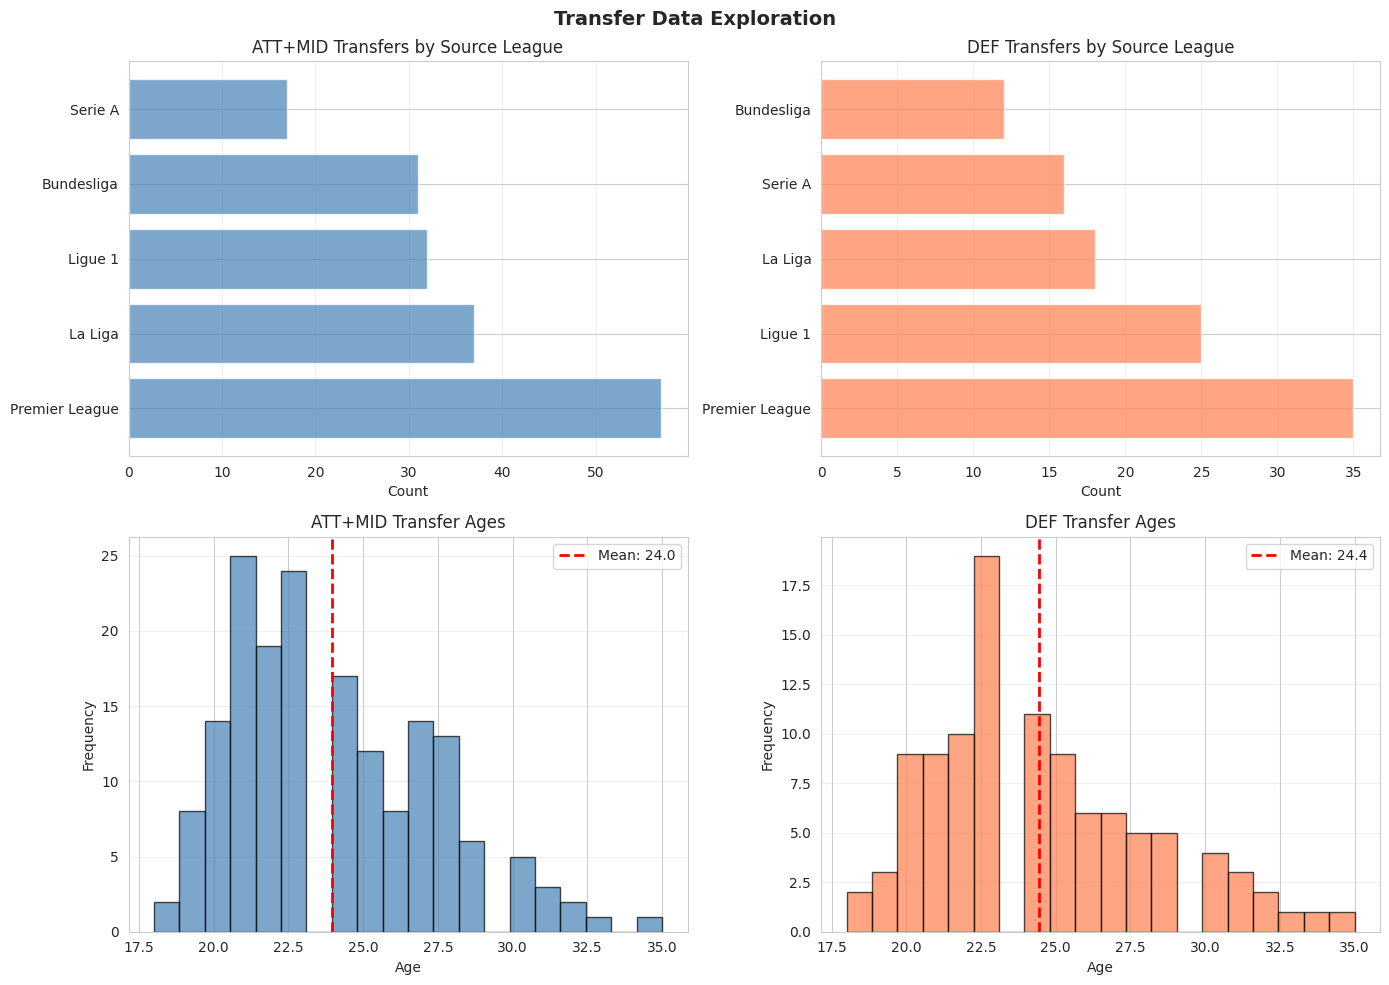

In [ ]:
# ============================================================================
# CELL 14: TRANSFER DATA EXPLORATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Transfer Data Exploration', fontsize=14, fontweight='bold')

ax = axes[0, 0]
if df_bridge_att_mid is not None:
    league_counts = df_bridge_att_mid['League_origin'].value_counts()
    ax.barh(league_counts.index, league_counts.values, color='steelblue', alpha=0.7)
    ax.set_xlabel('Count')
    ax.set_title('ATT+MID Transfers by Source League')
    ax.grid(alpha=0.3, axis='x')

ax = axes[0, 1]
if df_bridge_def is not None:
    league_counts = df_bridge_def['League_origin'].value_counts()
    ax.barh(league_counts.index, league_counts.values, color='coral', alpha=0.7)
    ax.set_xlabel('Count')
    ax.set_title('DEF Transfers by Source League')
    ax.grid(alpha=0.3, axis='x')

ax = axes[1, 0]
if df_bridge_att_mid is not None:
    ax.hist(df_bridge_att_mid['Age'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(df_bridge_att_mid['Age'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean: {df_bridge_att_mid['Age'].mean():.1f}")
    ax.set_xlabel('Age')
    ax.set_ylabel('Frequency')
    ax.set_title('ATT+MID Transfer Ages')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
if df_bridge_def is not None:
    ax.hist(df_bridge_def['Age'], bins=20, color='coral', alpha=0.7, edgecolor='black')
    ax.axvline(df_bridge_def['Age'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean: {df_bridge_def['Age'].mean():.1f}")
    ax.set_xlabel('Age')
    ax.set_ylabel('Frequency')
    ax.set_title('DEF Transfer Ages')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

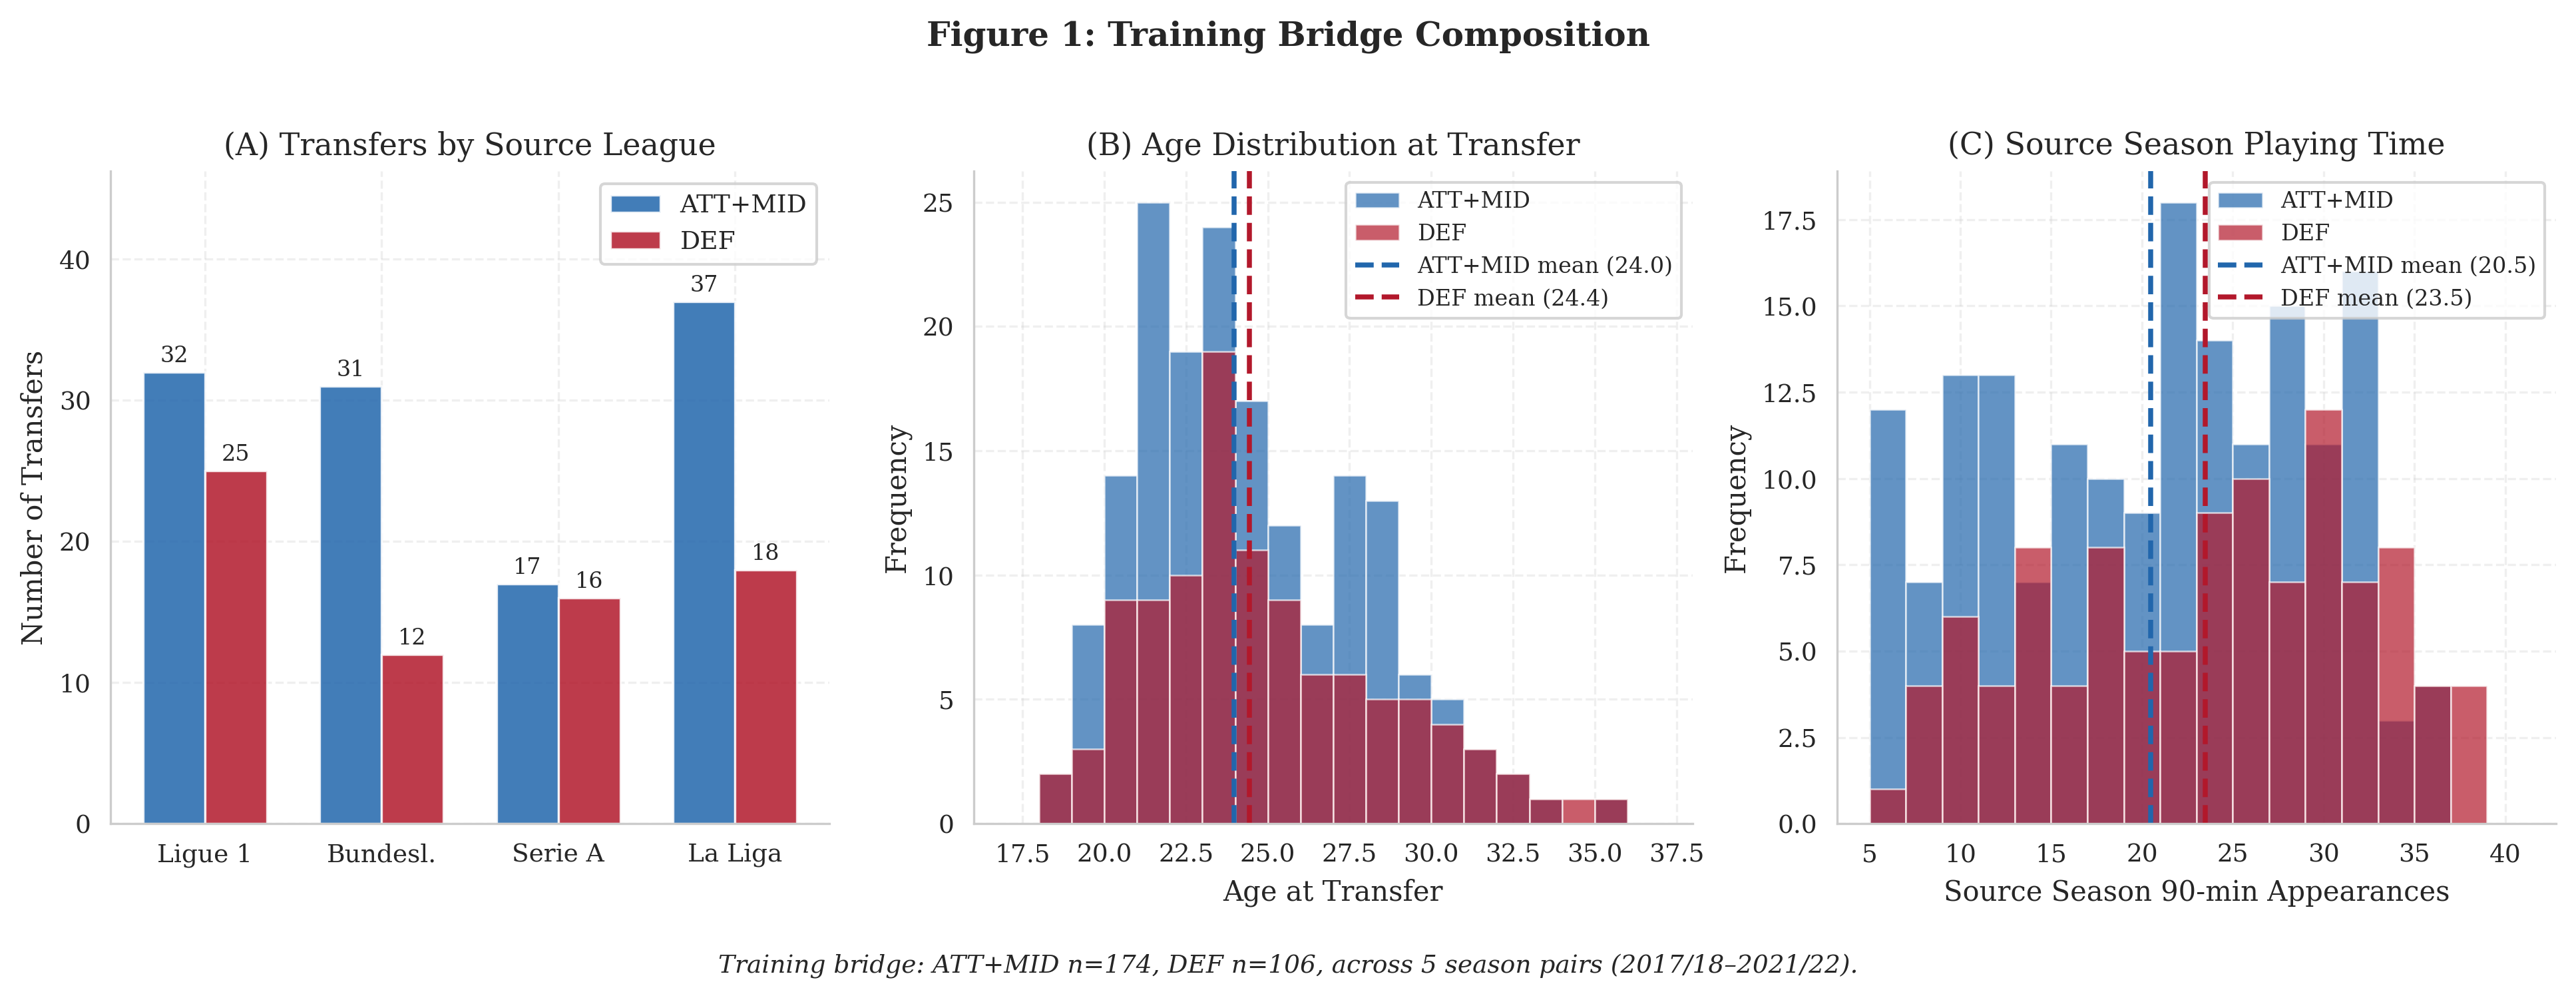

✓ Figure 1 saved


In [ ]:
# ============================================================================
# CELL 14b: FIGURE 1 — BRIDGE COMPOSITION (PUBLICATION)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PUB_STYLE = {
    'font.family':       'serif',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
}
plt.rcParams.update(PUB_STYLE)

LEAGUE_COLORS = {
    'Ligue 1':    '#4878CF',
    'Bundesliga': '#6ACC65',
    'Serie A':    '#D65F5F',
    'La Liga':    '#B47CC7',
    'Premier League': '#888888',
}
ATT_COLOR = '#2166AC'
DEF_COLOR = '#B2182B'

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle(
    'Figure 1: Training Bridge Composition',
    fontsize=12, fontweight='bold', y=1.02
)

# Panel A: League distribution (both bridges)
ax = axes[0]
leagues_order = ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']
att_counts = [
    len(df_bridge_att_mid[df_bridge_att_mid['League_origin'] == l])
    for l in leagues_order
]
def_counts = [
    len(df_bridge_def[df_bridge_def['League_origin'] == l])
    for l in leagues_order
]
x = np.arange(len(leagues_order))
w = 0.35
bars1 = ax.bar(x - w/2, att_counts, w, label='ATT+MID', color=ATT_COLOR,
               alpha=0.85, edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + w/2, def_counts,  w, label='DEF',     color=DEF_COLOR,
               alpha=0.85, edgecolor='white', linewidth=0.8)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.4, str(int(h)),
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['Ligue 1', 'Bundesl.', 'Serie A', 'La Liga'])
ax.set_ylabel('Number of Transfers')
ax.set_title('(A) Transfers by Source League')
ax.legend(loc='upper right')
ax.set_ylim(0, max(att_counts + def_counts) * 1.25)

# Panel B: Age distribution
ax = axes[1]
bins = np.arange(17, 38, 1)
ax.hist(df_bridge_att_mid['Age'], bins=bins, color=ATT_COLOR,
        alpha=0.7, edgecolor='white', linewidth=0.6, label='ATT+MID')
ax.hist(df_bridge_def['Age'],     bins=bins, color=DEF_COLOR,
        alpha=0.7, edgecolor='white', linewidth=0.6, label='DEF')
ax.axvline(df_bridge_att_mid['Age'].mean(), color=ATT_COLOR, linestyle='--',
           linewidth=1.8, label=f"ATT+MID mean ({df_bridge_att_mid['Age'].mean():.1f})")
ax.axvline(df_bridge_def['Age'].mean(),     color=DEF_COLOR,  linestyle='--',
           linewidth=1.8, label=f"DEF mean ({df_bridge_def['Age'].mean():.1f})")
ax.set_xlabel('Age at Transfer')
ax.set_ylabel('Frequency')
ax.set_title('(B) Age Distribution at Transfer')
ax.legend(loc='upper right', fontsize=8)

# Panel C: Source minutes (90s) distribution
ax = axes[2]
att_90s = df_bridge_att_mid['90s_src'].values
def_90s = df_bridge_def['90s_src'].values
bins_90 = np.arange(5, 42, 2)
ax.hist(att_90s, bins=bins_90, color=ATT_COLOR,
        alpha=0.7, edgecolor='white', linewidth=0.6, label='ATT+MID')
ax.hist(def_90s, bins=bins_90, color=DEF_COLOR,
        alpha=0.7, edgecolor='white', linewidth=0.6, label='DEF')
ax.axvline(att_90s.mean(), color=ATT_COLOR, linestyle='--',
           linewidth=1.8, label=f'ATT+MID mean ({att_90s.mean():.1f})')
ax.axvline(def_90s.mean(), color=DEF_COLOR,  linestyle='--',
           linewidth=1.8, label=f'DEF mean ({def_90s.mean():.1f})')
ax.set_xlabel('Source Season 90-min Appearances')
ax.set_ylabel('Frequency')
ax.set_title('(C) Source Season Playing Time')
ax.legend(loc='upper right', fontsize=8)

# Caption
n_att = len(df_bridge_att_mid)
n_def = len(df_bridge_def)
pairs = len(df_bridge_att_mid['Transfer_Season'].unique())
fig.text(
    0.5, -0.04,
    f'Training bridge: ATT+MID n={n_att}, DEF n={n_def}, across {pairs} season pairs (2017/18–2021/22).',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('figure1_bridge_composition.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure1_bridge_composition.png', bbox_inches='tight', dpi=300)
plt.show()
print("✓ Figure 1 saved")

In [ ]:
# ============================================================================
# CELL 15: ASSEMBLE RESULTS DICTIONARY
# ============================================================================

print("\n" + "=" * 80)
print("ASSEMBLING RESULTS DICTIONARY")
print("=" * 80 + "\n")

all_results = {
    'joint_att_mid': {
        'stats':           COMMON_STATS_ATT_MID,
        'joint_trace':     joint_trace_att_mid,
        'standardization': standardization_att_mid,
    },
    'joint_def': {
        'stats':           COMMON_STATS_DEF,
        'joint_trace':     joint_trace_def,
        'standardization': standardization_def,
    },
}


ASSEMBLING RESULTS DICTIONARY



In [ ]:
# ============================================================================
# CELL 16: LEAGUE TRANSLATION FUNCTION
# ============================================================================

def translate_league(stat_name, src_league, trg_league, results_dict):
    source_key   = 'joint_att_mid' if stat_name in COMMON_STATS_ATT_MID else 'joint_def'
    src          = results_dict[source_key]
    standardization = src['standardization']
    joint_trace  = src['joint_trace']
    stats_list   = COMMON_STATS_ATT_MID if stat_name in COMMON_STATS_ATT_MID else COMMON_STATS_DEF
    stat_idx     = stats_list.index(stat_name)
    std          = standardization[stat_name]['std']

    def league_tax_mean(league_name):
        if league_name == 'Premier League':
            return 0.0
        l_idx = LEAGUE_MAP[league_name]
        return joint_trace.posterior['league_tax'][:, :, l_idx, stat_idx].mean().item()

    src_tax = league_tax_mean(src_league)
    trg_tax = league_tax_mean(trg_league)
    return float(np.exp((src_tax - trg_tax) * std))

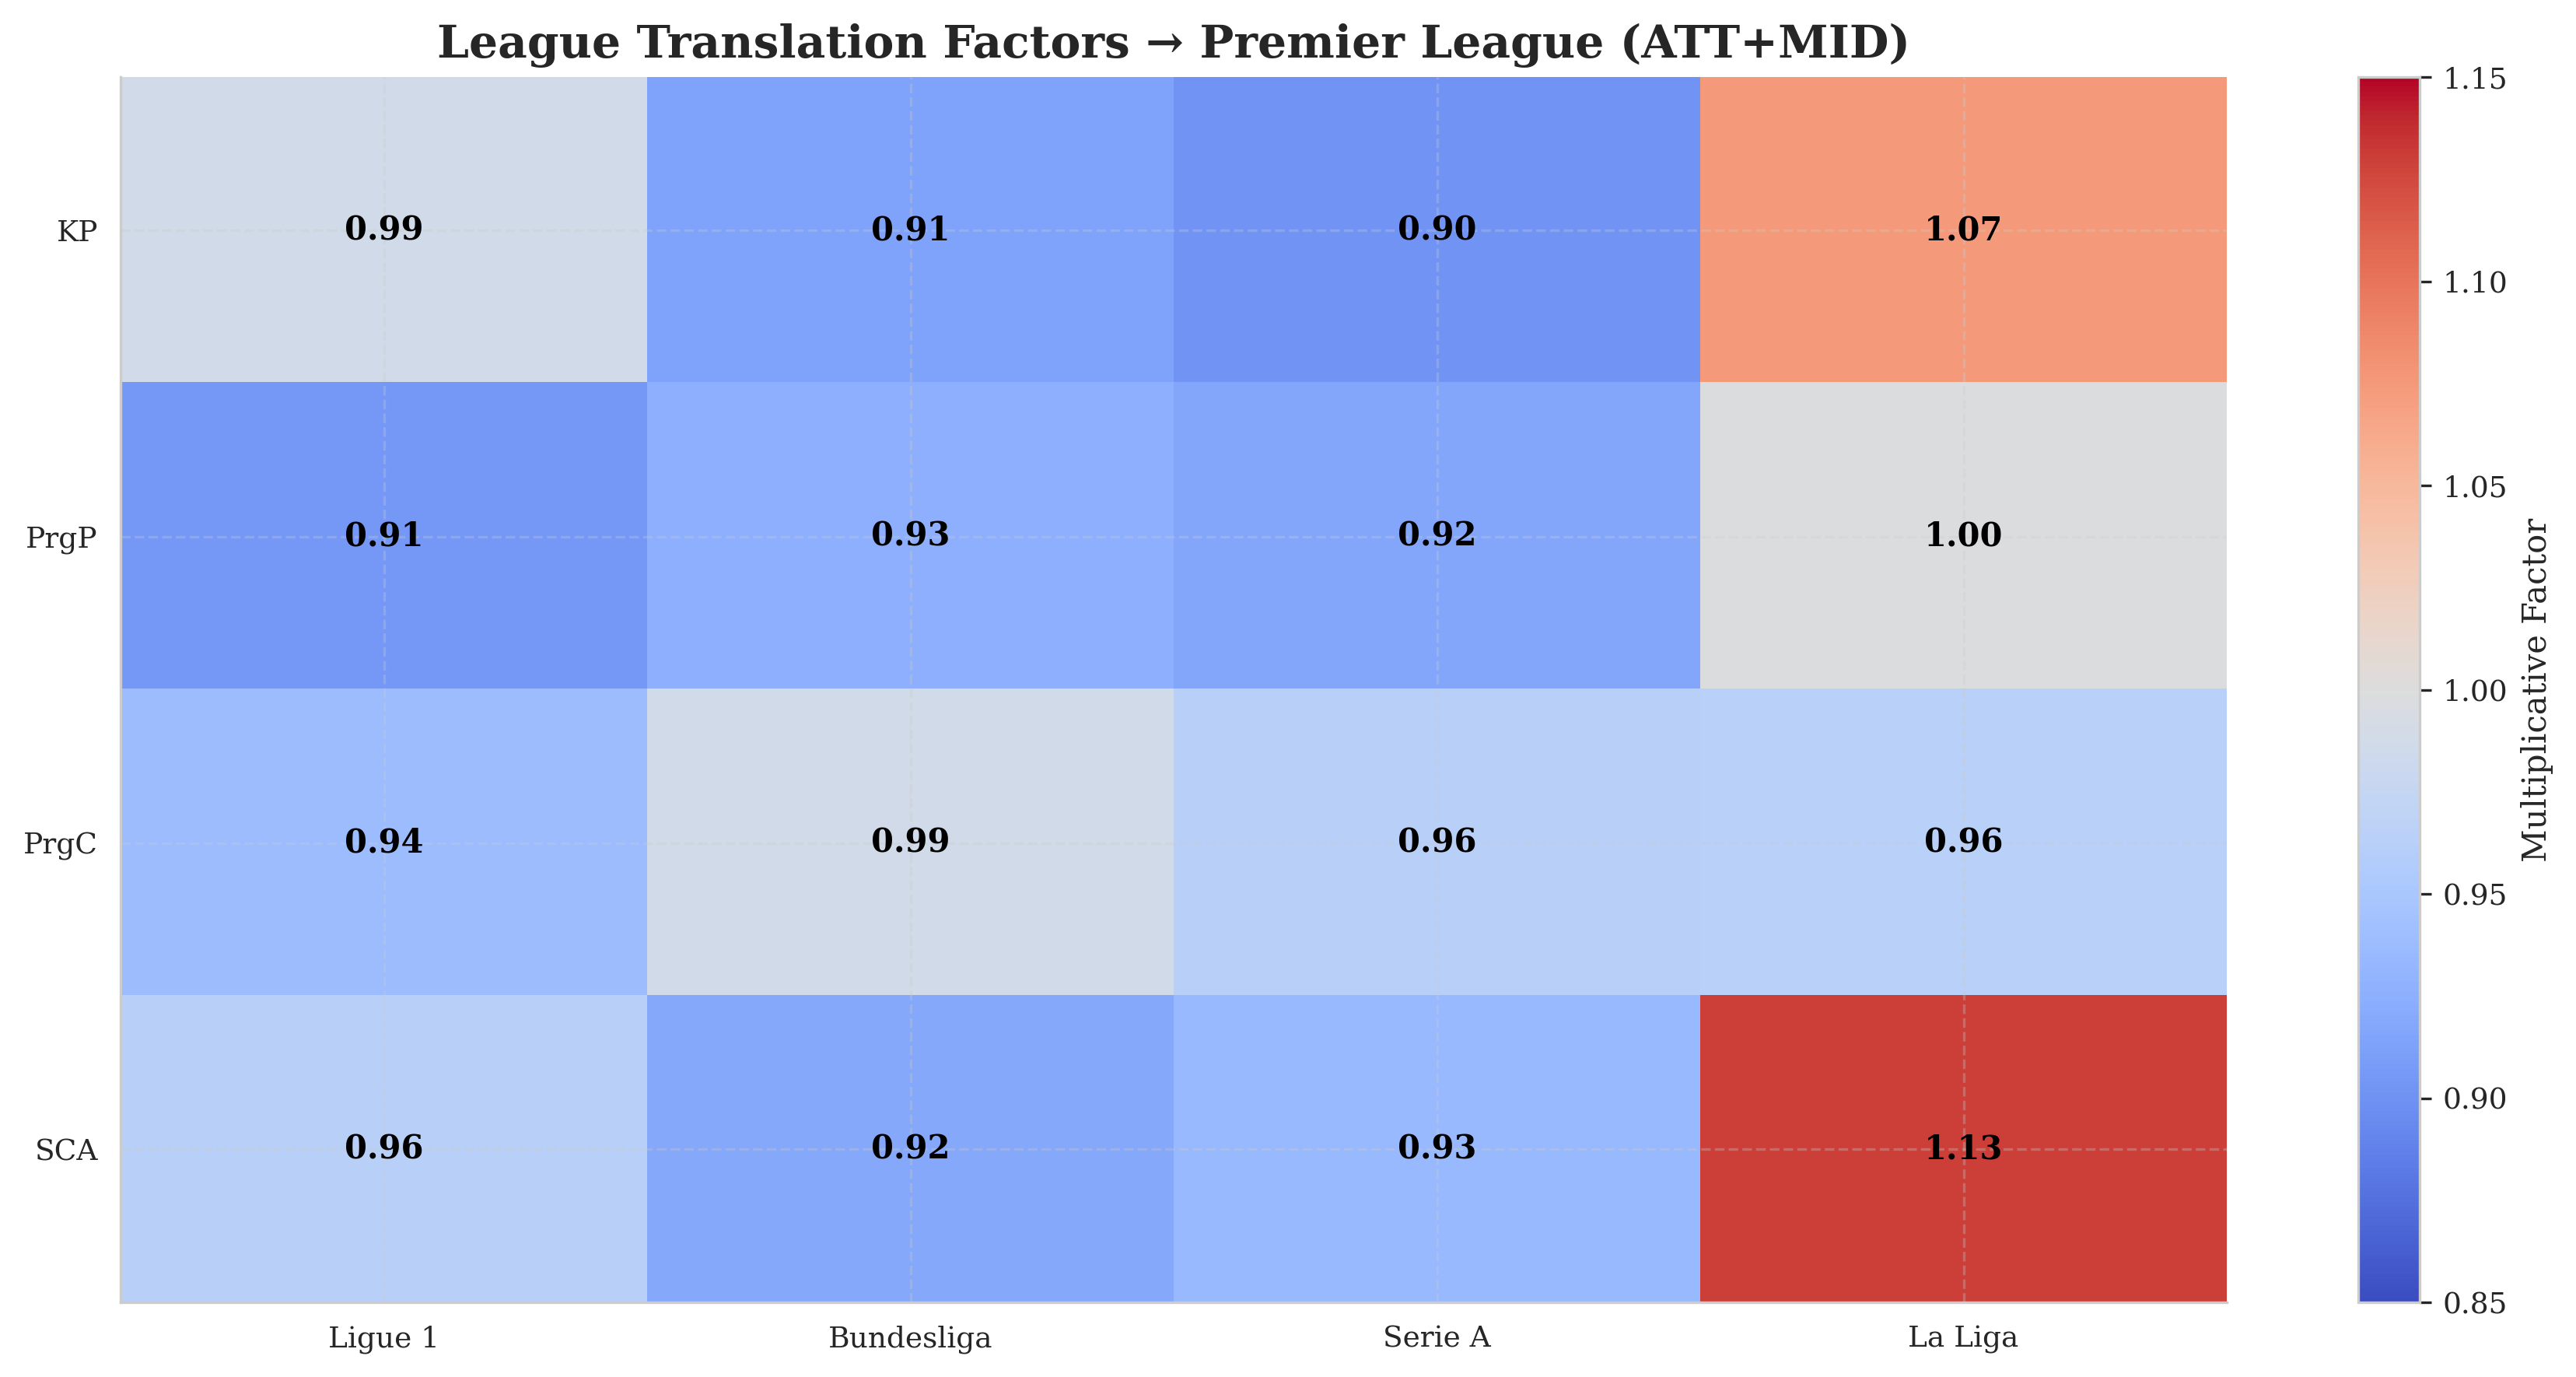

In [ ]:
# ============================================================================
# CELL 17: LEAGUE TRANSLATION HEATMAP — ATT+MID
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

leagues     = ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']
stats_plot  = COMMON_STATS_ATT_MID
trans_matrix = []

for stat in stats_plot:
    row = []
    for league in leagues:
        factor = translate_league(stat, league, 'Premier League', all_results)
        row.append(factor if factor else 1.0)
    trans_matrix.append(row)

im = ax.imshow(trans_matrix, cmap='coolwarm', aspect='auto', vmin=0.85, vmax=1.15)
ax.set_xticks(range(len(leagues)))
ax.set_yticks(range(len(stats_plot)))
ax.set_xticklabels(leagues)
ax.set_yticklabels(stats_plot)
ax.set_title('League Translation Factors → Premier League (ATT+MID)', fontsize=14, fontweight='bold')

for i in range(len(stats_plot)):
    for j in range(len(leagues)):
        ax.text(j, i, f'{trans_matrix[i][j]:.2f}',
                ha='center', va='center', color='black', fontweight='bold')

plt.colorbar(im, ax=ax, label='Multiplicative Factor')
plt.tight_layout()
plt.show()

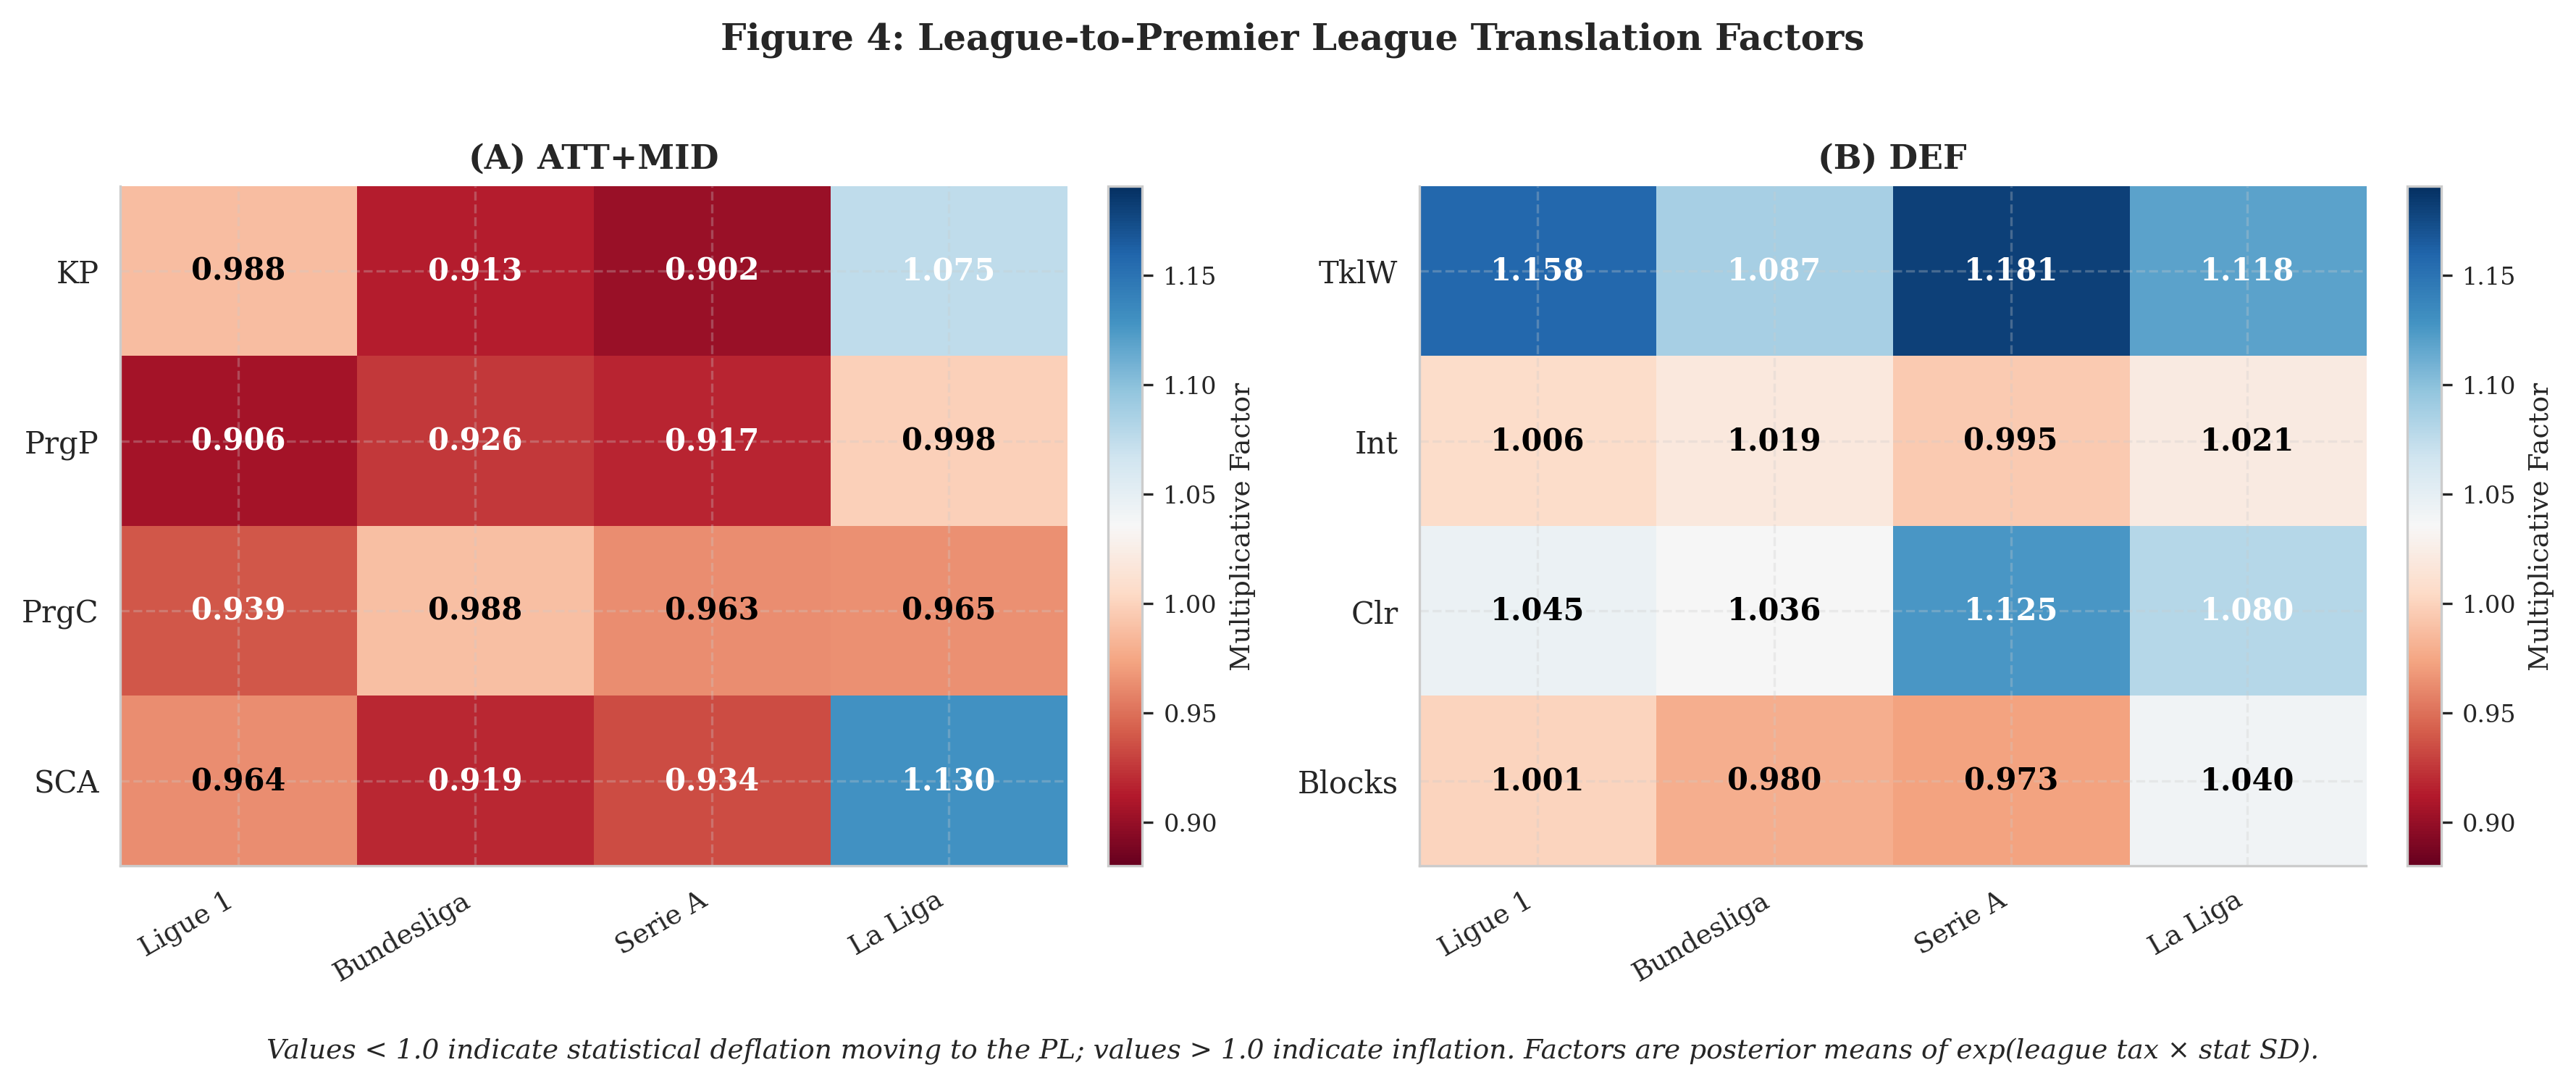

✓ Figure 4 saved


In [ ]:
# ============================================================================
# CELL 17b: FIGURE 4 — LEAGUE TRANSLATION HEATMAP ATT+MID + DEF (PUBLICATION)
# ============================================================================

plt.rcParams.update(PUB_STYLE)

leagues_hm  = ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']

def build_translation_matrix(stats_list):
    matrix = []
    for stat in stats_list:
        row = []
        for league in leagues_hm:
            factor = translate_league(stat, league, 'Premier League', all_results)
            row.append(factor if factor else 1.0)
        matrix.append(row)
    return np.array(matrix)

mat_att = build_translation_matrix(COMMON_STATS_ATT_MID)
mat_def = build_translation_matrix(COMMON_STATS_DEF)

# Shared colour scale centred at 1.0
all_vals   = np.concatenate([mat_att.flatten(), mat_def.flatten()])
vmin_hm    = min(0.88, all_vals.min() - 0.01)
vmax_hm    = max(1.12, all_vals.max() + 0.01)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                          gridspec_kw={'width_ratios': [4, 4]})
fig.suptitle(
    'Figure 4: League-to-Premier League Translation Factors',
    fontsize=12, fontweight='bold', y=1.02
)

for ax, matrix, stats_list, panel_label, bridge_label in [
    (axes[0], mat_att, COMMON_STATS_ATT_MID, 'A', 'ATT+MID'),
    (axes[1], mat_def, COMMON_STATS_DEF,      'B', 'DEF'),
]:
    im = ax.imshow(matrix, cmap='RdBu', aspect='auto',
                   vmin=vmin_hm, vmax=vmax_hm)

    ax.set_xticks(range(len(leagues_hm)))
    ax.set_yticks(range(len(stats_list)))
    ax.set_xticklabels(leagues_hm, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(stats_list, fontsize=10)
    ax.set_title(f'({panel_label}) {bridge_label}', fontsize=11, fontweight='bold')

    for i in range(len(stats_list)):
        for j in range(len(leagues_hm)):
            val       = matrix[i, j]
            text_col  = 'white' if abs(val - 1.0) > 0.06 else 'black'
            ax.text(j, i, f'{val:.3f}',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=text_col)

    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Multiplicative Factor', fontsize=9)
    cb.ax.tick_params(labelsize=8)

fig.text(
    0.5, -0.04,
    'Values < 1.0 indicate statistical deflation moving to the PL; '
    'values > 1.0 indicate inflation. '
    'Factors are posterior means of exp(league tax × stat SD).',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('figure4_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure4_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("✓ Figure 4 saved")


ML BASELINES — RIDGE & GBM

  Tuning Ridge (ATT+MID)...
  Best Ridge alpha: 100.0
  Tuning GBM (ATT+MID)...
  Best GBM params: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'min_samples_leaf': 5}
  Computing CV prediction intervals (ATT+MID)...

ML Baselines — ATT+MID:
Stat           Model    MAE   RMSE  Coverage_90  N_test
  KP Baseline: Ridge 0.3411 0.4557        0.978      45
  KP   Baseline: GBM 0.3079 0.3980        0.956      45
PrgP Baseline: Ridge 0.2920 0.4173        0.911      45
PrgP   Baseline: GBM 0.3079 0.4028        0.867      45
PrgC Baseline: Ridge 0.3312 0.4189        0.933      45
PrgC   Baseline: GBM 0.3296 0.4253        0.911      45
 SCA Baseline: Ridge 0.2469 0.3238        0.978      45
 SCA   Baseline: GBM 0.2613 0.3342        0.956      45

  Tuning Ridge (DEF)...
  Best Ridge alpha: 100.0
  Tuning GBM (DEF)...
  Best GBM params: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'min_samples_leaf': 5}
  Computing CV prediction interval

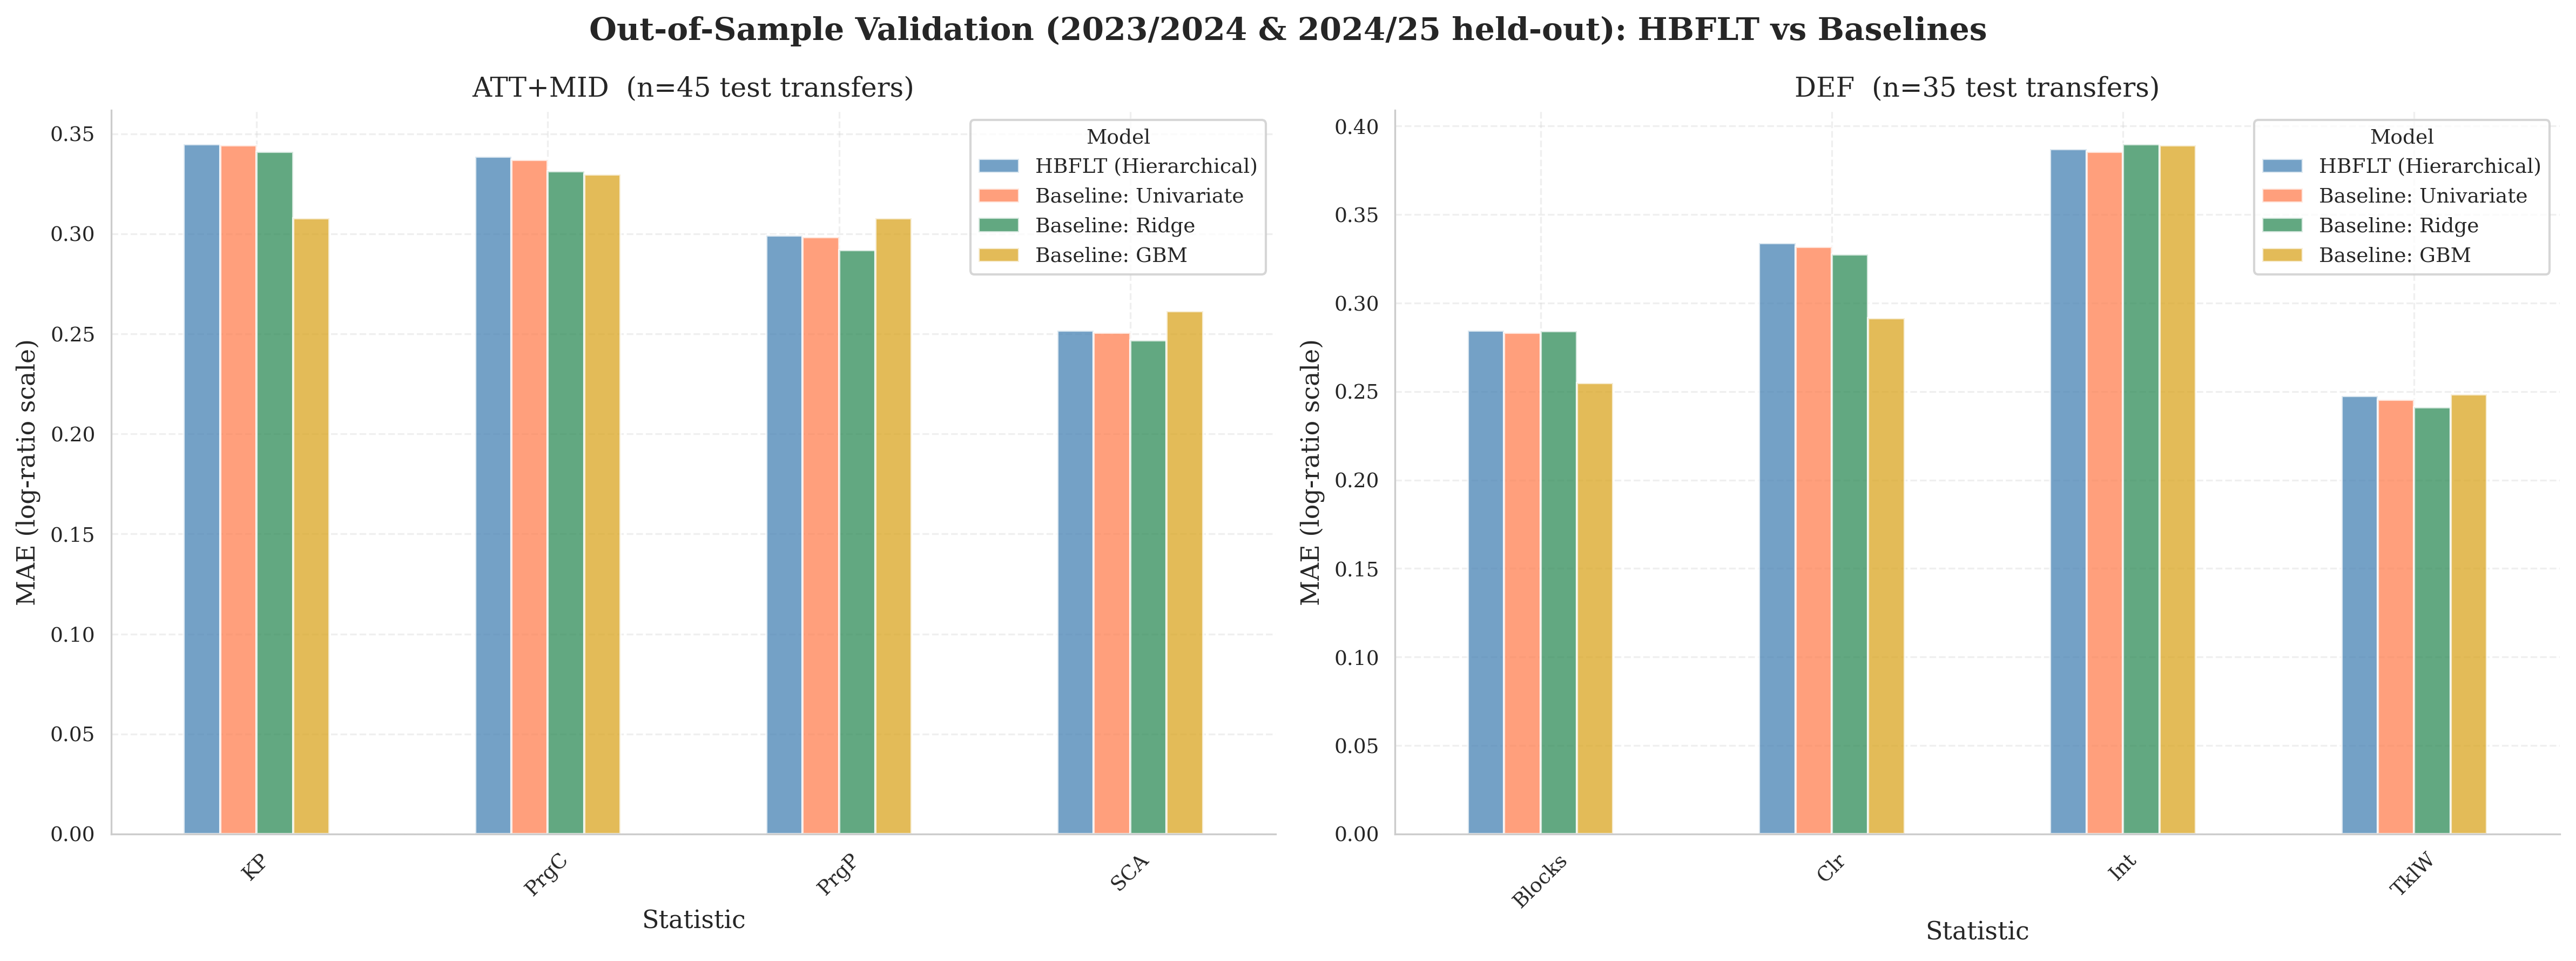

In [ ]:
# ============================================================================
# CELL 18: ML BASELINES + COMBINED VALIDATION TABLE & FIGURE
# ============================================================================

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_val_score, KFold

print("\n" + "=" * 80)
print("ML BASELINES — RIDGE & GBM")
print("=" * 80 + "\n")


def build_ml_features_ridge(df, stats_list, pos_labels=None):
    """Lean contextual feature set for Ridge (avoids source-stat collinearity)."""
    if pos_labels is not None:
        pos_map = {label: idx for idx, label in enumerate(pos_labels)}
        pos_enc = df['Position'].map(pos_map).fillna(0).astype(int).values
    else:
        pos_enc = df['pos_id'].values
    return np.column_stack([
        df['League_ID'].values,
        df['is_foreign'].values,
        df['Age'].values,
        pos_enc,
        df['90s_src'].values,
        df['Age'].values * df['League_ID'].values,
        df['Age'].values * df['is_foreign'].values,
    ])


def build_ml_features_gbm(df, stats_list, pos_labels=None):
    """Full feature set for GBM — includes source stat rates."""
    if pos_labels is not None:
        pos_map = {label: idx for idx, label in enumerate(pos_labels)}
        pos_enc = df['Position'].map(pos_map).fillna(0).astype(int).values
    else:
        pos_enc = df['pos_id'].values
    base = np.column_stack([
        df['League_ID'].values,
        df['is_foreign'].values,
        df['Age'].values,
        pos_enc,
        df['90s_src'].values,
    ])
    src_stats    = np.column_stack([df[f'{s}_src'].values for s in stats_list])
    interactions = np.column_stack([
        df['Age'].values * df['League_ID'].values,
        df['Age'].values * df['is_foreign'].values,
    ])
    return np.column_stack([base, src_stats, interactions])


def tune_ridge(X_train_sc, Y_train):
    """
    Independently CV-tune Ridge alpha for this bridge's training split.
    X_train_sc must already be scaled.
    """
    alphas     = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
    kf         = KFold(n_splits=5, shuffle=True, random_state=42)
    best_alpha = 1.0
    best_score = -np.inf
    for alpha in alphas:
        ridge  = MultiOutputRegressor(Ridge(alpha=alpha))
        scores = cross_val_score(
            ridge, X_train_sc, Y_train,
            cv=kf, scoring='neg_mean_absolute_error'
        )
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_alpha = alpha
    return best_alpha


def tune_gbm(X_train, Y_train):
    """
    CV-tune GBM. max_depth capped at 3 and min_samples_leaf >= 5
    to control variance on the relatively small training set.
    """
    param_grid = [
        {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05,  'min_samples_leaf': 5},
        {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05,  'min_samples_leaf': 5},
        {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.10,  'min_samples_leaf': 5},
        {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05,  'min_samples_leaf': 5},
        {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05,  'min_samples_leaf': 5},
    ]
    kf          = KFold(n_splits=5, shuffle=True, random_state=42)
    best_params = param_grid[0]
    best_score  = -np.inf
    for params in param_grid:
        gbm = MultiOutputRegressor(
            GradientBoostingRegressor(
                n_estimators    = params['n_estimators'],
                max_depth       = params['max_depth'],
                learning_rate   = params['learning_rate'],
                min_samples_leaf= params['min_samples_leaf'],
                random_state    = 42,
            )
        )
        scores = cross_val_score(
            gbm, X_train, Y_train,
            cv=kf, scoring='neg_mean_absolute_error'
        )
        if scores.mean() > best_score:
            best_score  = scores.mean()
            best_params = params
    return best_params


def compute_cv_prediction_intervals(model, X_train, Y_train, X_test, n_splits=5):
    """
    Out-of-fold residual std for prediction intervals (not training residuals).
    Refits on full training set before predicting on test.
    """
    kf            = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_residuals = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        Y_tr, Y_val = Y_train[train_idx], Y_train[val_idx]
        model.fit(X_tr, Y_tr)
        oof_residuals.append(Y_val - model.predict(X_val))
    oof_residuals = np.vstack(oof_residuals)
    resid_std     = oof_residuals.std(axis=0, ddof=1)
    model.fit(X_train, Y_train)
    Y_pred_test = model.predict(X_test)
    return Y_pred_test, Y_pred_test - 1.64 * resid_std, Y_pred_test + 1.64 * resid_std


def run_ml_baselines(df_train, Y_train_std,
                     df_test,  Y_test_std,
                     stats_list, standardization,
                     pos_labels_train, label):

    X_train_ridge    = build_ml_features_ridge(df_train, stats_list)
    X_test_ridge     = build_ml_features_ridge(df_test, stats_list,
                                                pos_labels=pos_labels_train)
    scaler           = StandardScaler()
    X_train_ridge_sc = scaler.fit_transform(X_train_ridge)
    X_test_ridge_sc  = scaler.transform(X_test_ridge)

    X_train_gbm = build_ml_features_gbm(df_train, stats_list)
    X_test_gbm  = build_ml_features_gbm(df_test, stats_list,
                                         pos_labels=pos_labels_train)

    print(f"  Tuning Ridge ({label})...")
    best_alpha = tune_ridge(X_train_ridge_sc, Y_train_std)
    print(f"  Best Ridge alpha: {best_alpha}")
    ridge = MultiOutputRegressor(Ridge(alpha=best_alpha))

    print(f"  Tuning GBM ({label})...")
    best_params = tune_gbm(X_train_gbm, Y_train_std)
    print(f"  Best GBM params: {best_params}")
    gbm = MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators    = best_params['n_estimators'],
            max_depth       = best_params['max_depth'],
            learning_rate   = best_params['learning_rate'],
            min_samples_leaf= best_params['min_samples_leaf'],
            random_state    = 42,
        )
    )

    print(f"  Computing CV prediction intervals ({label})...")
    Y_pred_ridge, ridge_p5, ridge_p95 = compute_cv_prediction_intervals(
        ridge, X_train_ridge_sc, Y_train_std, X_test_ridge_sc
    )
    Y_pred_gbm, gbm_p5, gbm_p95 = compute_cv_prediction_intervals(
        gbm, X_train_gbm, Y_train_std, X_test_gbm
    )

    results = []
    for j, stat in enumerate(stats_list):
        mean_s = standardization[stat]['mean']
        std_s  = standardization[stat]['std']
        y_true   = Y_test_std[:, j]   * std_s + mean_s
        y_pred_r = Y_pred_ridge[:, j] * std_s + mean_s
        y_pred_g = Y_pred_gbm[:, j]   * std_s + mean_s
        y_lo_r   = ridge_p5[:, j]     * std_s + mean_s
        y_hi_r   = ridge_p95[:, j]    * std_s + mean_s
        y_lo_g   = gbm_p5[:, j]       * std_s + mean_s
        y_hi_g   = gbm_p95[:, j]      * std_s + mean_s
        results.append({
            'Stat':        stat,
            'Model':       'Baseline: Ridge',
            'MAE':         round(float(np.mean(np.abs(y_true - y_pred_r))), 4),
            'RMSE':        round(float(np.sqrt(np.mean((y_true - y_pred_r) ** 2))), 4),
            'Coverage_90': round(float(np.mean((y_true >= y_lo_r) & (y_true <= y_hi_r))), 3),
            'N_test':      len(df_test),
        })
        results.append({
            'Stat':        stat,
            'Model':       'Baseline: GBM',
            'MAE':         round(float(np.mean(np.abs(y_true - y_pred_g))), 4),
            'RMSE':        round(float(np.sqrt(np.mean((y_true - y_pred_g) ** 2))), 4),
            'Coverage_90': round(float(np.mean((y_true >= y_lo_g) & (y_true <= y_hi_g))), 3),
            'N_test':      len(df_test),
        })
    return pd.DataFrame(results)


if not df_test_att.empty:
    ml_att = run_ml_baselines(
        df_bridge_att_mid, Y_std_att_mid,
        df_test_att,       Y_test_att,
        COMMON_STATS_ATT_MID, standardization_att_mid,
        pos_labels_att_mid, label='ATT+MID',
    )
    print("\nML Baselines — ATT+MID:")
    print(ml_att.to_string(index=False))
    print()

if not df_test_def.empty:
    ml_def = run_ml_baselines(
        df_bridge_def, Y_std_def,
        df_test_def,   Y_test_def,
        COMMON_STATS_DEF, standardization_def,
        pos_labels_def, label='DEF',
    )
    print("ML Baselines — DEF:")
    print(ml_def.to_string(index=False))
    print()

# --- Combined validation table & figure ---
if not df_test_att.empty and not df_test_def.empty:
    val_all_att = pd.concat([val_hb_att, val_uni_att, ml_att], ignore_index=True)
    val_all_def = pd.concat([val_hb_def, val_uni_def, ml_def], ignore_index=True)

    print("=" * 80)
    print("FULL VALIDATION TABLE — ATT+MID")
    print("=" * 80)
    print(val_all_att[['Stat', 'Model', 'MAE', 'RMSE', 'Coverage_90']].to_string(index=False))

    print()
    print("=" * 80)
    print("FULL VALIDATION TABLE — DEF")
    print("=" * 80)
    print(val_all_def[['Stat', 'Model', 'MAE', 'RMSE', 'Coverage_90']].to_string(index=False))

    model_colors = {
        'HBFLT (Hierarchical)': 'steelblue',
        'Baseline: Univariate': 'coral',
        'Baseline: Ridge':      'seagreen',
        'Baseline: GBM':        'goldenrod',
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        'Out-of-Sample Validation (2023/2024 & 2024/25 held-out): HBFLT vs Baselines',
        fontsize=14, fontweight='bold'
    )
    for ax, val_df, title in [
        (axes[0], val_all_att, f'ATT+MID  (n={len(df_test_att)} test transfers)'),
        (axes[1], val_all_def, f'DEF  (n={len(df_test_def)} test transfers)'),
    ]:
        pivot     = val_df.pivot_table(values='MAE', index='Stat', columns='Model')
        col_order = [c for c in model_colors if c in pivot.columns]
        colors    = [model_colors[c] for c in col_order]
        pivot[col_order].plot(kind='bar', ax=ax, color=colors, alpha=0.75, edgecolor='white')
        ax.set_title(title, fontsize=12)
        ax.set_ylabel('MAE (log-ratio scale)', fontsize=11)
        ax.set_xlabel('Statistic', fontsize=11)
        ax.legend(title='Model', fontsize=9, title_fontsize=9)
        ax.grid(alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

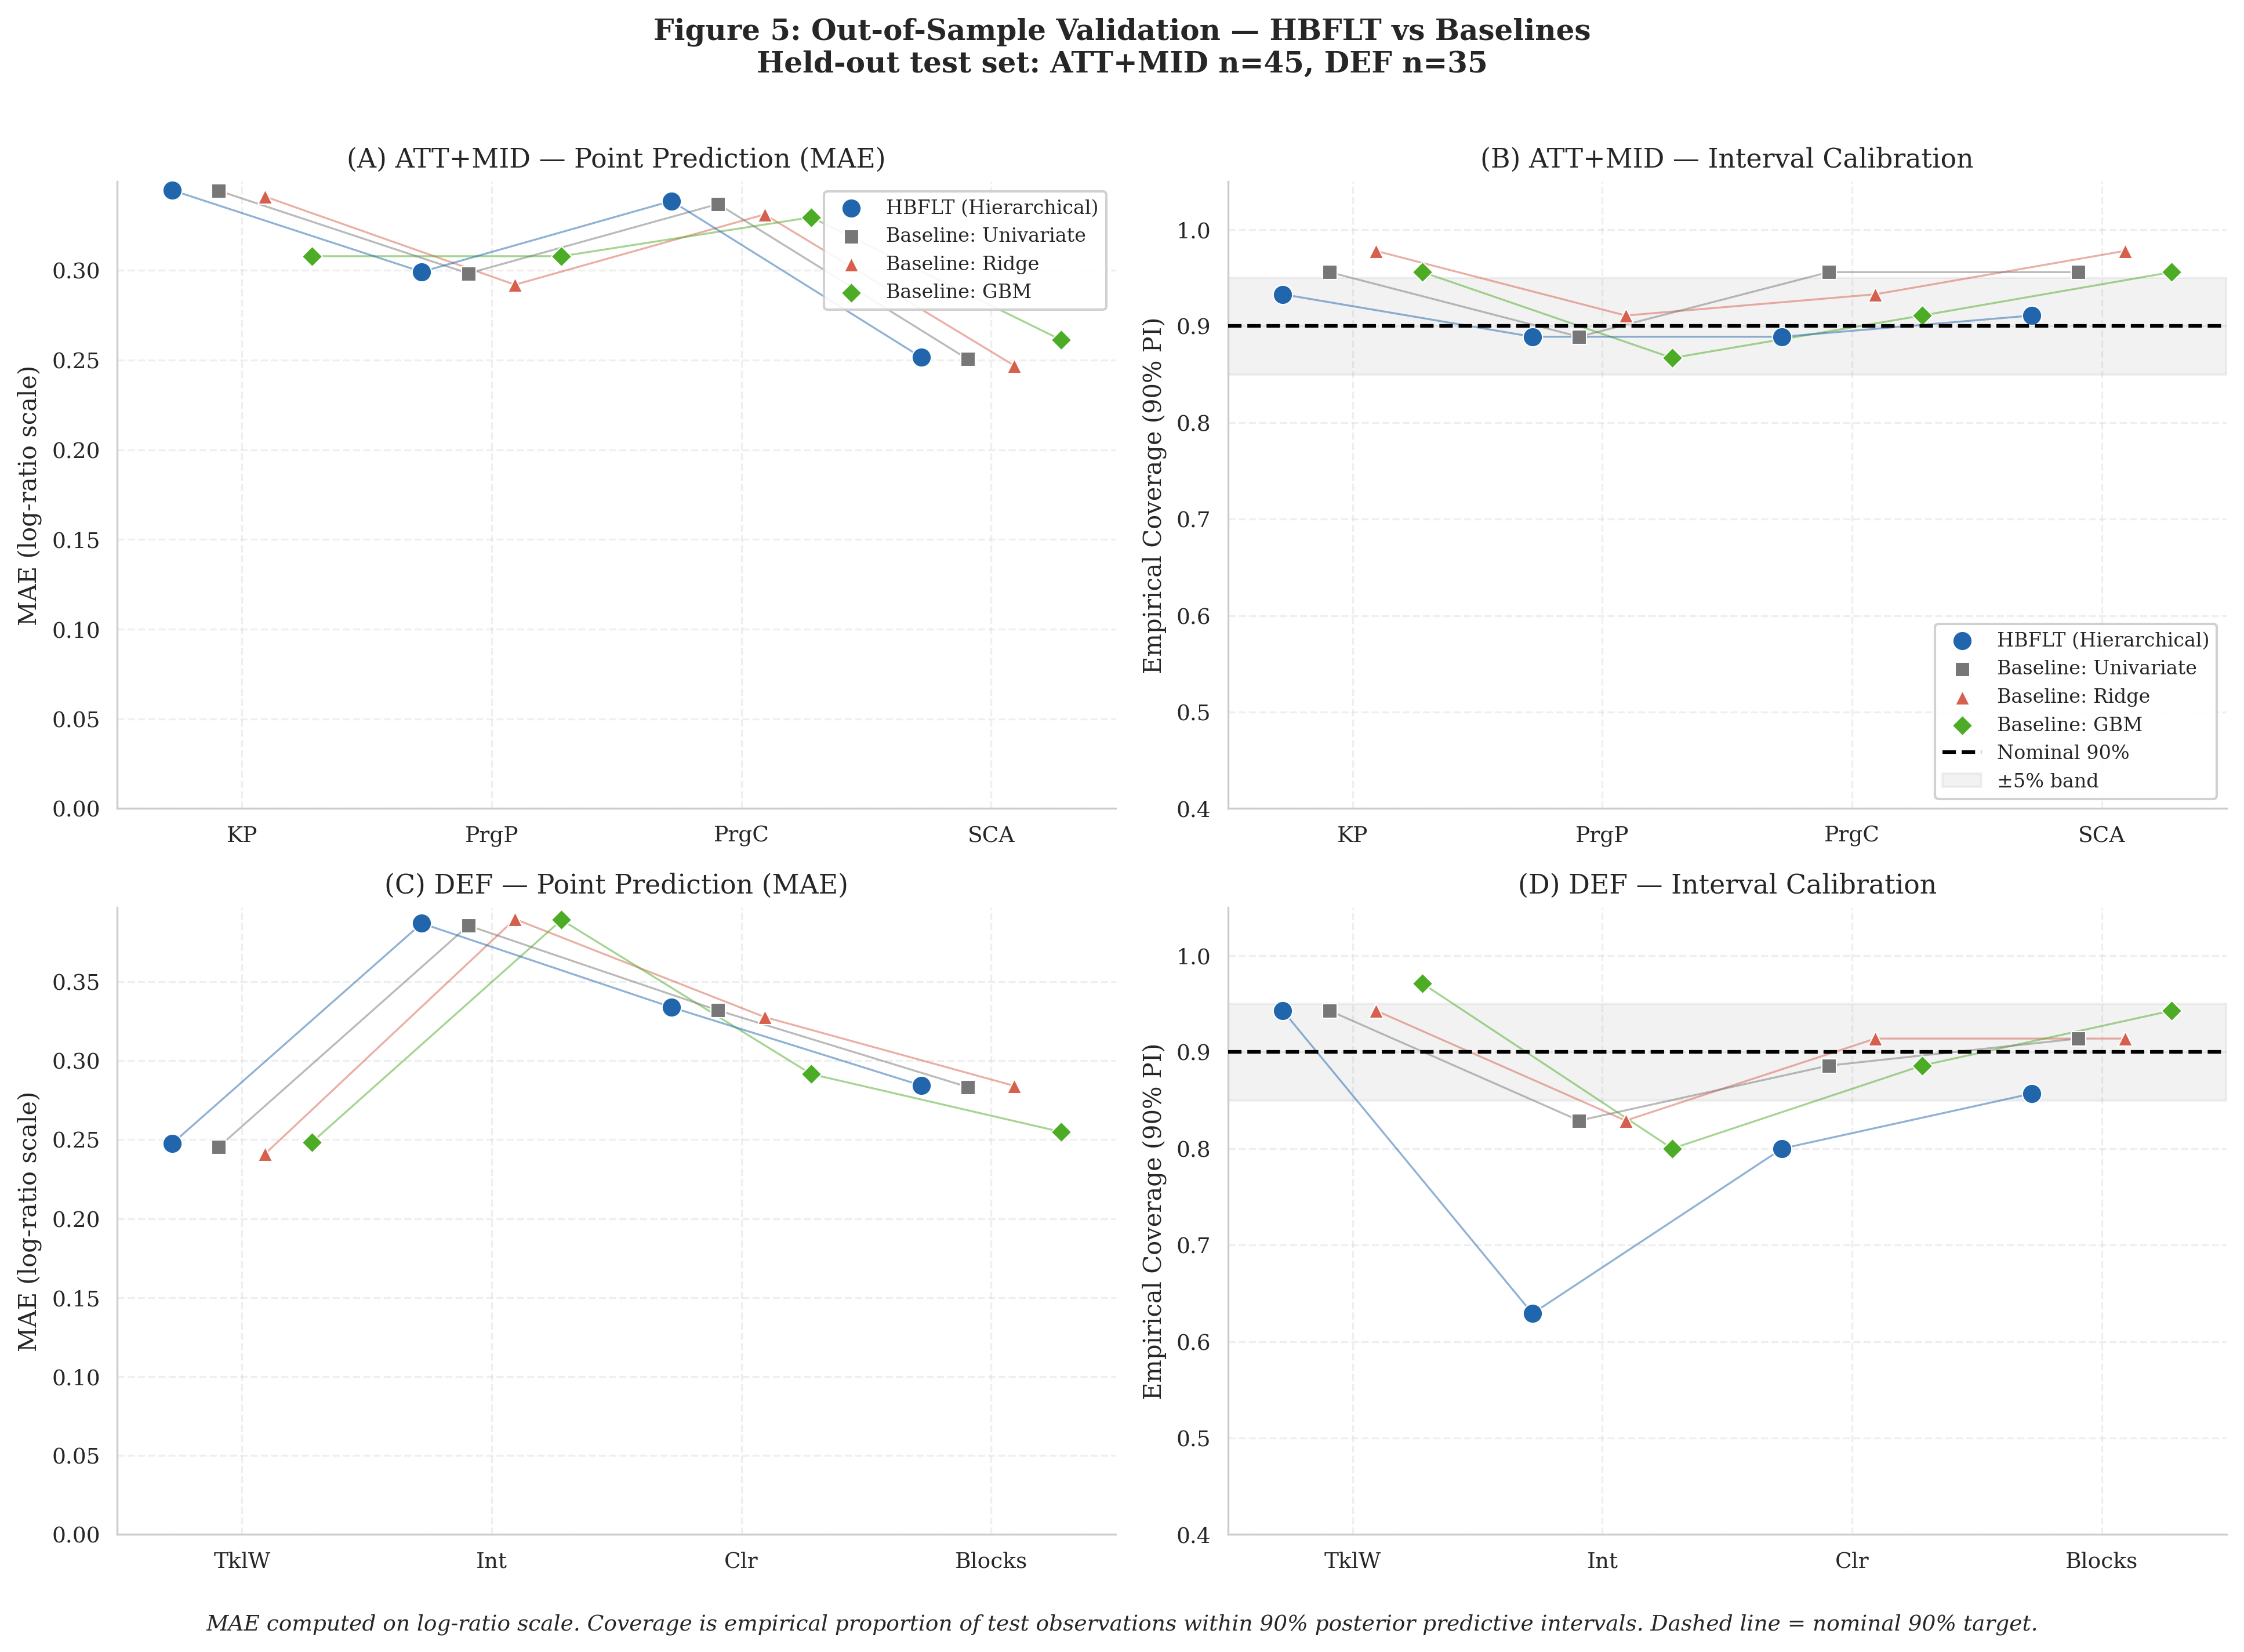

✓ Figure 5 saved


In [ ]:
# ============================================================================
# CELL 18b: FIGURE 5 — OOS VALIDATION (PUBLICATION)
# ============================================================================
# Redesigned from grouped bar chart to dot plot with coverage annotations.
# Cleaner for a journal figure with 4 models × 4 stats.

plt.rcParams.update(PUB_STYLE)

MODEL_STYLES = {
    'HBFLT (Hierarchical)': {'color': '#2166AC', 'marker': 'o', 'ms': 8,  'zorder': 5},
    'Baseline: Univariate':  {'color': '#777777', 'marker': 's', 'ms': 6,  'zorder': 4},
    'Baseline: Ridge':       {'color': '#D6604D', 'marker': '^', 'ms': 6,  'zorder': 3},
    'Baseline: GBM':         {'color': '#4DAC26', 'marker': 'D', 'ms': 6,  'zorder': 3},
}
NOMINAL_COV = 0.90

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Figure 5: Out-of-Sample Validation — HBFLT vs Baselines\n'
    f'Held-out test set: ATT+MID n={len(df_test_att)}, DEF n={len(df_test_def)}',
    fontsize=12, fontweight='bold', y=1.01
)

for row_idx, (val_df, stats_list, bridge_label) in enumerate([
    (val_all_att, COMMON_STATS_ATT_MID, 'ATT+MID'),
    (val_all_def, COMMON_STATS_DEF,     'DEF'),
]):
    # Panel left: MAE dot plot
    ax_mae = axes[row_idx, 0]
    ax_cov = axes[row_idx, 1]

    stats_x = {s: i for i, s in enumerate(stats_list)}
    x_vals  = np.arange(len(stats_list))
    n_models = len(MODEL_STYLES)
    offsets  = np.linspace(-0.28, 0.28, n_models)

    for m_idx, (model_name, style) in enumerate(MODEL_STYLES.items()):
        model_df = val_df[val_df['Model'] == model_name]
        if model_df.empty:
            continue
        mae_vals = []
        cov_vals = []
        xs       = []
        for s in stats_list:
            row = model_df[model_df['Stat'] == s]
            if not row.empty:
                mae_vals.append(row['MAE'].values[0])
                cov_vals.append(row['Coverage_90'].values[0])
                xs.append(stats_x[s] + offsets[m_idx])

        ax_mae.scatter(
            xs, mae_vals,
            color=style['color'], marker=style['marker'],
            s=style['ms']**2, zorder=style['zorder'],
            label=model_name, edgecolors='white', linewidths=0.5,
        )
        ax_mae.plot(
            xs, mae_vals,
            color=style['color'], linewidth=0.8, alpha=0.5, zorder=style['zorder'] - 1,
        )

        ax_cov.scatter(
            xs, cov_vals,
            color=style['color'], marker=style['marker'],
            s=style['ms']**2, zorder=style['zorder'],
            label=model_name, edgecolors='white', linewidths=0.5,
        )
        ax_cov.plot(
            xs, cov_vals,
            color=style['color'], linewidth=0.8, alpha=0.5, zorder=style['zorder'] - 1,
        )

    # MAE panel formatting
    ax_mae.set_xticks(x_vals)
    ax_mae.set_xticklabels(stats_list)
    ax_mae.set_ylabel('MAE (log-ratio scale)')
    ax_mae.set_title(f'({chr(65 + row_idx*2)}) {bridge_label} — Point Prediction (MAE)')
    ax_mae.set_ylim(bottom=0)
    if row_idx == 0:
        ax_mae.legend(loc='upper right', fontsize=8, framealpha=0.9)

    # Coverage panel formatting
    ax_cov.axhline(NOMINAL_COV, color='black', linewidth=1.5,
                   linestyle='--', label=f'Nominal {NOMINAL_COV:.0%}', zorder=6)
    ax_cov.fill_between(
        [-0.5, len(stats_list) - 0.5],
        [NOMINAL_COV - 0.05] * 2, [NOMINAL_COV + 0.05] * 2,
        color='grey', alpha=0.10, label='±5% band',
    )
    ax_cov.set_xticks(x_vals)
    ax_cov.set_xticklabels(stats_list)
    ax_cov.set_ylabel('Empirical Coverage (90% PI)')
    ax_cov.set_ylim(0.4, 1.05)
    ax_cov.set_title(f'({chr(66 + row_idx*2)}) {bridge_label} — Interval Calibration')
    ax_cov.set_xlim(-0.5, len(stats_list) - 0.5)
    ax_mae.set_xlim(-0.5, len(stats_list) - 0.5)
    if row_idx == 0:
        ax_cov.legend(loc='lower right', fontsize=8, framealpha=0.9)

fig.text(
    0.5, -0.02,
    'MAE computed on log-ratio scale. Coverage is empirical proportion of test observations '
    'within 90% posterior predictive intervals. Dashed line = nominal 90% target.',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('figure5_oos_validation.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure5_oos_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print("✓ Figure 5 saved")


CALIBRATION CURVES (OOS)

ATT+MID — Calibration at 90% nominal:
Stat  Nominal  Empirical  Delta
  KP      0.9      0.933  0.033
PrgP      0.9      0.889 -0.011
PrgC      0.9      0.867 -0.033
 SCA      0.9      0.911  0.011
DEF — Calibration at 90% nominal:
  Stat  Nominal  Empirical  Delta
  TklW      0.9      0.943  0.043
   Int      0.9      0.629 -0.271
   Clr      0.9      0.829 -0.071
Blocks      0.9      0.857 -0.043


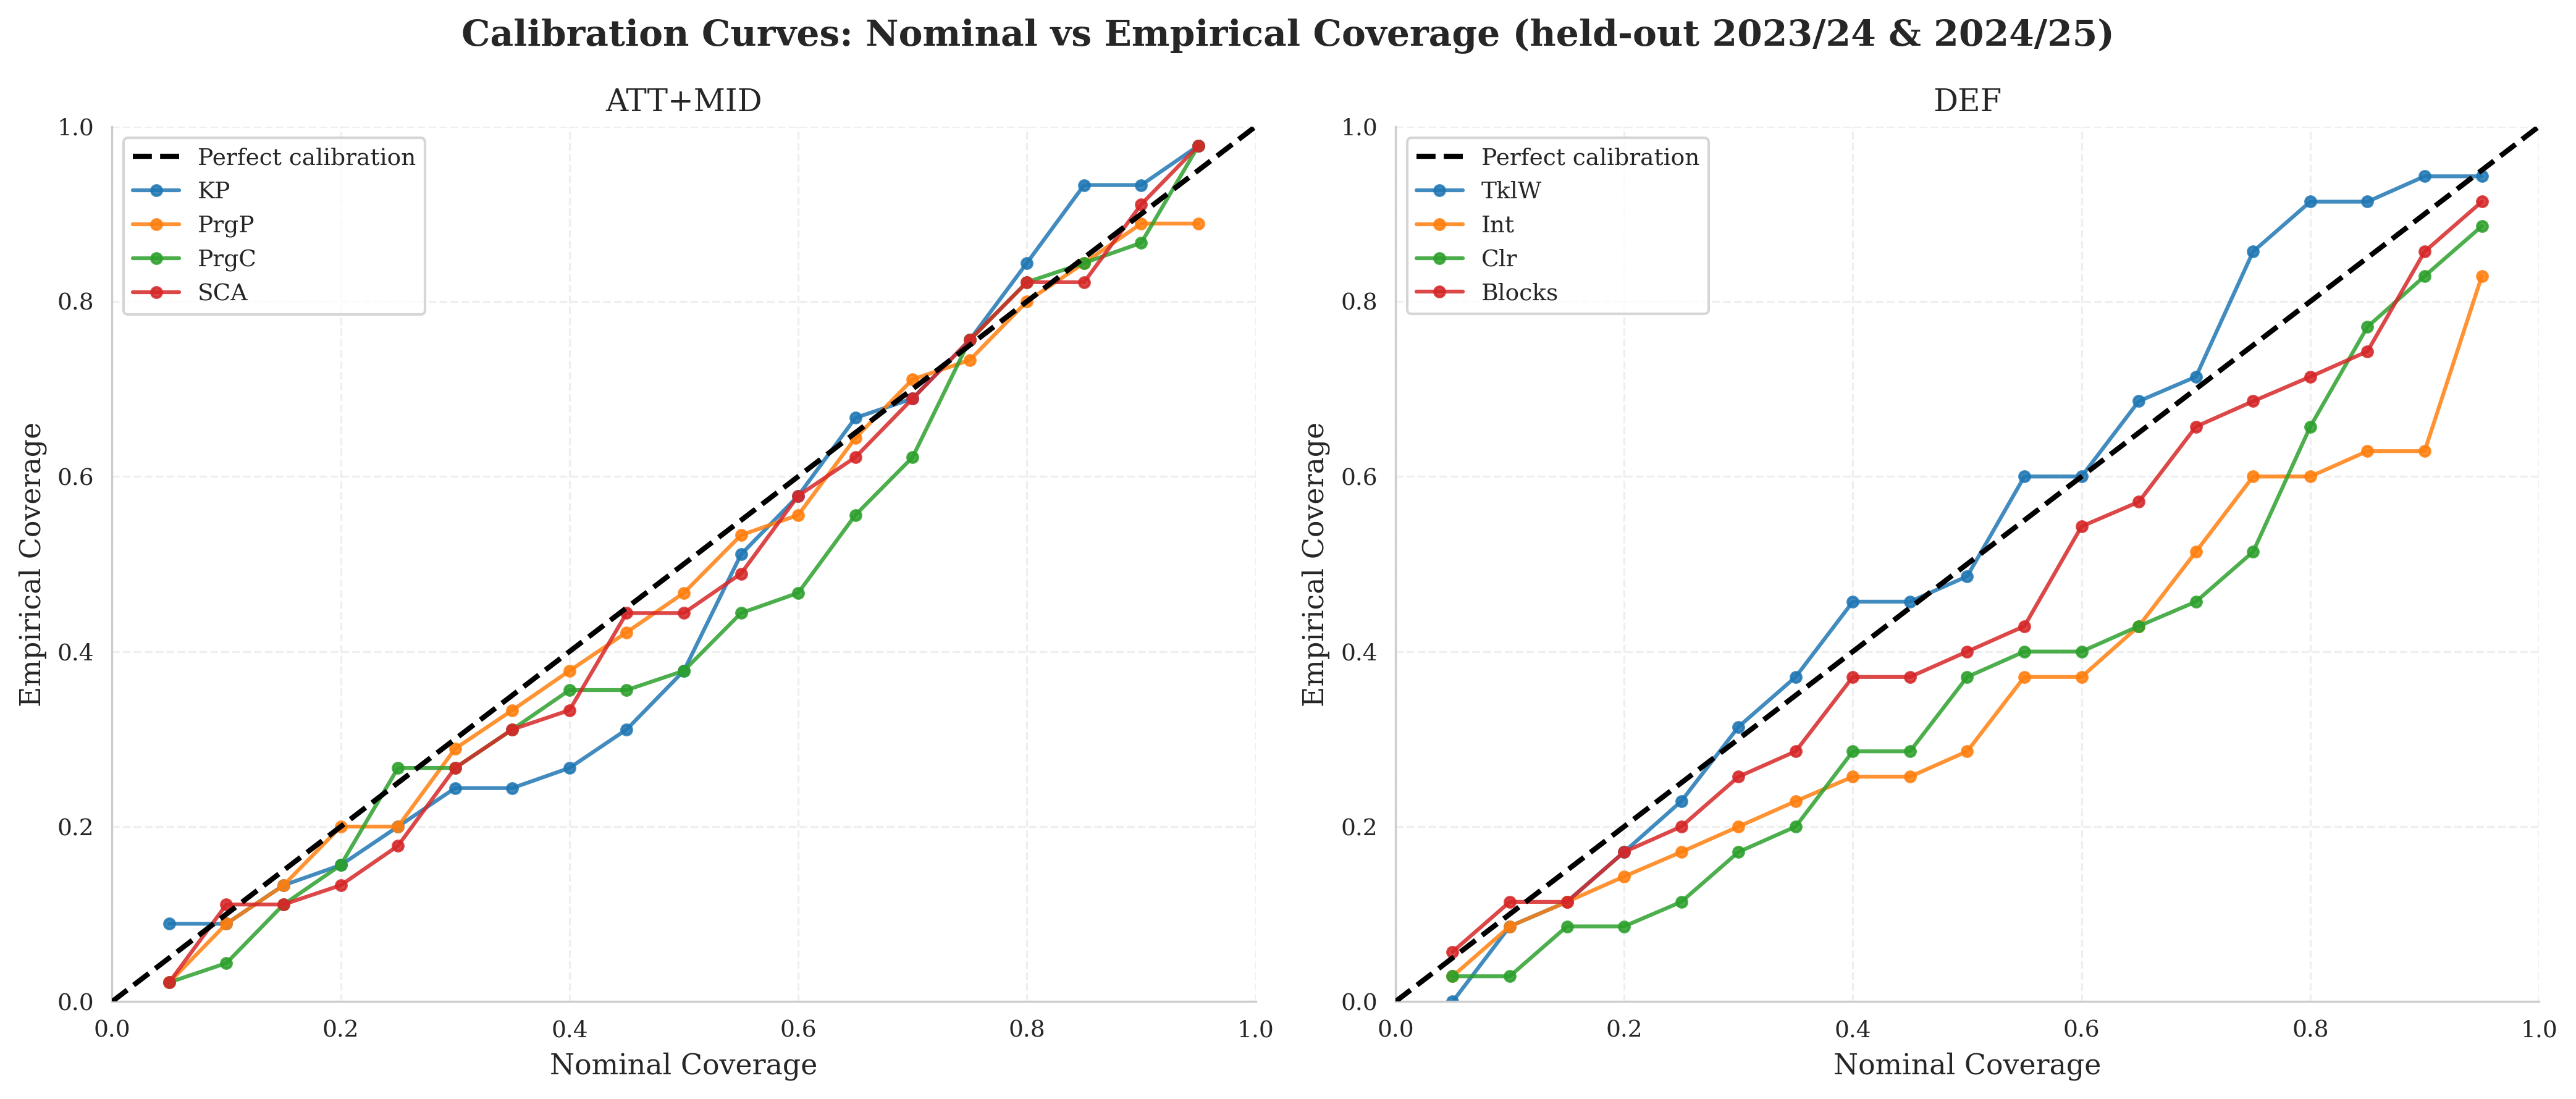

In [ ]:
# ============================================================================
# CELL 19: CALIBRATION CURVES (held-out 2023/2024 & 2024/25 test set)
# ============================================================================

print("\n" + "=" * 80)
print("CALIBRATION CURVES (OOS)")
print("=" * 80 + "\n")


def _unpack_chol(chol_packed, n_stats_loc):
    """Reconstruct lower-triangular Cholesky matrices from PyMC's packed form."""
    n_samples = chol_packed.shape[0]
    chol_full = np.zeros((n_samples, n_stats_loc, n_stats_loc))
    idx = np.tril_indices(n_stats_loc)
    for s in range(n_samples):
        chol_full[s][idx] = chol_packed[s]
    return chol_full


def compute_calibration_oos(df_test, Y_test_std, stats_list, standardization,
                             joint_trace, age_mean, label, n_nominal=19):
    """Full posterior predictive calibration across a grid of nominal coverage levels."""
    n_obs       = len(df_test)
    n_stats_loc = len(stats_list)

    alpha_samp = joint_trace.posterior['alpha'].values.reshape(-1, n_stats_loc)
    n_samples  = alpha_samp.shape[0]
    lt_samp    = joint_trace.posterior['league_tax'].values.reshape(-1, 4, n_stats_loc)
    ba_samp    = joint_trace.posterior['beta_age'].values.reshape(-1, n_stats_loc)
    ba2_samp   = joint_trace.posterior['beta_age2'].values.reshape(-1, n_stats_loc)

    chol_raw  = joint_trace.posterior['chol'].values
    n_packed  = n_stats_loc * (n_stats_loc + 1) // 2
    chol_flat = chol_raw.reshape(-1, n_packed)
    assert chol_flat.shape[1] == n_packed, (
        f"Chol packed size mismatch: got {chol_flat.shape[1]}, "
        f"expected {n_packed} for n_stats={n_stats_loc}."
    )
    chol_samp = _unpack_chol(chol_flat, n_stats_loc)

    rng = np.random.default_rng(42)
    nu  = 6

    all_preds = np.zeros((n_obs, n_samples, n_stats_loc))
    for i in range(n_obs):
        age_c   = (df_test.iloc[i]['Age'] - age_mean) / 5.0
        is_for  = int(df_test.iloc[i]['is_foreign'])
        l_idx   = int(np.clip(df_test.iloc[i]['League_ID'], 0, 3))
        age_eff = ba_samp * age_c + ba2_samp * (age_c ** 2)
        tax     = lt_samp[:, l_idx, :] if is_for else np.zeros((n_samples, n_stats_loc))
        mu_samp = alpha_samp + tax + age_eff
        chi2_i  = rng.chisquare(nu, size=n_samples) / nu
        z_i     = rng.standard_normal(size=(n_samples, n_stats_loc))
        t_i     = z_i / np.sqrt(chi2_i[:, None])
        noise_i = np.einsum('sij,sj->si', chol_samp, t_i)
        all_preds[i] = mu_samp + noise_i

    nominal_levels = np.linspace(0.05, 0.95, n_nominal)
    results = []
    for j, stat in enumerate(stats_list):
        mean_s = standardization[stat]['mean']
        std_s  = standardization[stat]['std']
        y_true = Y_test_std[:, j] * std_s + mean_s
        for nom in nominal_levels:
            lo_p = (1 - nom) / 2 * 100
            hi_p = (1 + nom) / 2 * 100
            preds_orig = all_preds[:, :, j] * std_s + mean_s
            lo  = np.percentile(preds_orig, lo_p, axis=1)
            hi  = np.percentile(preds_orig, hi_p, axis=1)
            emp = float(np.mean((y_true >= lo) & (y_true <= hi)))
            results.append({
                'Stat':      stat,
                'Nominal':   round(float(nom), 2),
                'Empirical': round(emp, 3),
                'Delta':     round(emp - float(nom), 3),
            })

    df_cal = pd.DataFrame(results)
    print(f"{label} — Calibration at 90% nominal:")
    print(df_cal[df_cal['Nominal'] == 0.9][['Stat', 'Nominal', 'Empirical', 'Delta']].to_string(index=False))
    return df_cal


cal_att_oos = None
cal_def_oos = None

if not df_test_att.empty:
    cal_att_oos = compute_calibration_oos(
        df_test_att, Y_test_att,
        COMMON_STATS_ATT_MID, standardization_att_mid,
        joint_trace_att_mid, age_mean_att_mid,
        label='ATT+MID',
    )

if not df_test_def.empty:
    cal_def_oos = compute_calibration_oos(
        df_test_def, Y_test_def,
        COMMON_STATS_DEF, standardization_def,
        joint_trace_def, age_mean_def,
        label='DEF',
    )

if cal_att_oos is not None and cal_def_oos is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        'Calibration Curves: Nominal vs Empirical Coverage (held-out 2023/24 & 2024/25)',
        fontsize=14, fontweight='bold'
    )
    for ax, cal_df, stats_list_plot, title in [
        (axes[0], cal_att_oos, COMMON_STATS_ATT_MID, 'ATT+MID'),
        (axes[1], cal_def_oos, COMMON_STATS_DEF,      'DEF'),
    ]:
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect calibration', zorder=5)
        for stat in stats_list_plot:
            sub = cal_df[cal_df['Stat'] == stat]
            ax.plot(
                sub['Nominal'].values, sub['Empirical'].values,
                marker='o', markersize=4, label=stat, alpha=0.85, linewidth=1.5,
            )
        ax.set_xlabel('Nominal Coverage', fontsize=11)
        ax.set_ylabel('Empirical Coverage', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

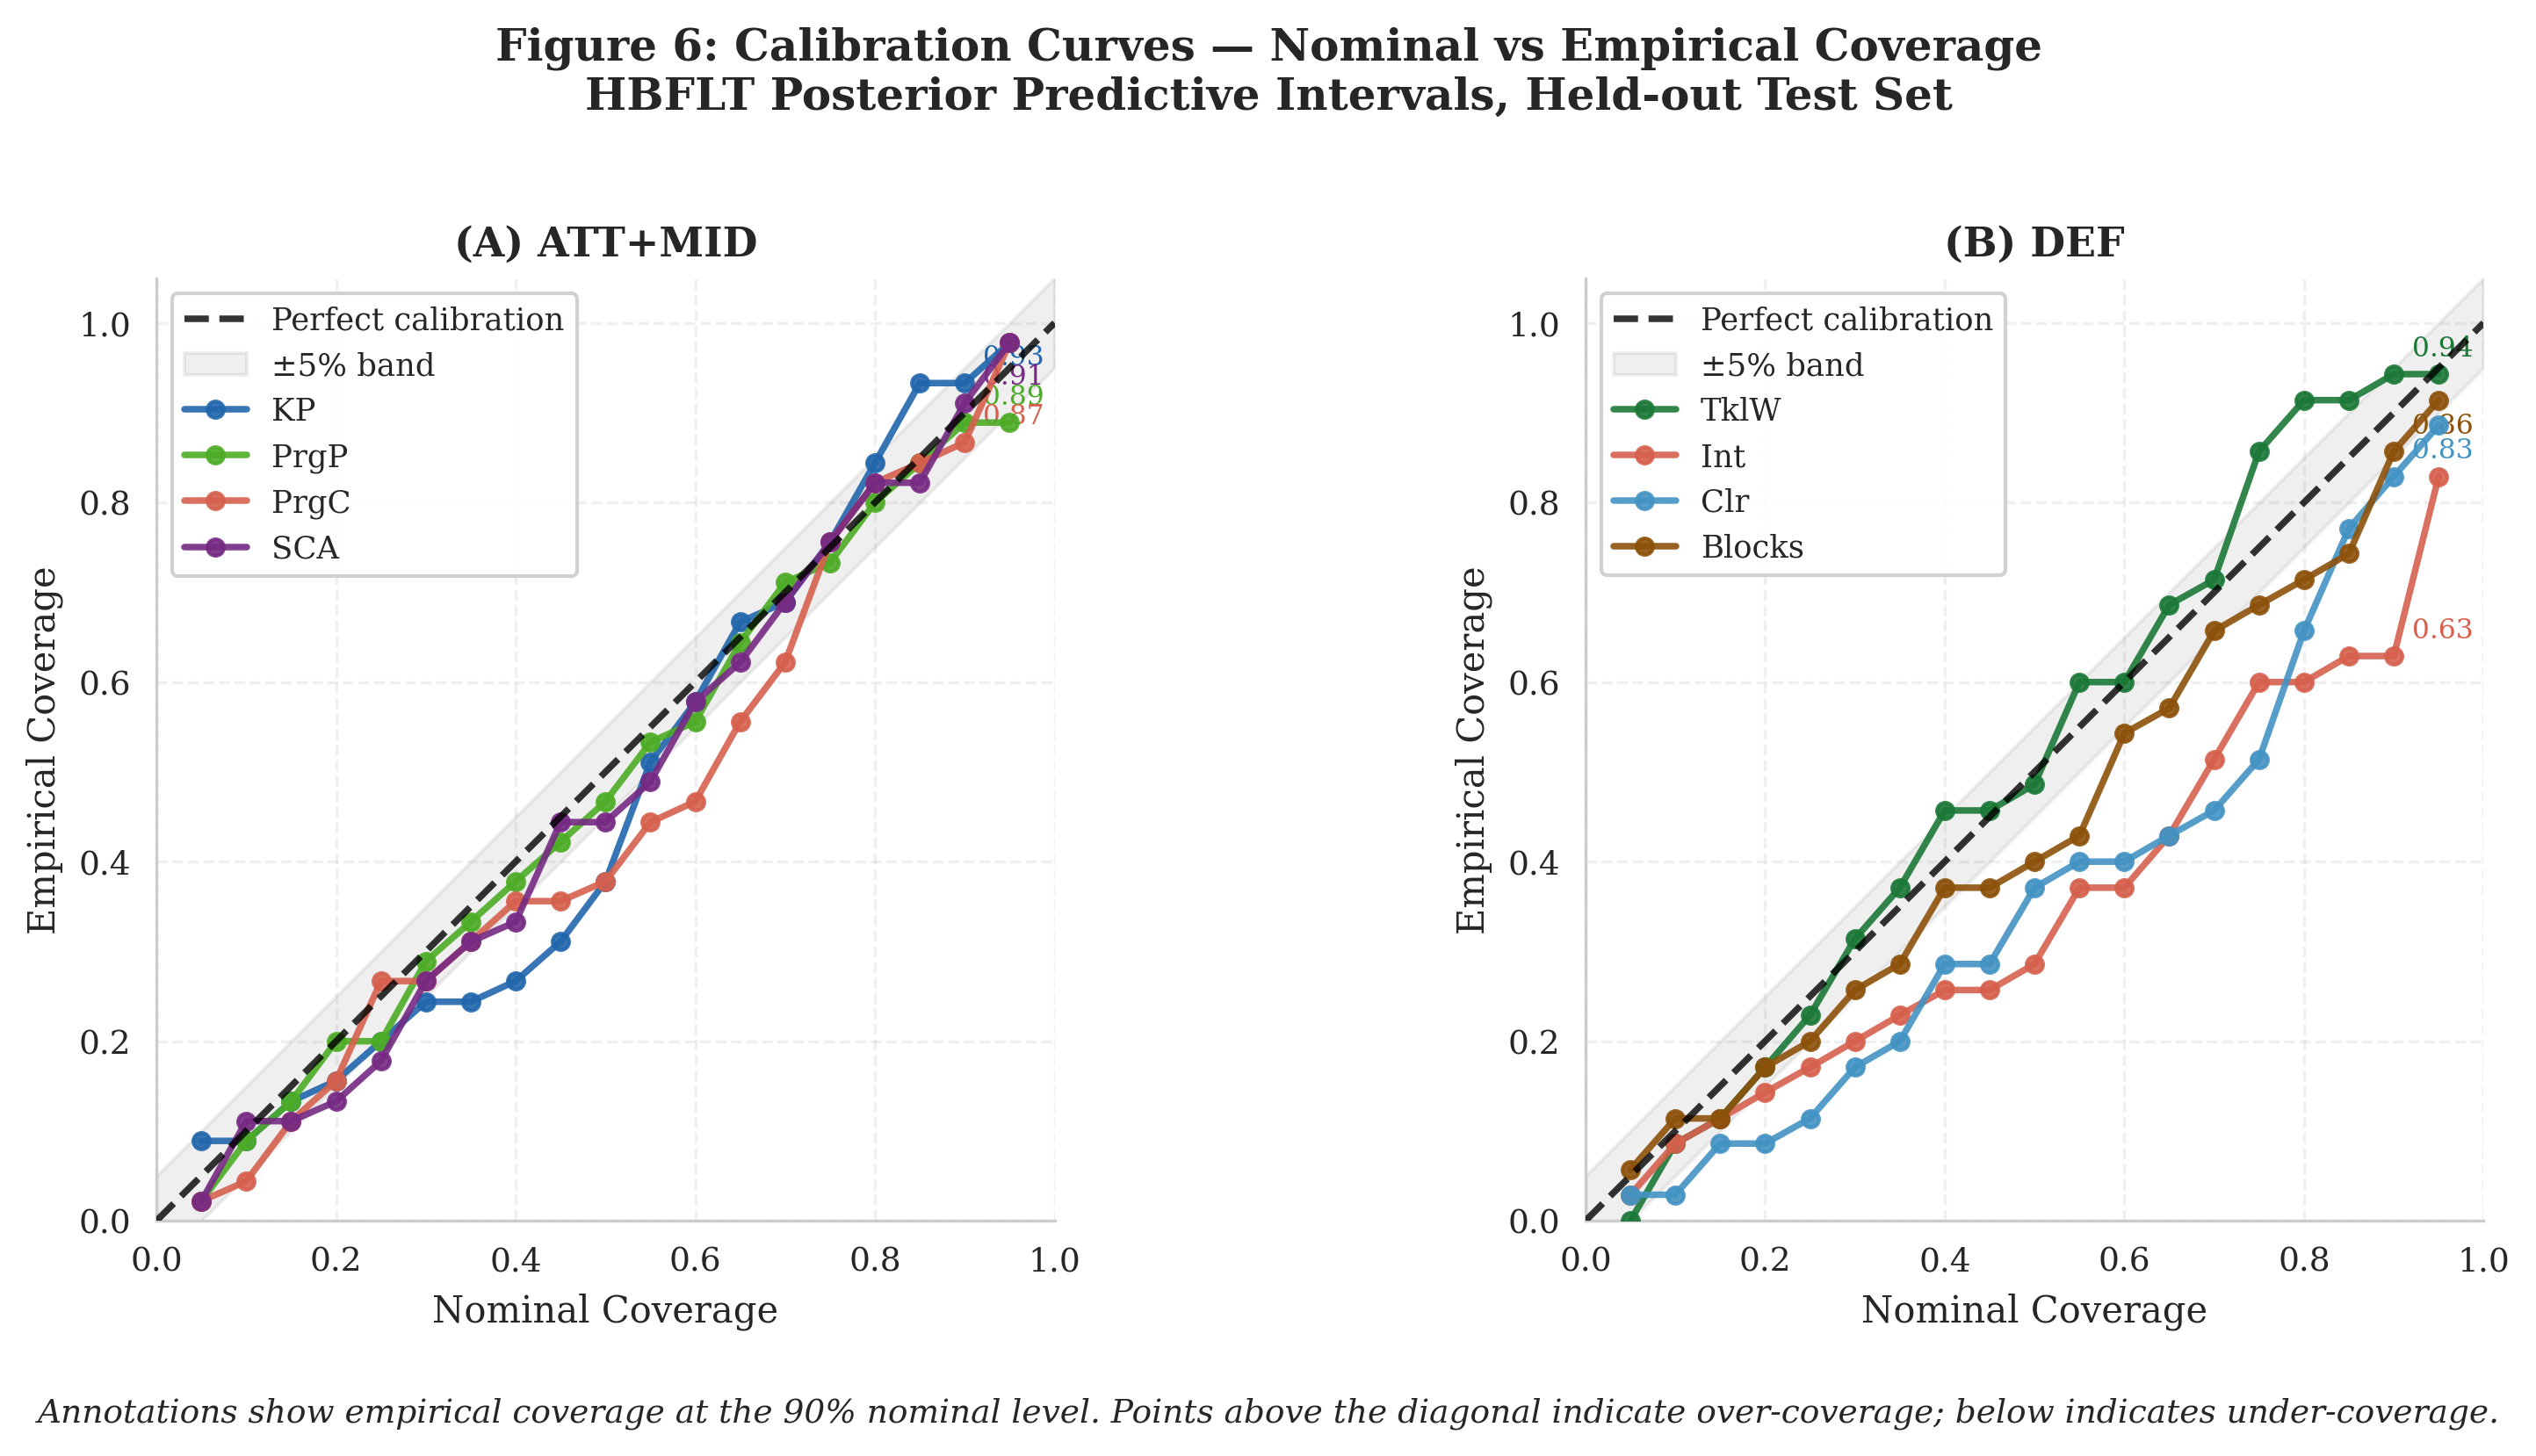

✓ Figure 6 saved


In [ ]:
# ============================================================================
# CELL 19b: FIGURE 6 — CALIBRATION CURVES (PUBLICATION)
# ============================================================================

plt.rcParams.update(PUB_STYLE)

STAT_COLORS_ATT = {
    'KP':   '#2166AC',
    'PrgP': '#4DAC26',
    'PrgC': '#D6604D',
    'SCA':  '#762A83',
}
STAT_COLORS_DEF = {
    'TklW':   '#1B7837',
    'Int':    '#D6604D',
    'Clr':    '#4393C3',
    'Blocks': '#8C510A',
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle(
    'Figure 6: Calibration Curves — Nominal vs Empirical Coverage\n'
    'HBFLT Posterior Predictive Intervals, Held-out Test Set',
    fontsize=12, fontweight='bold', y=1.02
)

for ax, cal_df, stats_list, stat_colors, panel_label, bridge_label in [
    (axes[0], cal_att_oos, COMMON_STATS_ATT_MID, STAT_COLORS_ATT, 'A', 'ATT+MID'),
    (axes[1], cal_def_oos, COMMON_STATS_DEF,      STAT_COLORS_DEF, 'B', 'DEF'),
]:
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.8,
            label='Perfect calibration', zorder=10, alpha=0.8)

    # ±5% band
    x_band = np.linspace(0, 1, 100)
    ax.fill_between(x_band, x_band - 0.05, x_band + 0.05,
                    color='grey', alpha=0.12, label='±5% band')

    for stat in stats_list:
        sub  = cal_df[cal_df['Stat'] == stat]
        nom  = sub['Nominal'].values
        emp  = sub['Empirical'].values
        col  = stat_colors[stat]
        ax.plot(nom, emp, marker='o', markersize=4.5,
                linewidth=1.8, color=col, label=stat,
                alpha=0.9, zorder=5)
        # Annotate 90% nominal point
        idx_90 = np.argmin(np.abs(nom - 0.90))
        ax.annotate(
            f'{emp[idx_90]:.2f}',
            xy=(nom[idx_90], emp[idx_90]),
            xytext=(5, 5), textcoords='offset points',
            fontsize=7.5, color=col,
        )

    ax.set_xlabel('Nominal Coverage', fontsize=10)
    ax.set_ylabel('Empirical Coverage', fontsize=10)
    ax.set_title(f'({panel_label}) {bridge_label}', fontsize=11, fontweight='bold')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize=8.5, loc='upper left', framealpha=0.9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(
    0.5, -0.04,
    'Annotations show empirical coverage at the 90% nominal level. '
    'Points above the diagonal indicate over-coverage; below indicates under-coverage.',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('figure6_calibration.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure6_calibration.png', bbox_inches='tight', dpi=300)
plt.show()
print("✓ Figure 6 saved")

In [ ]:
# ============================================================================
# CELL 20: POSTERIOR CREDIBLE INTERVAL TABLE — LEAGUE EFFECTS
# ============================================================================

print("\n" + "=" * 80)
print("POSTERIOR CREDIBLE INTERVAL TABLE — LEAGUE EFFECTS")
print("=" * 80 + "\n")


def build_posterior_sd_table(joint_trace, stats_list, label):
    lt = joint_trace.posterior['league_tax'].values
    n_chains, n_draws, n_leagues, n_stats_loc = lt.shape
    flat = lt.reshape(n_chains * n_draws, n_leagues, n_stats_loc)

    leagues = ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']
    rows = []
    for l_idx, league in enumerate(leagues):
        for s_idx, stat in enumerate(stats_list):
            samp     = flat[:, l_idx, s_idx]
            hdi_vals = az.hdi(samp, hdi_prob=0.90)
            rows.append({
                'League':     league,
                'Stat':       stat,
                'Post. Mean': round(float(np.mean(samp)), 4),
                'Post. SD':   round(float(np.std(samp, ddof=1)), 4),
                'CI 5%':      round(float(hdi_vals[0]), 4),
                'CI 95%':     round(float(hdi_vals[1]), 4),
            })

    df_sd = pd.DataFrame(rows)
    print(f"{label} — Posterior League Tax Summary (90% HDI):\n")
    print(df_sd.to_string(index=False))
    return df_sd


sd_table_att = build_posterior_sd_table(
    joint_trace_att_mid, COMMON_STATS_ATT_MID, 'ATT+MID'
)
print()
sd_table_def = build_posterior_sd_table(
    joint_trace_def, COMMON_STATS_DEF, 'DEF'
)


POSTERIOR CREDIBLE INTERVAL TABLE — LEAGUE EFFECTS

ATT+MID — Posterior League Tax Summary (90% HDI):

    League Stat  Post. Mean  Post. SD   CI 5%  CI 95%
   Ligue 1   KP     -0.0244    0.1354 -0.2425  0.1899
   Ligue 1 PrgP     -0.2648    0.1581 -0.5095  0.0013
   Ligue 1 PrgC     -0.1325    0.1373 -0.3678  0.0883
   Ligue 1  SCA     -0.0997    0.1385 -0.3285  0.1237
Bundesliga   KP     -0.1767    0.1685 -0.4551  0.0886
Bundesliga PrgP     -0.2059    0.1604 -0.4576  0.0625
Bundesliga PrgC     -0.0251    0.1427 -0.2495  0.2113
Bundesliga  SCA     -0.2283    0.1622 -0.4925  0.0414
   Serie A   KP     -0.2018    0.1817 -0.4940  0.0830
   Serie A PrgP     -0.2301    0.1751 -0.5204  0.0542
   Serie A PrgC     -0.0789    0.1492 -0.3356  0.1514
   Serie A  SCA     -0.1825    0.1766 -0.4620  0.1129
   La Liga   KP      0.1409    0.1684 -0.1287  0.4121
   La Liga PrgP     -0.0041    0.1728 -0.2769  0.2803
   La Liga PrgC     -0.0755    0.1370 -0.2924  0.1499
   La Liga  SCA      0.3287    0

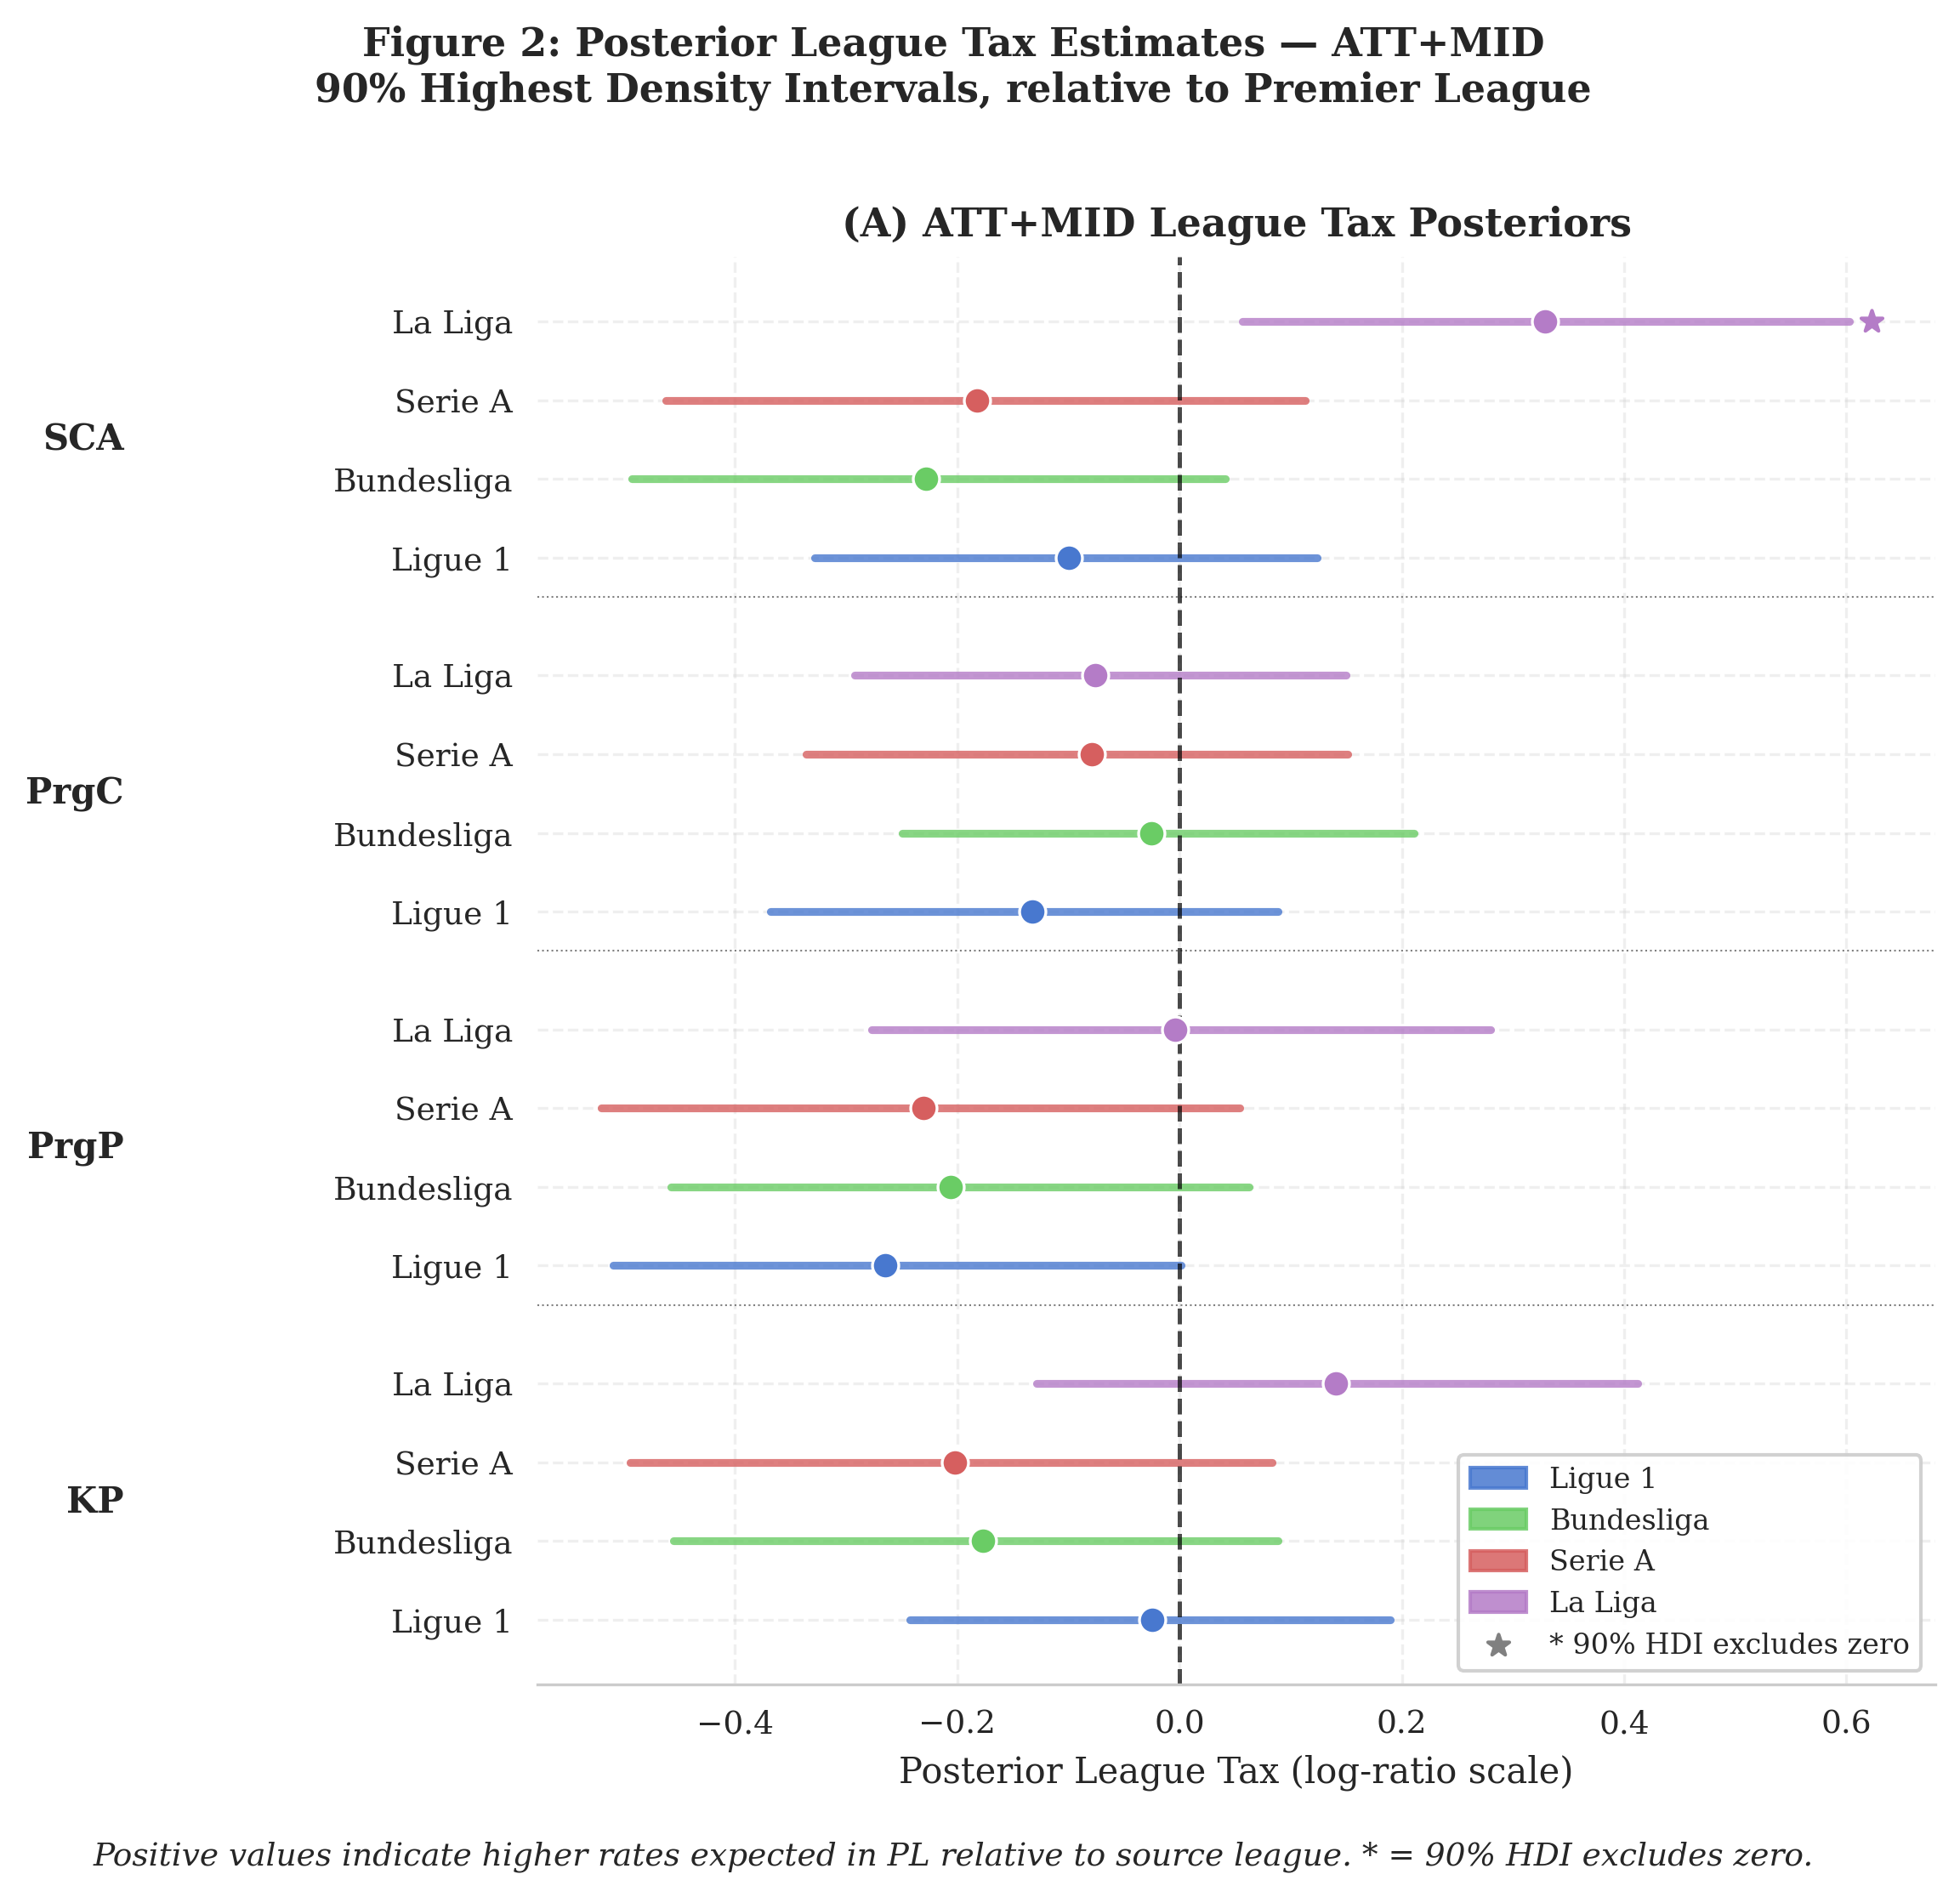

✓ Figure 2 saved


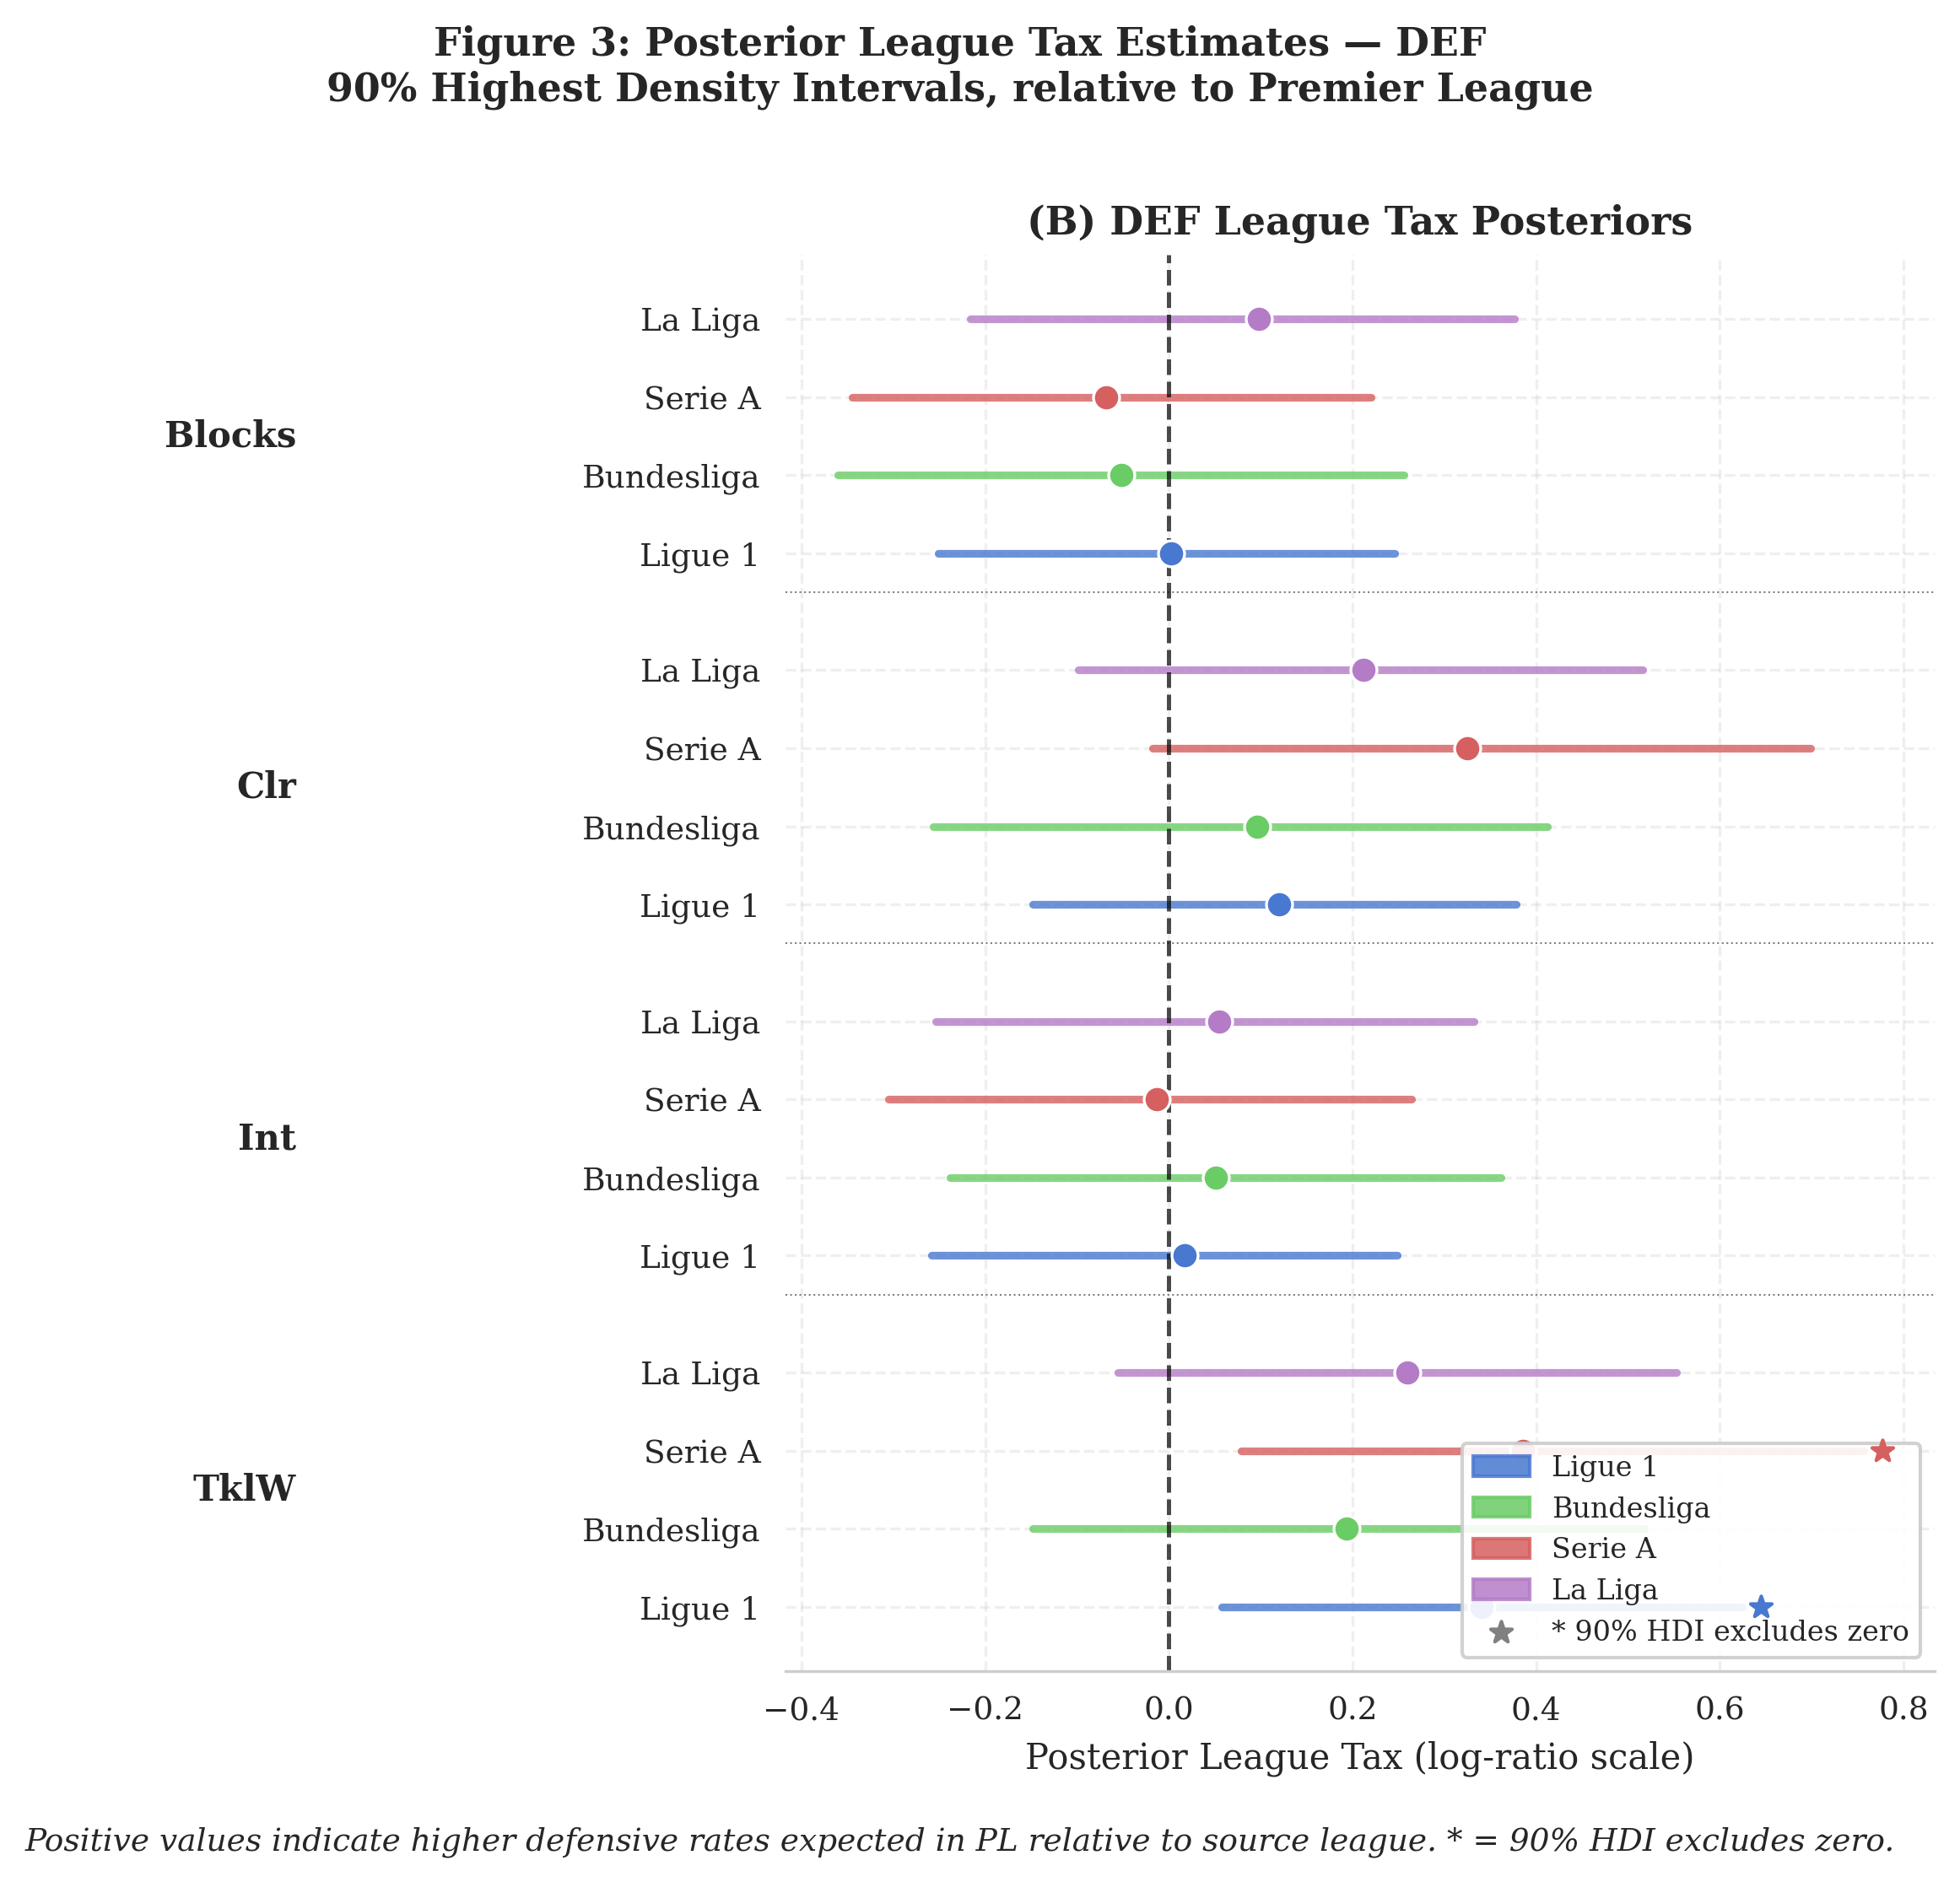

✓ Figure 3 saved


In [ ]:
# ============================================================================
# CELL 20b: FIGURES 2 & 3 — POSTERIOR LEAGUE TAX FOREST PLOTS (PUBLICATION)
# ============================================================================
# Reads from sd_table_att and sd_table_def computed in Cell 20.

plt.rcParams.update(PUB_STYLE)

LEAGUE_COLORS_FOREST = {
    'Ligue 1':    '#4878CF',
    'Bundesliga': '#6ACC65',
    'Serie A':    '#D65F5F',
    'La Liga':    '#B47CC7',
}
LEAGUES = ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']

def plot_forest(ax, sd_table, stats_list, title, panel_label):
    n_stats   = len(stats_list)
    n_leagues = len(LEAGUES)
    spacing   = 1.0
    group_gap = 0.5

    yticks, ylabels = [], []

    for s_idx, stat in enumerate(stats_list):
        base_y = s_idx * (n_leagues * spacing + group_gap)
        for l_idx, league in enumerate(LEAGUES):
            row = sd_table[
                (sd_table['Stat'] == stat) & (sd_table['League'] == league)
            ]
            if row.empty:
                continue
            mean_val = row['Post. Mean'].values[0]
            lo_val   = row['CI 5%'].values[0]
            hi_val   = row['CI 95%'].values[0]
            y        = base_y + l_idx * spacing
            color    = LEAGUE_COLORS_FOREST[league]
            excludes_zero = (lo_val > 0) or (hi_val < 0)

            # HDI line
            ax.plot([lo_val, hi_val], [y, y], color=color,
                    linewidth=2.2, alpha=0.8, solid_capstyle='round')
            # Mean dot
            ax.scatter(mean_val, y, color=color, s=55, zorder=5,
                       edgecolors='white', linewidths=0.8)
            # Star for credibly non-zero
            if excludes_zero:
                ax.scatter(hi_val + 0.02, y, marker='*', color=color,
                           s=40, zorder=6)

            yticks.append(y)
            ylabels.append(league)

        # Stat label in left margin
        mid_y = base_y + (n_leagues - 1) * spacing / 2
        ax.text(-0.95, mid_y, stat, ha='right', va='center',
                fontsize=10, fontweight='bold')

        # Separator line between stat groups
        if s_idx < n_stats - 1:
            sep_y = base_y + n_leagues * spacing
            ax.axhline(sep_y, color='grey', linewidth=0.5, linestyle=':')

    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel('Posterior League Tax (log-ratio scale)', fontsize=10)
    ax.set_title(f'({panel_label}) {title}', fontsize=11, fontweight='bold')
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)

    # Legend
    handles = [
        mpatches.Patch(color=LEAGUE_COLORS_FOREST[l], label=l, alpha=0.85)
        for l in LEAGUES
    ]
    handles.append(
        plt.scatter([], [], marker='*', color='grey', s=40, label='* 90% HDI excludes zero')
    )
    ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.9)


# Figure 2: ATT+MID Forest Plot
fig, ax = plt.subplots(figsize=(8, 7))
plot_forest(ax, sd_table_att, COMMON_STATS_ATT_MID,
            'ATT+MID League Tax Posteriors', 'A')
fig.suptitle(
    'Figure 2: Posterior League Tax Estimates — ATT+MID\n'
    '90% Highest Density Intervals, relative to Premier League',
    fontsize=11, fontweight='bold', y=1.01
)
fig.text(
    0.5, -0.02,
    'Positive values indicate higher rates expected in PL relative to source league. '
    '* = 90% HDI excludes zero.',
    ha='center', fontsize=9, style='italic'
)
plt.tight_layout()
plt.savefig('figure2_forest_att_mid.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure2_forest_att_mid.png', bbox_inches='tight', dpi=300)
plt.show()
print("✓ Figure 2 saved")


# Figure 3: DEF Forest Plot
fig, ax = plt.subplots(figsize=(8, 7))
plot_forest(ax, sd_table_def, COMMON_STATS_DEF,
            'DEF League Tax Posteriors', 'B')
fig.suptitle(
    'Figure 3: Posterior League Tax Estimates — DEF\n'
    '90% Highest Density Intervals, relative to Premier League',
    fontsize=11, fontweight='bold', y=1.01
)
fig.text(
    0.5, -0.02,
    'Positive values indicate higher defensive rates expected in PL relative to source league. '
    '* = 90% HDI excludes zero.',
    ha='center', fontsize=9, style='italic'
)
plt.tight_layout()
plt.savefig('figure3_forest_def.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure3_forest_def.png', bbox_inches='tight', dpi=300)
plt.show()
print("✓ Figure 3 saved")